# Plotting The CSVs created by the other Notebooks
most of these were initially plotted in `./demo_num_investigations.ipynb` however, it made it look messy and was hard to find what I needed, this is a more structured and I think overall better system to plot things

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import numpy as np
import pandas as pd

import seaborn as sns
import torch

import re
from itertools import product

## Helpers


In [19]:
def parse_list(ss: str):
  s = ss.strip("[]")
  # print(s)
  s = re.sub(r"\s+", " ", s)
  return np.fromstring(s, sep=" ")

def parse_list_bools(ss: str):
  s = ss.strip("[]")
  s = re.sub(r"\s+", " ", s)
  bools = s.split(" ")
  return np.array([b == 'True' for b in bools], dtype=bool)


## does not preserve the dimensionality of the tensor
def parse_1d_tensor(ss: str):
  s = re.sub(r"^tensor", "", ss)
  s = s.strip("()[]")
  return torch.tensor(np.fromstring(s, sep=", "), dtype=torch.float32)

def vision_sns_catplot(
    data_df: pd.DataFrame, 
    figsize: tuple[int, int],
    x_name: str,
    y_name: str, 
    col_name: str, 
    row_name: str, 
    title: str,
    y_name_side: str | None = None, 
    plot_kwargs = {},
    plot_side_kwargs = {}
  ) -> sns.FacetGrid:

  plt.figure(figsize=figsize)
  g = sns.catplot(
      data=data_df,
      x=x_name,
      y=y_name,
      col=col_name,
      row=row_name,
      **plot_kwargs
      # kind="box",
      # width = 0.4,
      # height=5, 
      # aspect=1.2
  )

  num_cols = len(g.col_names)

  if y_name_side is not None:

    for row_idx, row_data in enumerate(g.row_names):
      for col_idx, col_data in enumerate(g.col_names):
        ax = g.axes[row_idx, col_idx]

        # Filter data for current facet
        subset = data_df[(data_df[col_name] == col_data) & (data_df[row_name] == row_data)]

        # Create secondary y-axis
        ax2 = ax.twinx()

        # Overlay success values as red dots (jittered)
        sns.stripplot(
            data=subset,
            x=x_name,
            y=y_name_side,
            ax=ax2,
            **plot_side_kwargs
            # color="red",
            # alpha=0.4,
            # jitter=True,
            # dodge=True,
            # size=4
        )

        ax2.set_ylim(0, 1.05)
        ## only show on the rightmost columns
        if col_idx == num_cols - 1:
          ax2.set_ylabel("Success", color="red")
          ax2.tick_params(axis='y', labelcolor='red')
        else:
          ax2.set_yticklabels([])
          ax2.set_ylabel("")
          ax2.tick_params(axis="y", left = False, labelleft = False)


        # Rotate x-ticks
        ax.tick_params(axis='x', labelrotation=45)
        # ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


  g.figure.subplots_adjust(top=0.9)
  g.figure.suptitle(title, size = 20)
  return g





### Cam Attention Helpers

In [20]:
def plot_cam_attention(df, task_name):
  fig, axs = plt.subplots(1, 2, figsize=(12, 6))

  pools = df["pool_method"].unique()

  for pi, pool in enumerate(pools):
    pool_df = df[df["pool_method"] == pool]

    sns.lineplot(ax=axs[pi], data=pool_df, x="demo_count", y="avg_final_dist", hue="cam_type", marker="o")
    axs[pi].set_title(f"'{task_name}' - Pooling method: '{pool}'")
    axs[pi].set_xlabel("Number of Demos")
    axs[pi].set_ylabel("Final Average Distance")
    axs[pi].legend(title="Cam Type")
    
  fig.text(0.2, -0.1, "See `plots.ipynb > Cam Attention checks with differnet cameras - 1st Time` for the parameters used")
  plt.show()

def plot_cam_attention_heatmap(df, fix_tensors = True):
  if fix_tensors:
    df["avg_avg_attn_above"] = df["avg_avg_attn_above"].apply(parse_1d_tensor)
    df["avg_avg_attn_below"] = df["avg_avg_attn_below"].apply(parse_1d_tensor)
  
  cam_combos = df["cam_type"].unique()
  pools = df["pool_method"].unique()
  demo_counts = df["demo_count"].unique()

  num_cams = len(cam_combos)
  num_pools = len(pools)

  for di, demo_count in enumerate(demo_counts):
    ## make a new plot for each demo count, easier to digest
    fig, axs = plt.subplots(num_cams, num_pools, figsize=(16, 10))
    for ci, cam_type in enumerate(cam_combos):
      for pi, pool in enumerate(pools):
        ax = axs[ci, pi]
        
        pool_df = df[
          (df["pool_method"] == pool) &
          (df["cam_type"] == cam_type) &
          (df["demo_count"] == demo_count)
        ]
        
        x_labels = cam_type.split("+")
        
        if pool_df.empty:
          continue
        tensor_above = pool_df["avg_avg_attn_above"].values[0]
        tensor_below = pool_df["avg_avg_attn_below"].values[0]
        
        y_labels = ["Above", "Below"]
        stack = torch.stack([tensor_above, tensor_below], dim=0)
        sns.heatmap(ax=ax, data=stack.reshape(2, -1), cbar=True, cmap="YlGnBu", annot=True)
        
        ax.set_xticklabels(x_labels)
        ax.set_yticklabels(y_labels)
        ax.set_title(f"{cam_type} - {pool} - {demo_count} Demo{"s" if demo_count != 1 else ""}")
    fig.suptitle(f"Attention Maps for {demo_count} Demo{"s" if demo_count != 1 else ""}, Above and Below the Obstacle", fontsize=16)
    plt.tight_layout()
    plt.show()
  

SyntaxError: f-string: expecting '}' (4116977324.py, line 56)

### Depth Interfacing Helpers


In [ ]:
def df_agent_select(agent: str) -> str:
  match agent:
    case "agent-policy:depth_grasp_policy-cams:wrist-policy:depth_grasp_policy-config:depth_ch-opts:{'gated_fuse': None}":
      return "Wrist RGB (depth_ch)"
    case "agent-policy:depth_grasp_policy-cams:wrist+wrist_depth-policy:depth_grasp_policy-config:depth_ch-opts:{'gated_fuse': None}":
      return "Wrist RGB + Depth (depth_ch)"
    case "agent-policy:depth_grasp_policy-cams:wrist+wrist_depth-policy:depth_grasp_policy-config:depth_feats-opts:{'gated_fuse': None}":
      return "Wrist RGB + Depth (depth_feats - no gate)"
    case "agent-policy:depth_grasp_policy-cams:wrist+wrist_depth-policy:depth_grasp_policy-config:depth_feats-opts:{'gated_fuse': True}":
      return "Wrist RGB + Depth (depth_feats - gated)"
    case "agent-policy:depth_grasp_policy-cams:l_shoulder+r_shoulder-policy:depth_grasp_policy-config:depth_ch-opts:{'gated_fuse': None}":
      return "L+R Shoulder RGB"
    case _:
      raise ValueError(f"Add other here: 'Depth Interefacing Helpers")


# No Obstacle


## Different Camera Combinations, Single Cams



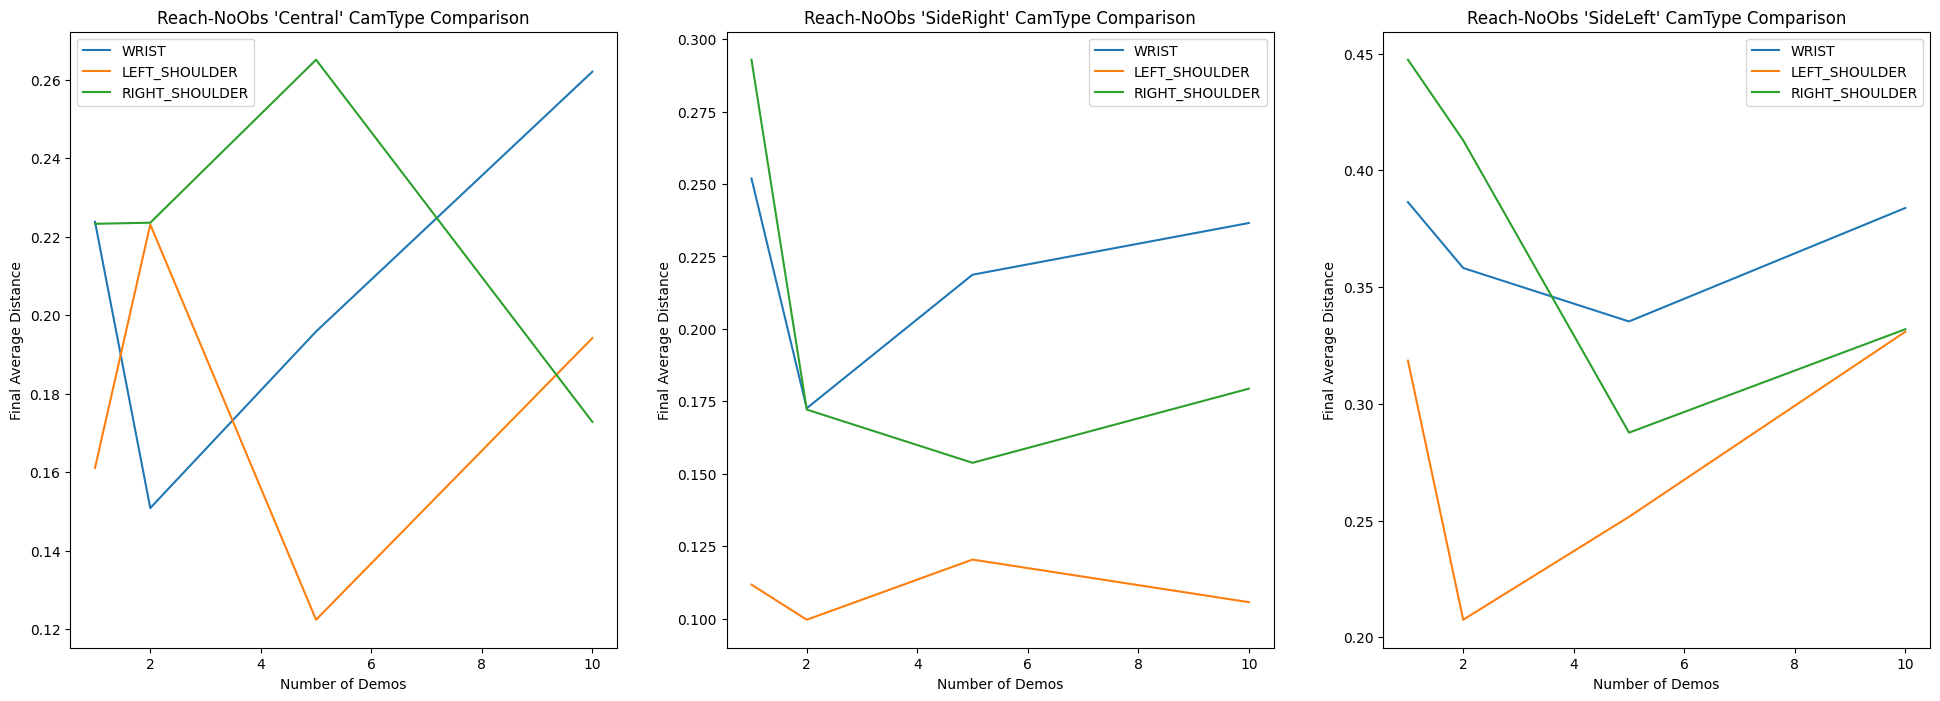

In [ ]:
df = pd.read_csv("run-csvs/reach-no-obs/diff_cams-results.csv")

tasks = df["task"].unique()
fig, ax = plt.subplots(1, len(tasks), figsize=(24, 8))

for ti, task in enumerate(tasks):
  task_df = df[df["task"] == task]
  
  for cam_type in task_df["cam_type"].unique():
    row_df = task_df[task_df["cam_type"] == cam_type]
    ax[ti].plot(row_df["demo_count"], row_df["final_dist"], label=cam_type)
    
  ax[ti].set_title(f"Reach-NoObs '{task}' CamType Comparison")
  ax[ti].set_xlabel("Number of Demos")
  ax[ti].set_ylabel("Final Average Distance")
  ax[ti].legend()



## Random Place - Different Cam Results

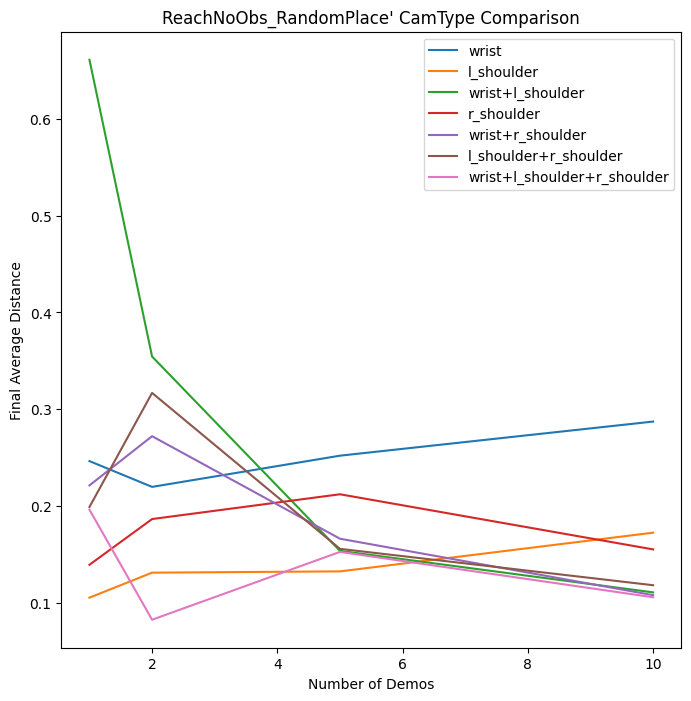

In [74]:
df = pd.read_csv("run-csvs/reach-no-obs/random_place-multicam-results.csv")
df["cam_type"] = df["cam_type"].apply(lambda x: re.sub(r"^\+", "", x))
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

sns.lineplot(data=df, x="demo_count", y="final_dist", hue="cam_type", ax=ax)
  
ax.set_title(f"ReachNoObs_RandomPlace' CamType Comparison")
ax.set_xlabel("Number of Demos")
ax.set_ylabel("Final Average Distance")
ax.legend()



## `Reach_PlaceRandom` Epoch Trials
trying 1000 and 500 epochs to see which one is better at Beheaviourally Cloning this task


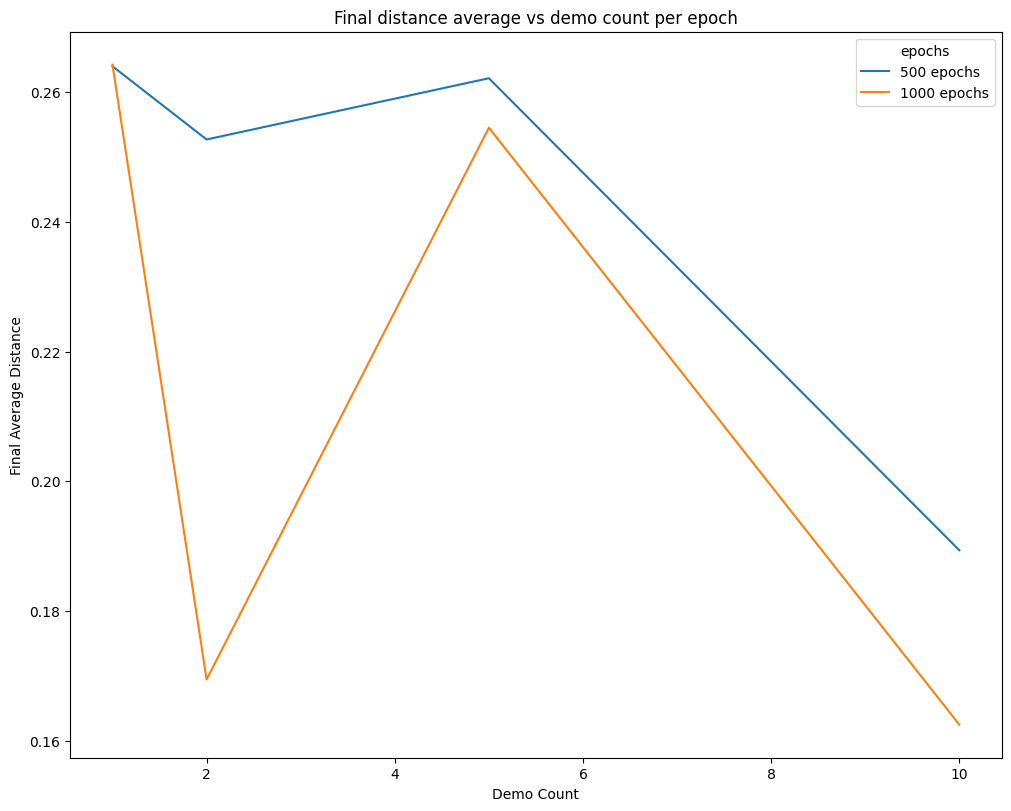

In [31]:
figsize = 10, 8
fix, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout = True)

## load the data df

df500 = pd.read_csv(f"run-csvs/reach-no-obs/1-2-5-10-10repeats-diff-initial-poses-no_obs-500epochs.csv")
df500["epoch"] = 500
df1000 = pd.read_csv(f"run-csvs/reach-no-obs/1-2-5-10-10repeats-diff-initial-poses-no_obs-1000epochs.csv")
df1000["epoch"] = 1000


ax.plot(df500["demo_count"], df500["final_dist_avg"], label = "500 epochs")
ax.plot(df1000["demo_count"], df1000["final_dist_avg"], label = "1000 epochs")

ax.set_title("Final distance average vs demo count per epoch")
ax.set_xlabel("Demo Count")
ax.set_ylabel("Final Average Distance")
ax.legend(title="epochs")


# for i in range(2):
#   plt.plot(df["demo_count"], df["final_dist_avg"], label = f"demo_count {i+1}")

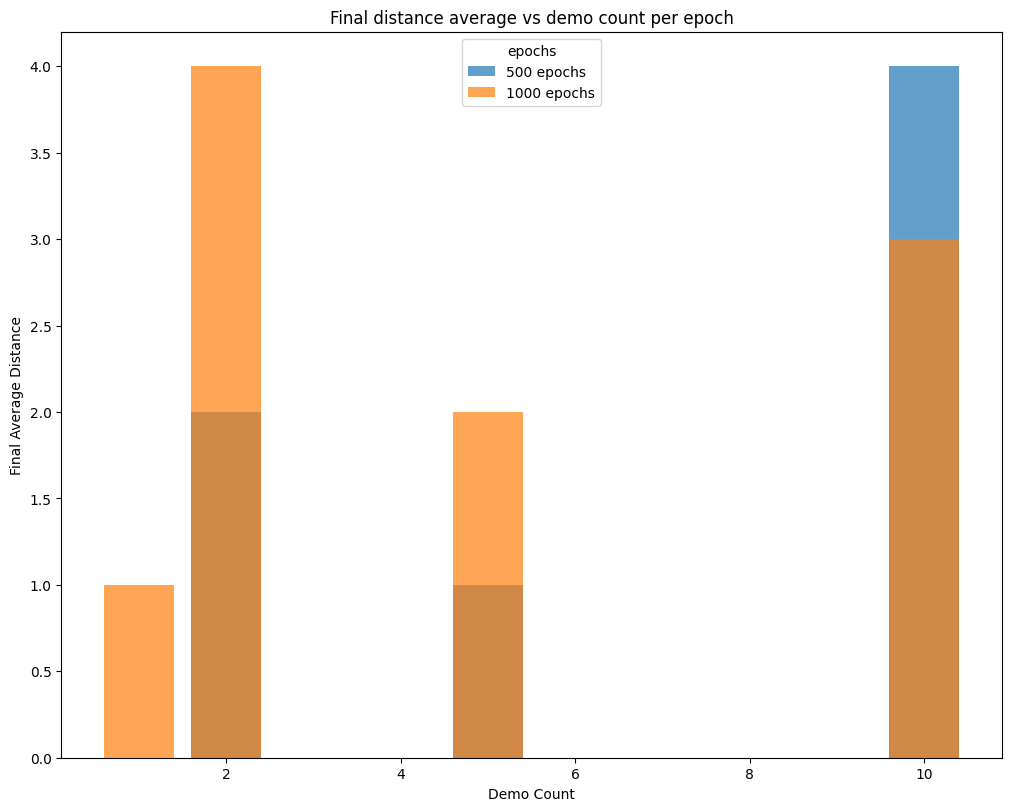

In [32]:
fix, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout = True)
ax.bar(df500["demo_count"], df500["reached_count"], label = "500 epochs", alpha = 0.7)
ax.bar(df1000["demo_count"], df1000["reached_count"], label = "1000 epochs", alpha = 0.7)

ax.set_title("Final distance average vs demo count per epoch")
ax.set_xlabel("Demo Count")
ax.set_ylabel("Final Average Distance")
ax.legend(title="epochs")
plt.show()

# Reach With Obstacle


## Using the Same Unchanhed Policy from NoObs
Will not be looking at the reached counts, at this point there was no way of checking within err `within_err` in `run_task`, and this did not perform well anyway

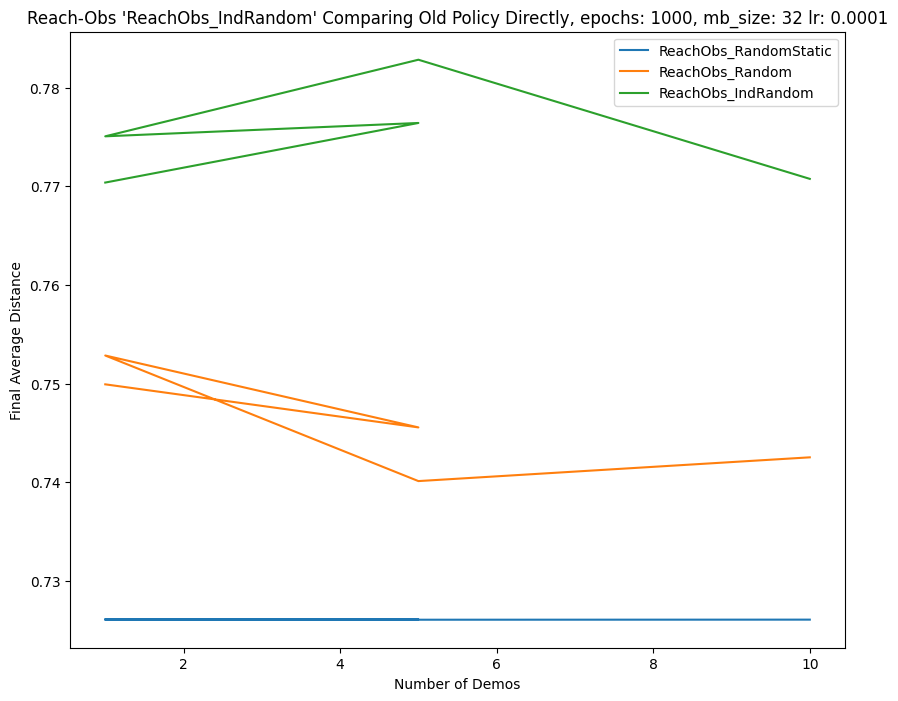

In [41]:
df = pd.read_csv("run-csvs/reach-obs/policy-improvement-resutls.csv")
df

epoch = 1000
mb = 32
lr = 0.0001
tasks = df["task_name"].unique()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for task in tasks:
  task_df = df[df["task_name"] == task]
  ax.plot(task_df["demo_count"], task_df["final_dist_avg"], label=task)
  
    
  ax.set_title(f"Reach-Obs '{task}' Comparing Old Policy Directly, epochs: {epoch}, mb_size: {mb} lr: {lr}")
  ax.set_xlabel("Number of Demos")
  ax.set_ylabel("Final Average Distance")
  ax.legend()
plt.show()

## Checking Policy Imrovements
done on task: `ReachObs_Random`

The main checks are more training and more demos

tried:
```python
demos = [5, 10, 15, 20]
{
  "epochs": [500, 1000]
  "mb_size": 64, 
  "lr": 0.01 ## newer systems are using cosiune annealing!
}
```
still not bery good, not consistently reaching need to find a better strategy to teach


In [57]:
df500 = pd.read_csv("run-csvs/reach-obs/5-10-15-20-SAME-demos-camtype-comparison-reachobs_random-500-001-64.csv")
df1000 = pd.read_csv("run-csvs/reach-obs/5-10-15-20-SAME-demos-camtype-comparison-reachobs_random-1000-001-64.csv")

df500["reached_count"] = df500["has_reached"].apply(lambda row: parse_list_bools(row).sum())
df1000["reached_count"] = df1000["has_reached"].apply(lambda row: parse_list_bools(row).sum())



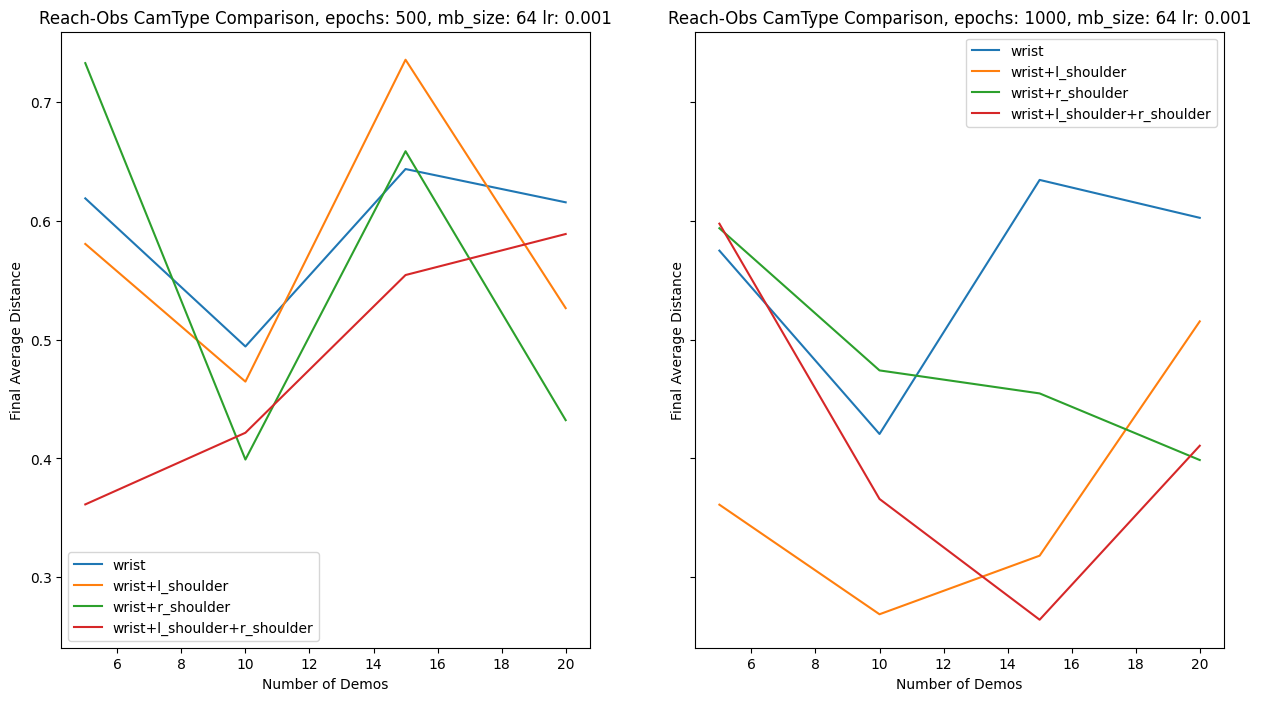

In [ ]:
figsize = 15, 8
fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=True)

cam_types = df500["cam_type"].unique()
dfs = [df500, df1000]
epochs = [500, 1000]
mb = 64
lr = 0.001

for di, df in enumerate(dfs):
  for cam_type in cam_types:
    row_df = df[df["cam_type"] == cam_type]
    ax[di].plot(row_df["demo_count"], row_df["final_dist_avg"], label=cam_type)
    
  ax[di].set_title(f"Reach-Obs CamType Comparison, epochs: {epochs[di]}, mb_size: {mb} lr: {lr}")
  ax[di].set_xlabel("Number of Demos")
  ax[di].set_ylabel("Final Average Distance")
  ax[di].legend()
plt.show()

# for i in range(2):
#   plt.plot(df["demo_count"], df["final_dist_avg"], label = f"demo_count {i+1}")

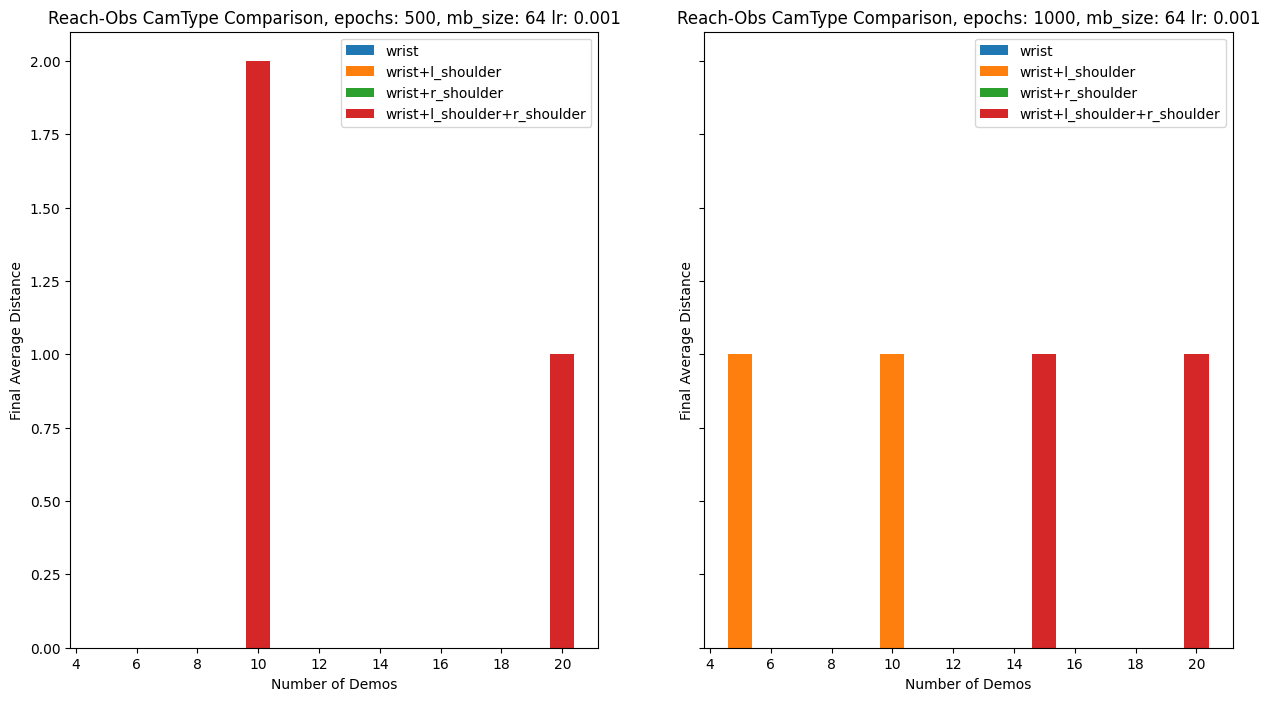

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=figsize, sharey=True)

for di, df in enumerate(dfs):
  for cam_type in cam_types:
    row_df = df[df["cam_type"] == cam_type]
    ax[di].bar(row_df["demo_count"], row_df["reached_count"], label=cam_type)
    
  ax[di].set_title(f"Reach-Obs CamType Comparison, epochs: {epochs[di]}, mb_size: {mb} lr: {lr}")
  ax[di].set_xlabel("Number of Demos")
  ax[di].set_ylabel("Final Average Distance")
  ax[di].legend()
  
plt.show()

## Checking Policy Improvements - Training Dataset Randomisation and Sampling
None of them are particularly good, there needs to be a different mechanism to check whether the randomisation is useful 

shuffling data works well, while ingesting, this will inherently shuffle the obs as well I think, so there is not reason to use `shuffle_obs_in_demo` really

In [9]:
df = pd.read_csv("run-csvs/reach-obs/2-5-10-shuffling-checks-reachobs_random.csv")
task_name  = "ReachObs_Random"
bool_combs = product([True, False], repeat=2)

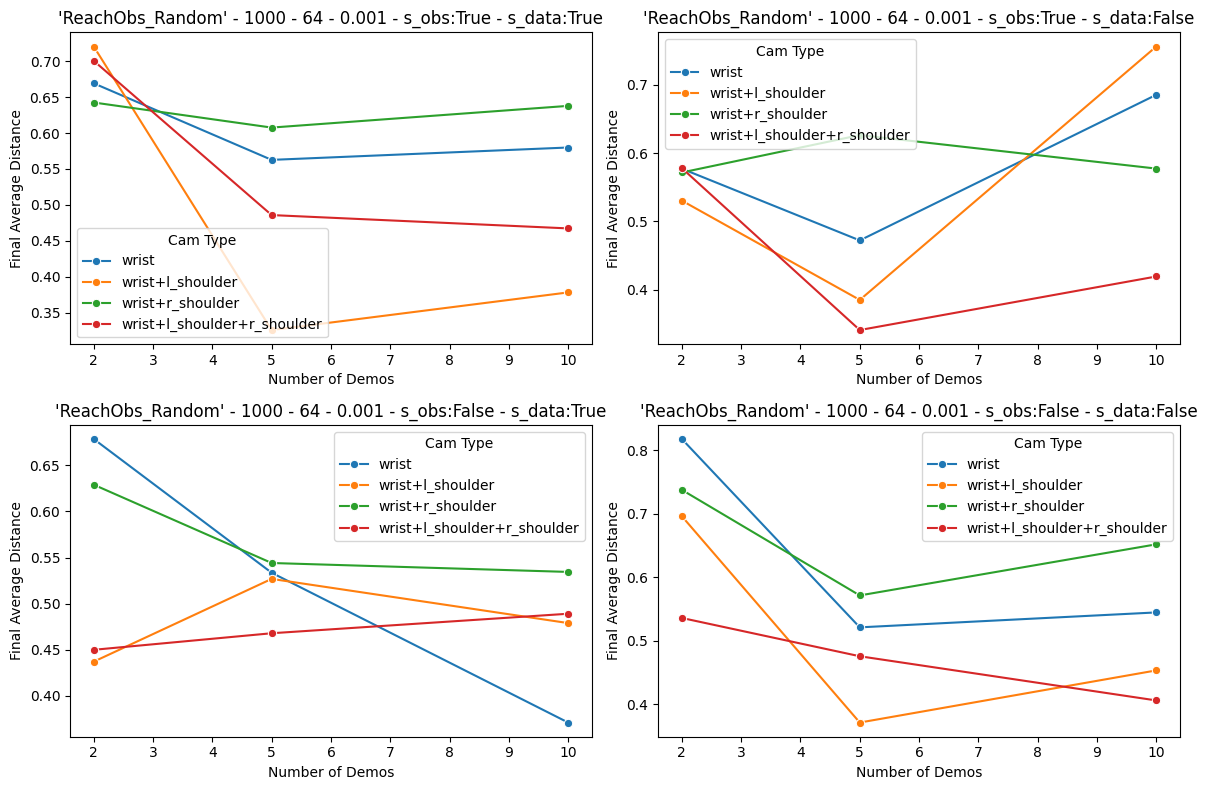

In [10]:


fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, (s_obs, s_data) in enumerate(bool_combs):
  opts_df = df[
    (df["shuffle_obs_in_demo"] == s_obs) &
    (df["shuffle_data"] == s_data) 
  ]
  sns.lineplot(ax=axes[i], data=opts_df, x="demo_count", y="final_dist_avg", hue="cam_type", marker="o")
  axes[i].set_title(f"'{task_name}' - 1000 - 64 - 0.001 - s_obs:{s_obs} - s_data:{s_data}")
  axes[i].set_xlabel("Number of Demos")
  axes[i].set_ylabel("Final Average Distance")
  axes[i].legend(title="Cam Type")
  

plt.tight_layout()
plt.show()


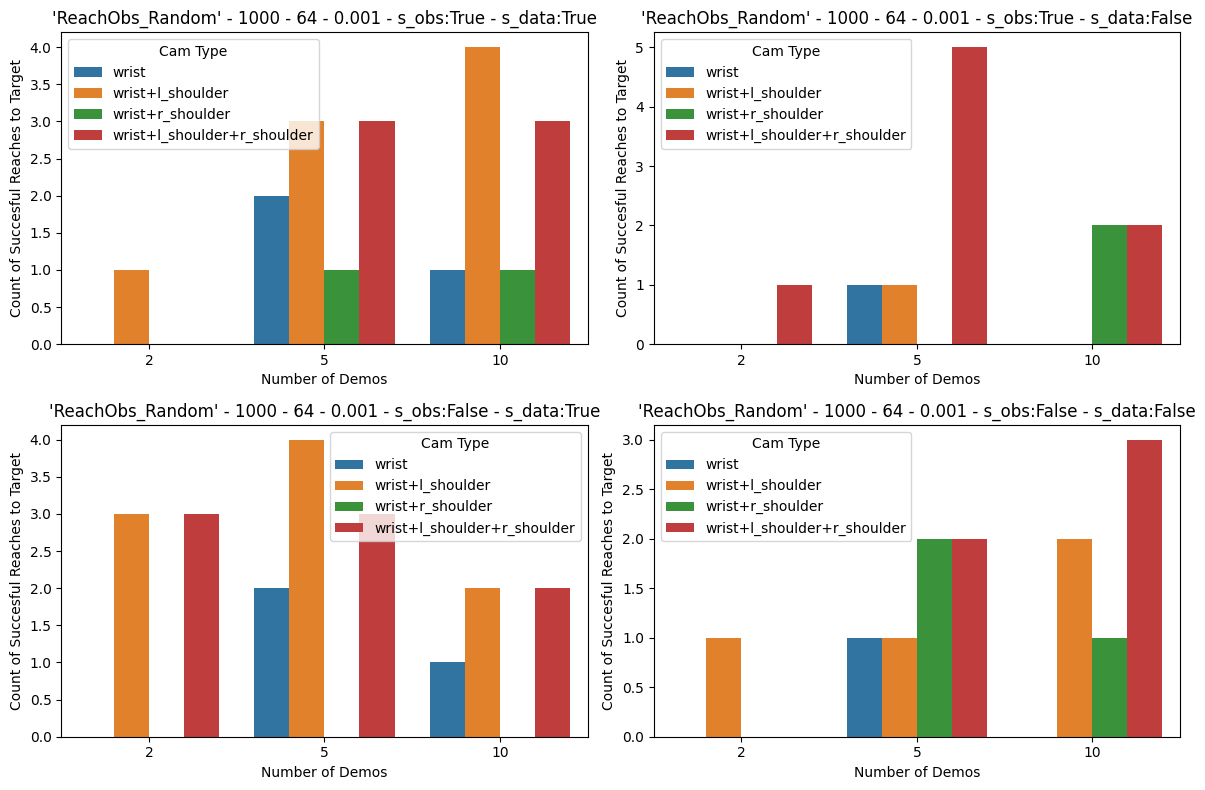

In [15]:

bool_combs = product([True, False], repeat=2)

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, (s_obs, s_data) in enumerate(bool_combs):
  opts_df = df[
    (df["shuffle_obs_in_demo"] == s_obs) &
    (df["shuffle_data"] == s_data) 
  ]
  sns.barplot(ax=axes[i], data=opts_df, x="demo_count", y="reached_count", hue="cam_type")
  axes[i].set_title(f"'{task_name}' - 1000 - 64 - 0.001 - s_obs:{s_obs} - s_data:{s_data}")
  axes[i].set_xlabel("Number of Demos")
  axes[i].set_ylabel("Count of Succesful Reaches to Target")
  axes[i].legend(title="Cam Type")
  

plt.tight_layout()
plt.show()


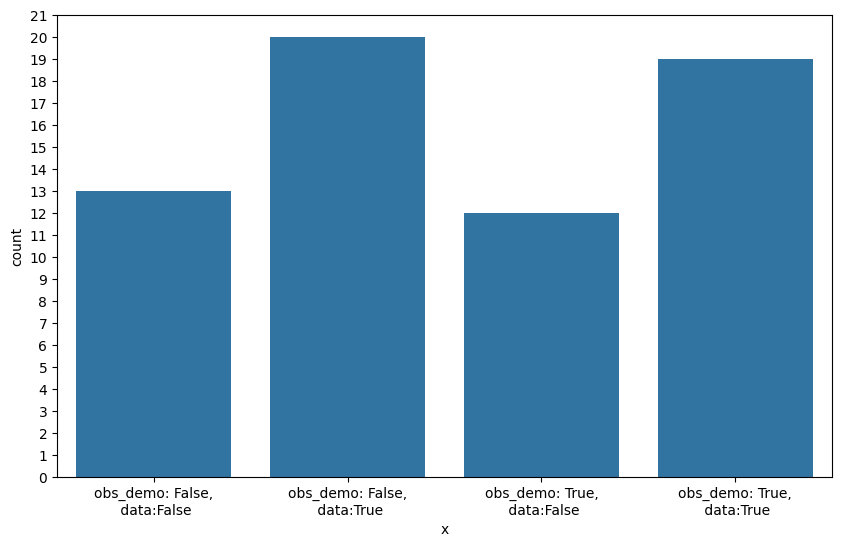

,shuffle_obs_in_demo,shuffle_data,count,x
0,False,False,13,"obs_demo: False,\n data:False"
1,False,True,20,"obs_demo: False,\n data:True"
2,True,False,12,"obs_demo: True,\n data:False"
3,True,True,19,"obs_demo: True,\n data:True"


In [18]:

grouped = df.groupby(["shuffle_obs_in_demo", "shuffle_data"])["reached_count"].apply("sum").reset_index(name = "count")
## name nicely
grouped["x"] = grouped.apply(
  lambda row: f"obs_demo: {row["shuffle_obs_in_demo"]},\n data:{row["shuffle_data"]}", axis=1
)


fig = plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, y="count", x="x")
# plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.show()
grouped


## Cam Attention checks with different cameras - 1st Time

These were trained with both the shuffling data settings turned to `False`, might have to run another time with the `shuffle_data` turned on?

```python
## params used
params = {
  "epochs": 1000,
  "minibatch_size": 64,
  "lr": 1e-3,
  "lr_eta_min": 1e-4,
  "shuffle_obs_in_demo": False, 
  "shuffle_data": False, 
  "lambda_attn": 1e-2,
}
```

Pooling method refers to the detection method used for the `colour_score()` method, 'mean' currently adds an epsilon of $1 \times 10^2$ to normalise, there might need to be more normalisation


### Multi-CNN Cam Attention
This network has a cnn feature extractor per camera
this works well to learn the interaction between the `colour_score` and the attention layer and helps extract important information per camera view.
However, a potential downside the `attention_score` and `action_score` terms in the **loss** might shave to be better tuned, chage their weightings for better results

In [88]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-multicnn.csv")

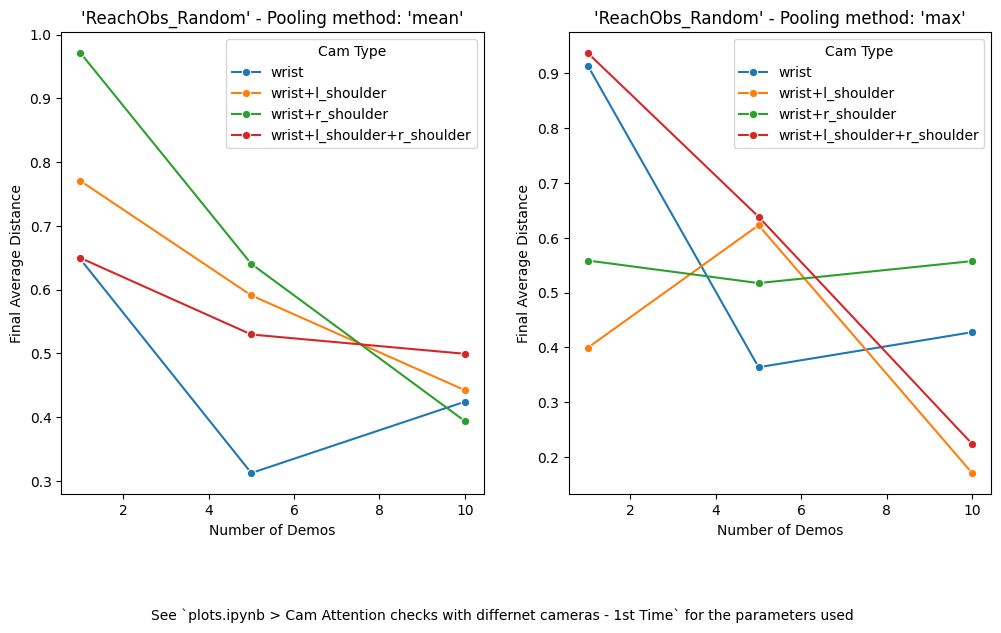

In [ ]:
plot_cam_attention(df, "ReachObs_Random")

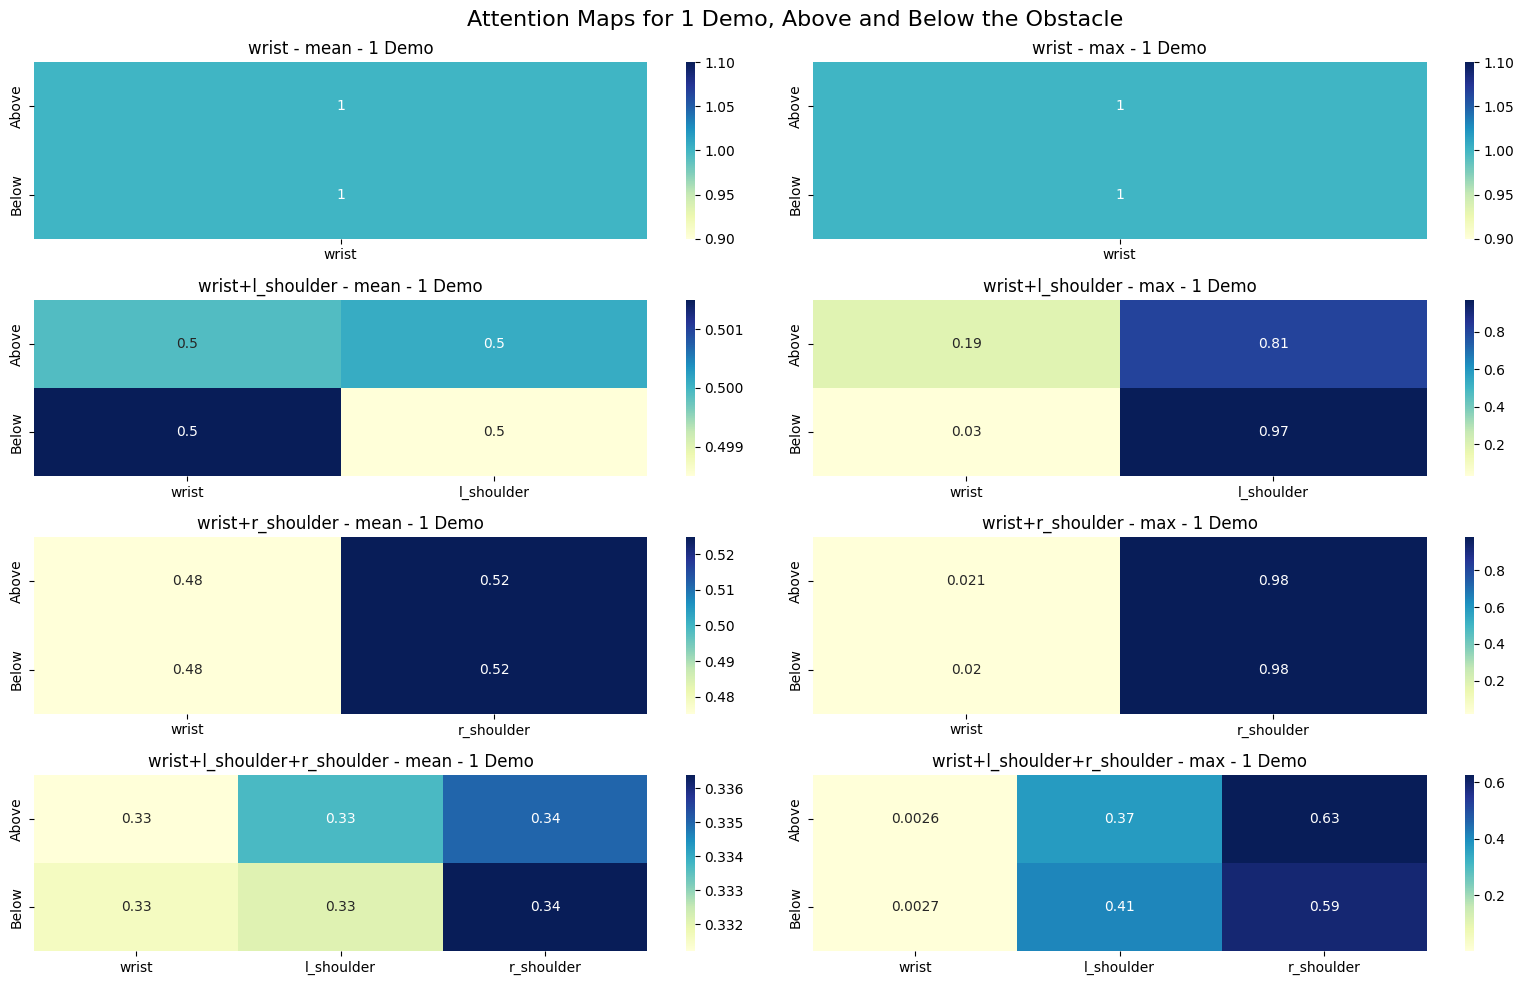

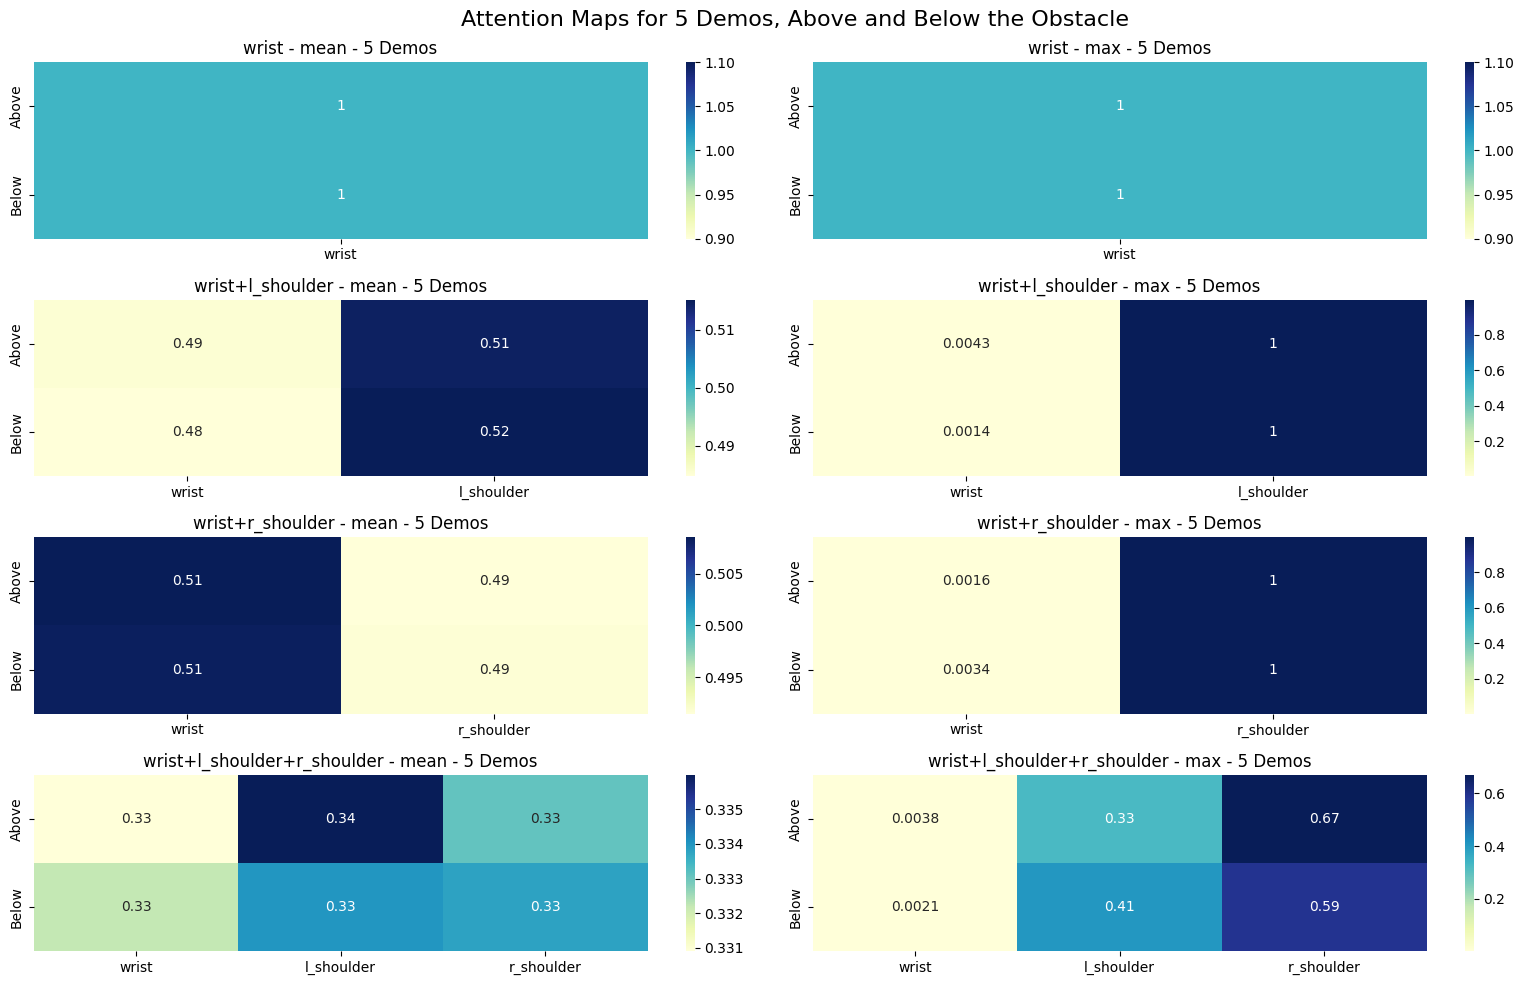

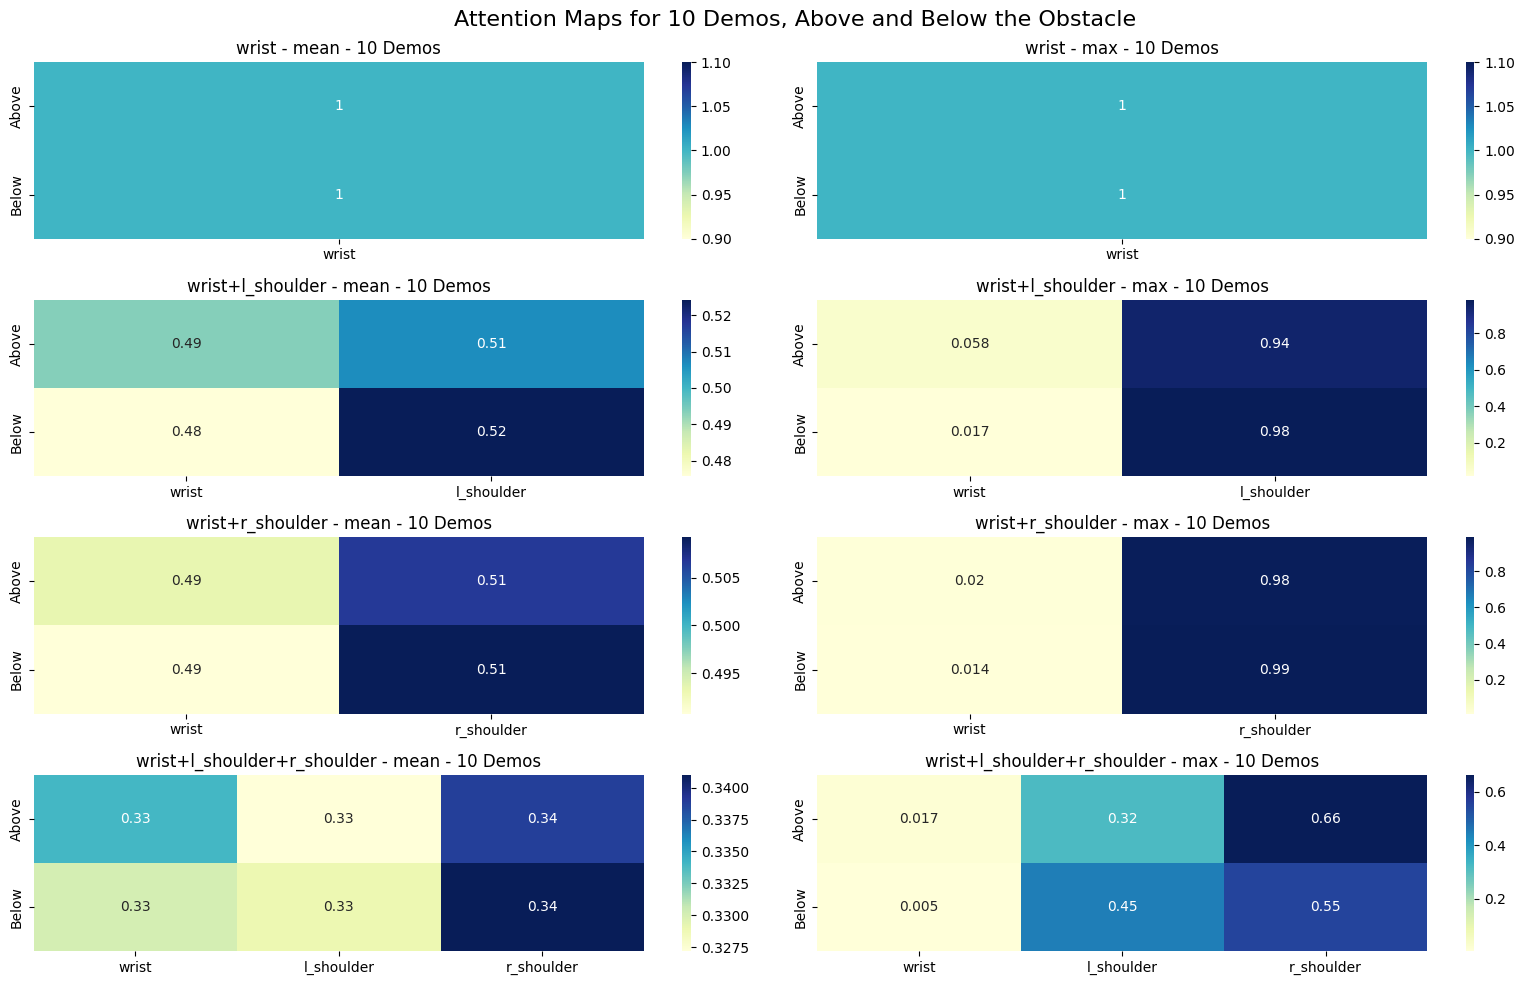

In [ ]:
plot_cam_attention_heatmap(df, fix_tensors=True)

### Single-CNN Cam Attention
This one, as the name suggests, is a single feature extractor from each camera, so the extractor should learn to extract similar features per camera. In theory I thought this would allow the inforamtion about the target, especially colour as I mainly use `colour_score` currently, to be extracted regardless of camera view.



In [92]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-singlecnn.csv")

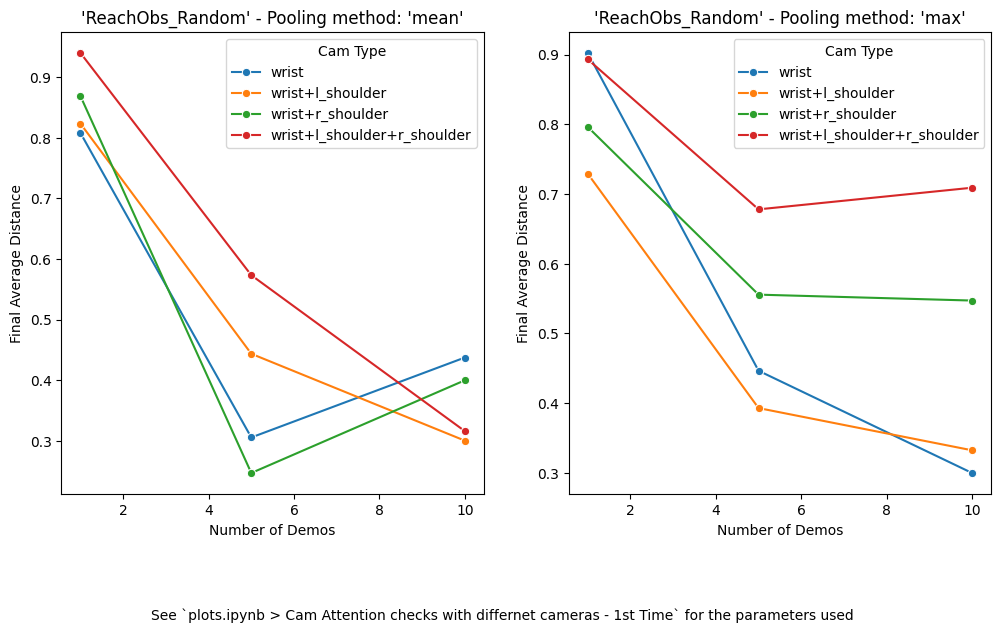

In [93]:
plot_cam_attention(df, "ReachObs_Random")

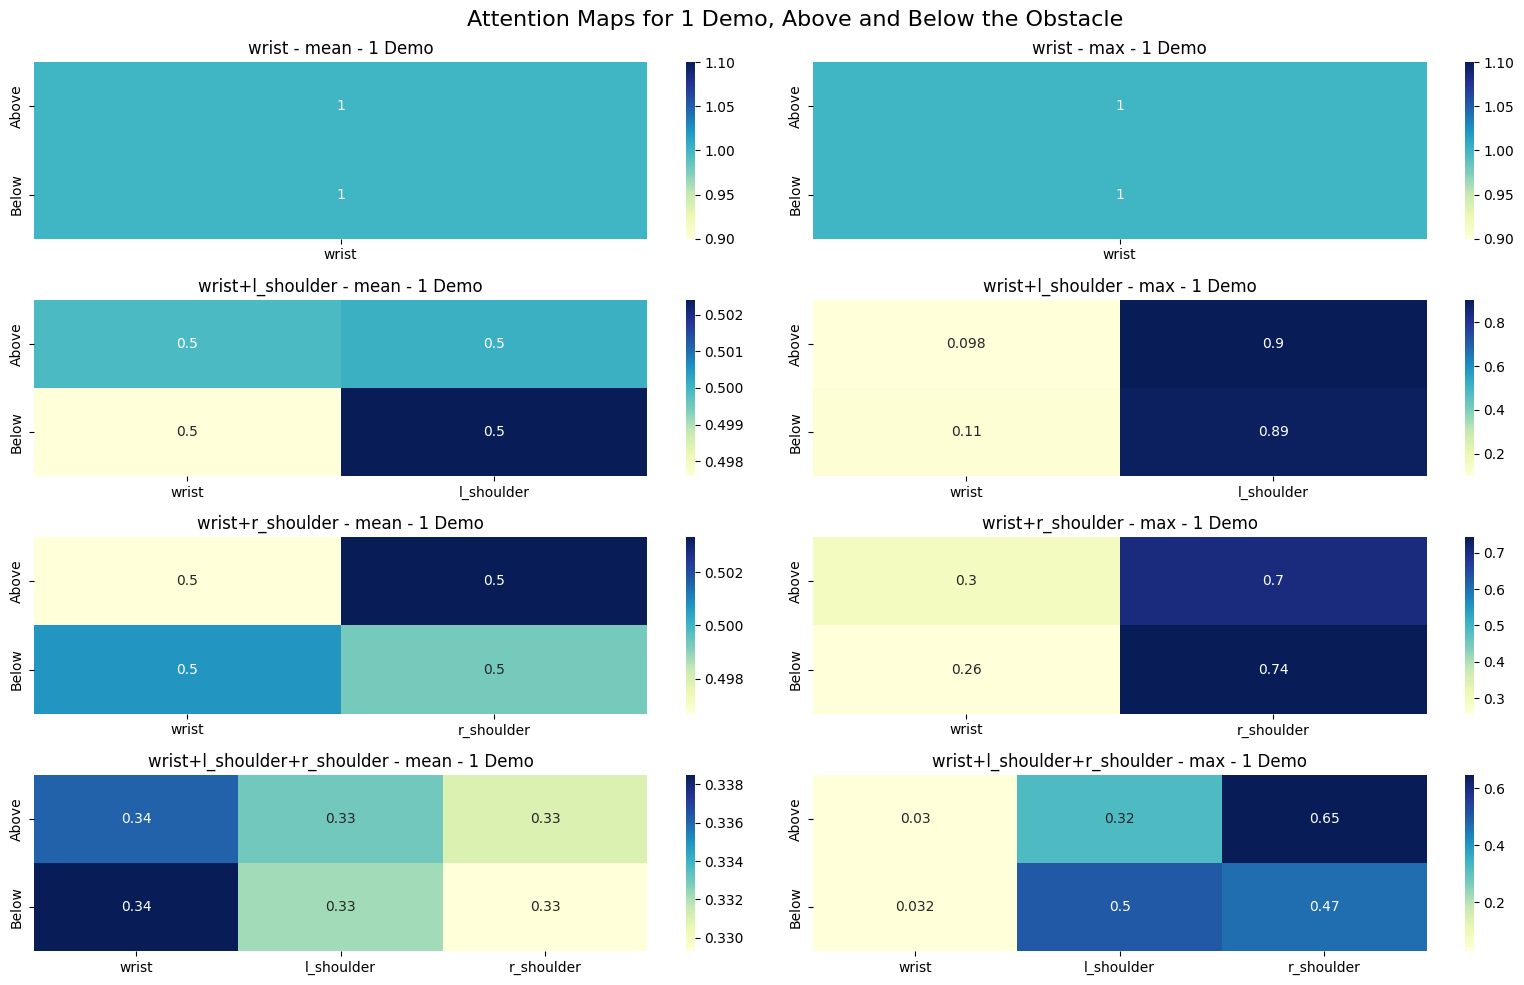

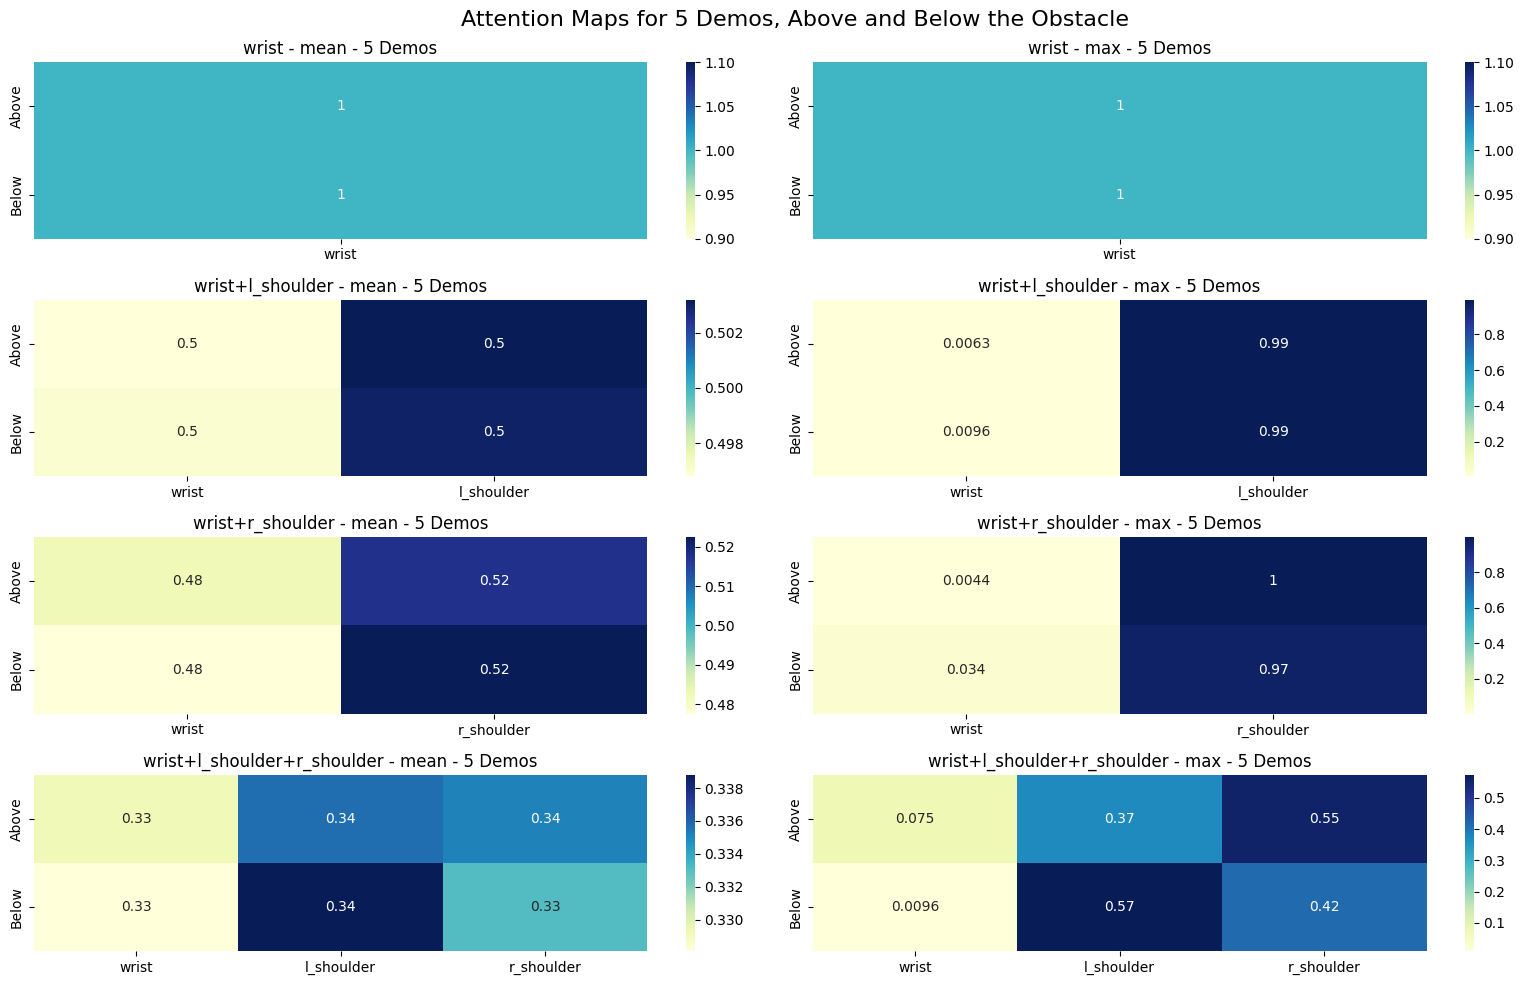

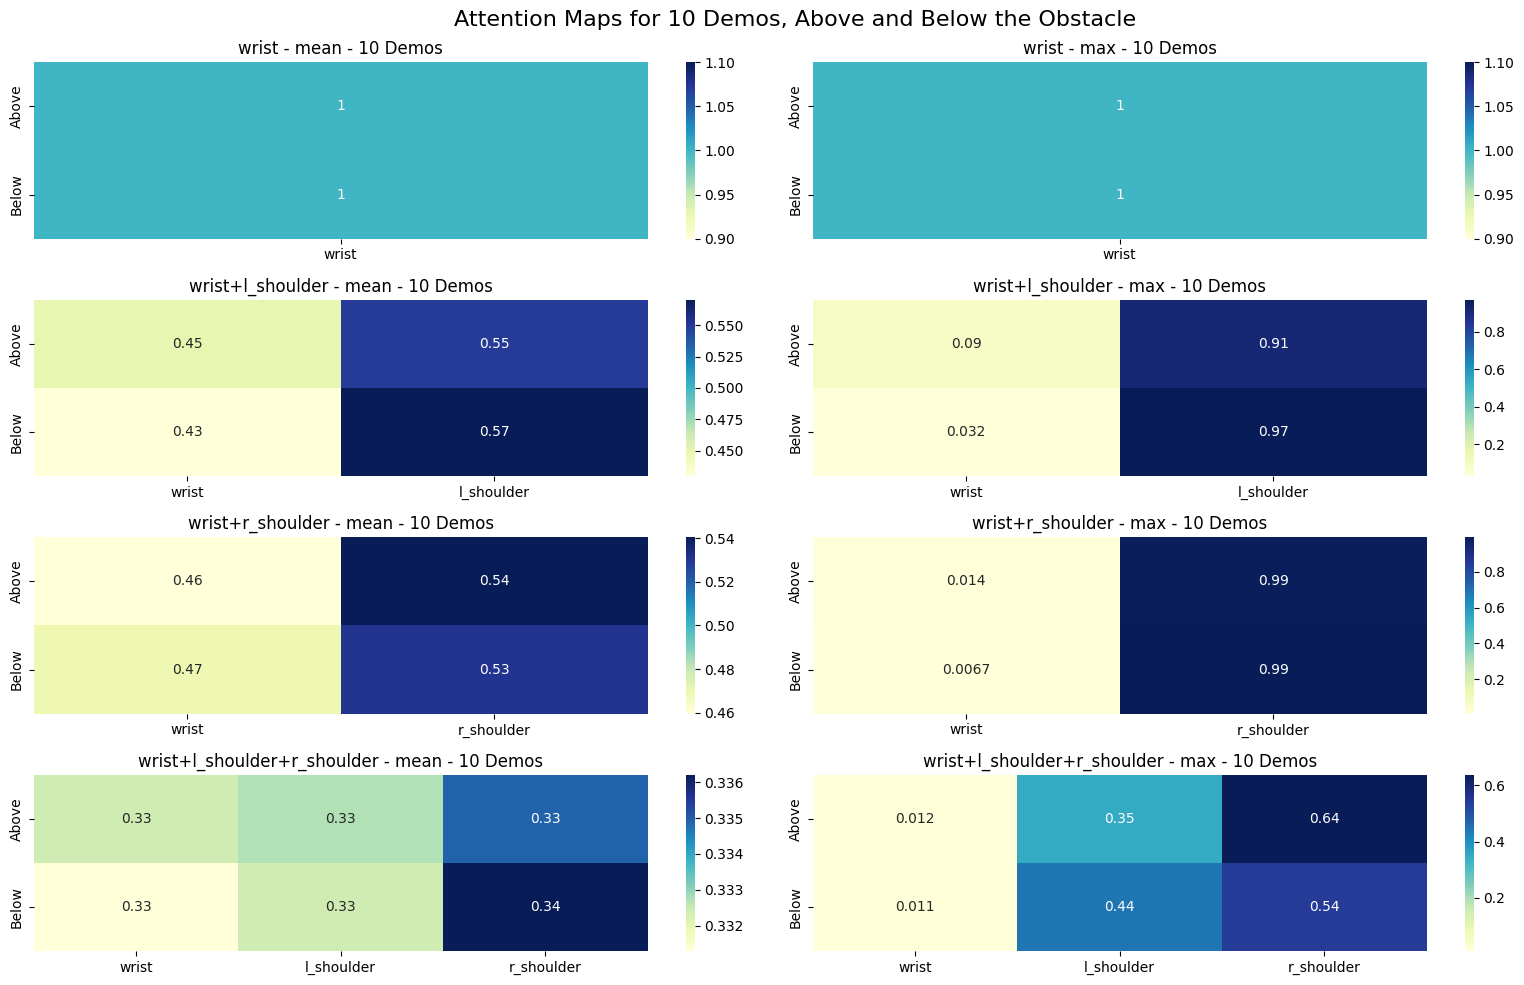

In [94]:
plot_cam_attention_heatmap(df, fix_tensors=True)

## Cam Attention Checks with different cameras - 2nd Time (shuffled training)
This now includes the `"shuffle_data": True` in the training, I think randomised training does help the network

### Multi-CNN Attention
Same as above but trained with the randomisation.

I didn't include the 1 demo here, so the graph is slightly shifted down and right, the scales are pretty much the same otherwise


In [95]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-multicnn-shuffled-training.csv")

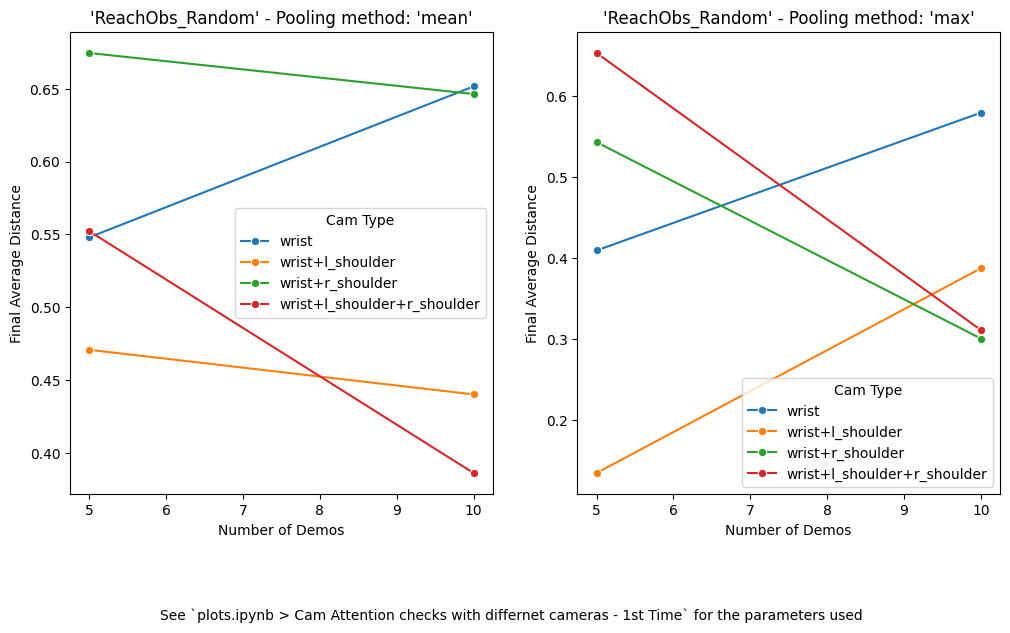

In [96]:
plot_cam_attention(df, "ReachObs_Random")

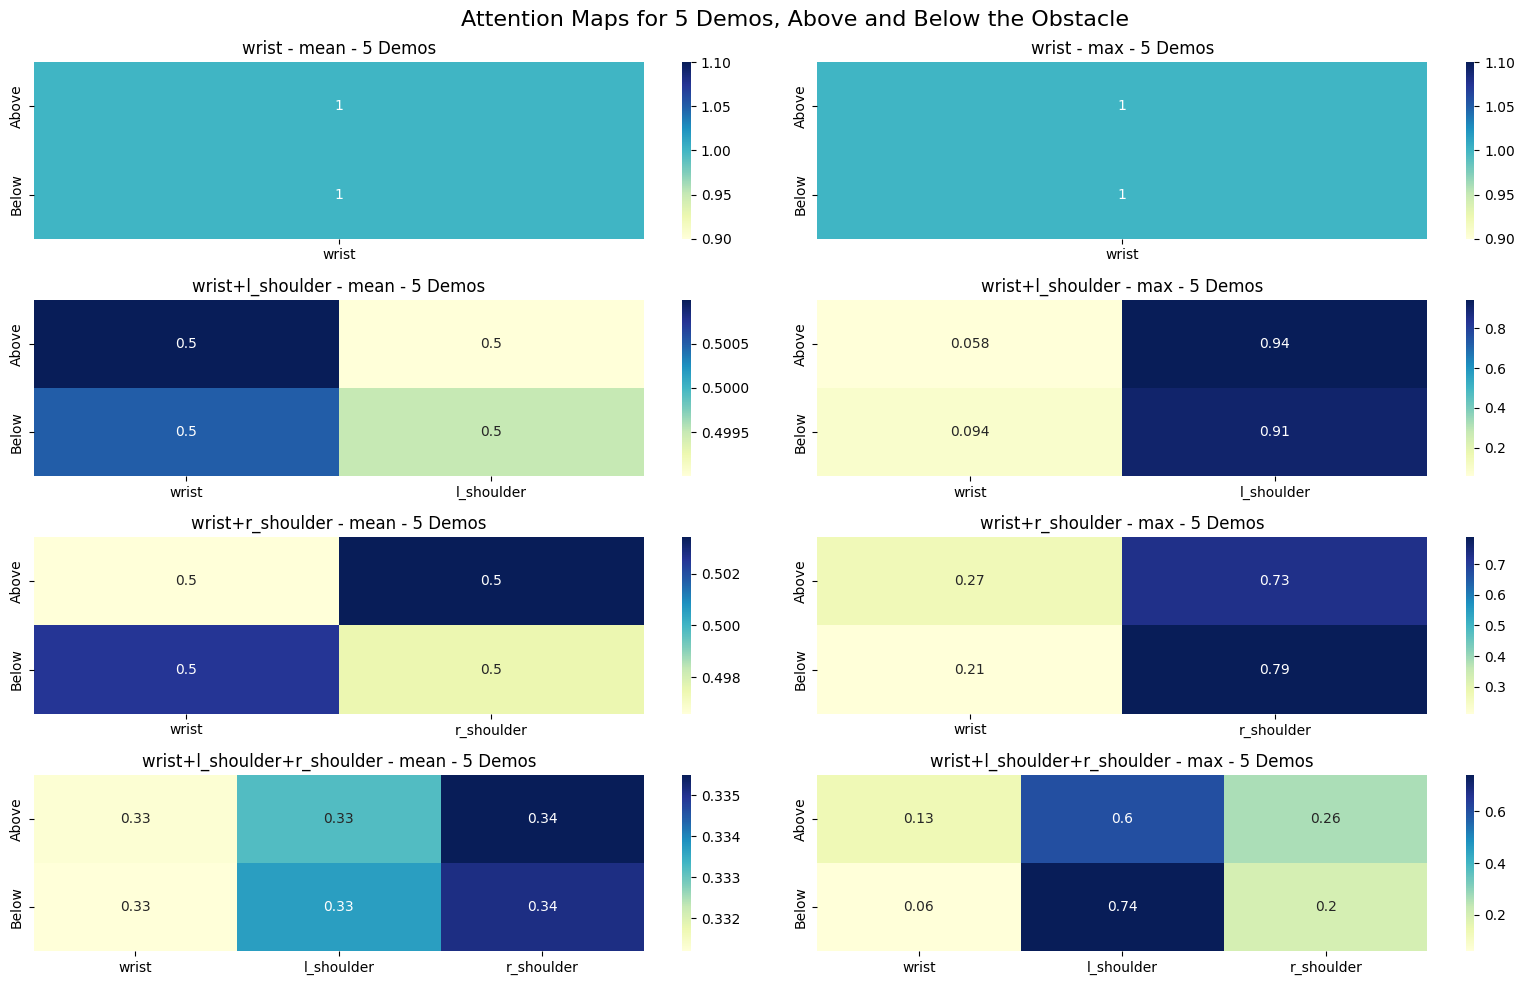

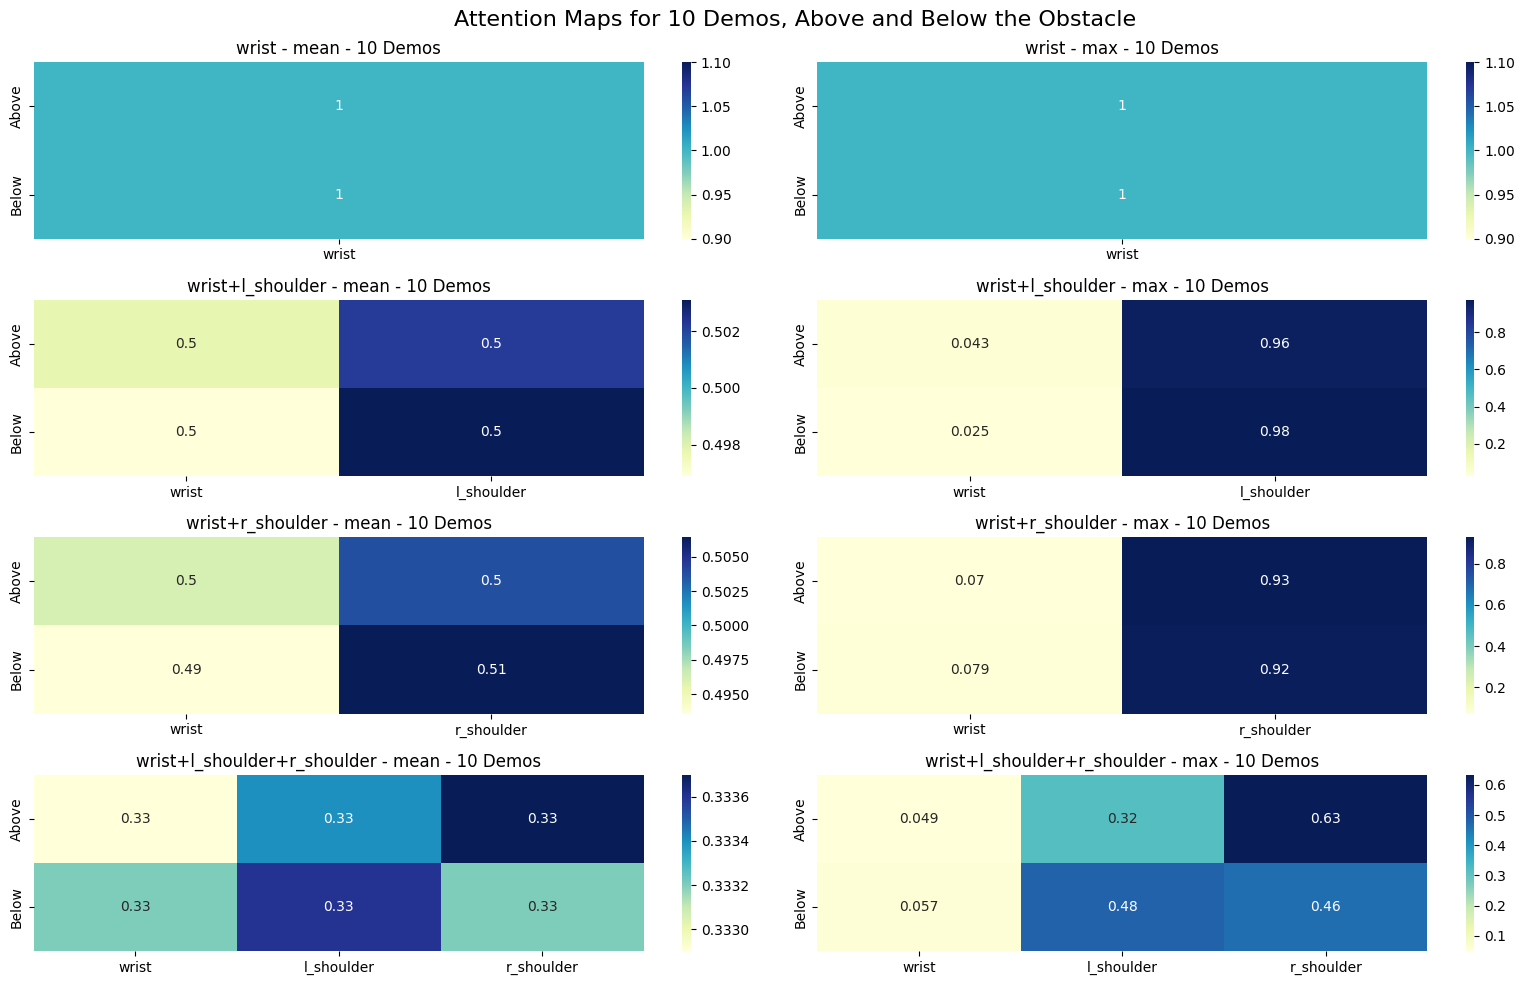

In [97]:
plot_cam_attention_heatmap(df, fix_tensors=True)

### Single-CNN Attention
This performs a lot better with shuffled data I think it is generalising better?

//TODO: Add these in the report before moving onto the ViT?

In [98]:
df = pd.read_csv("run-csvs/reach-obs/cam_attention_results-singlecnn-shuffled-training.csv")


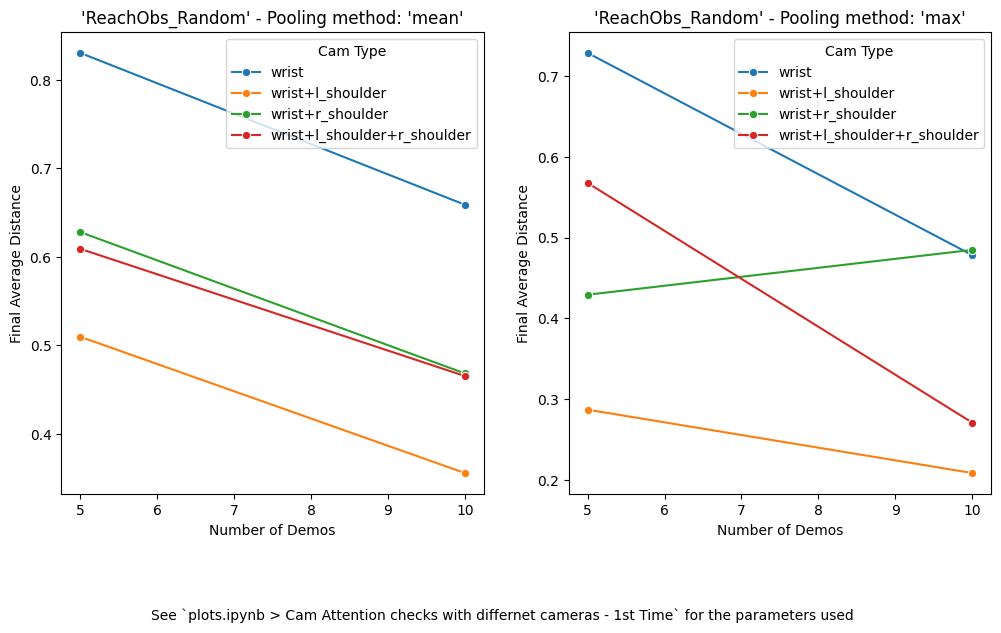

In [99]:
plot_cam_attention(df, "ReachObs_Random")

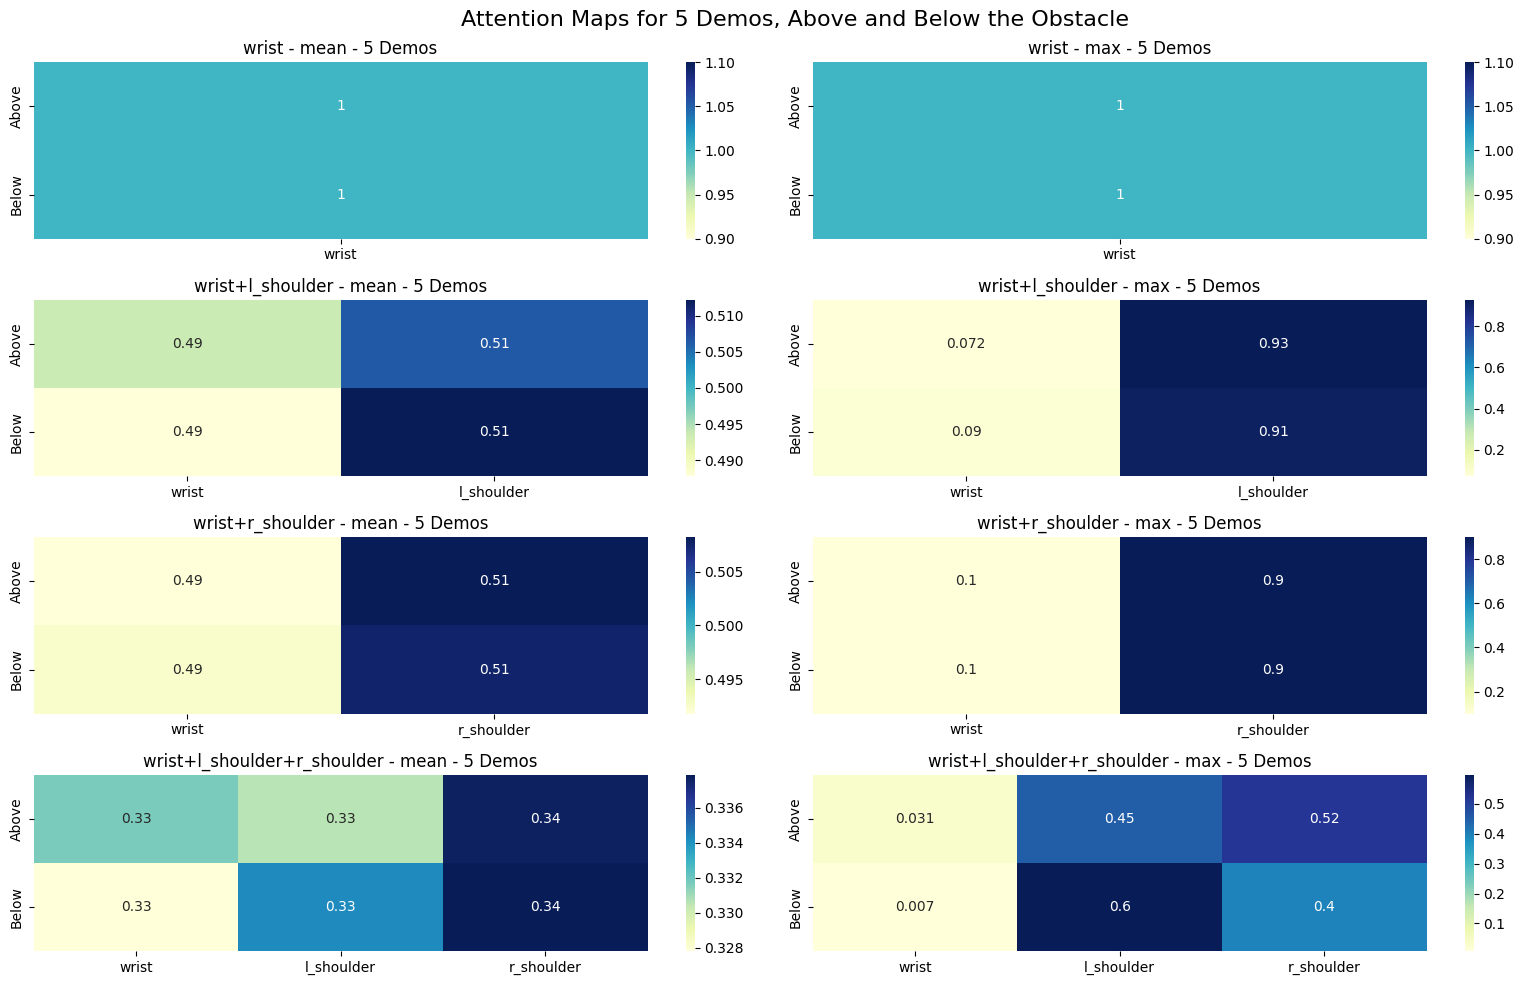

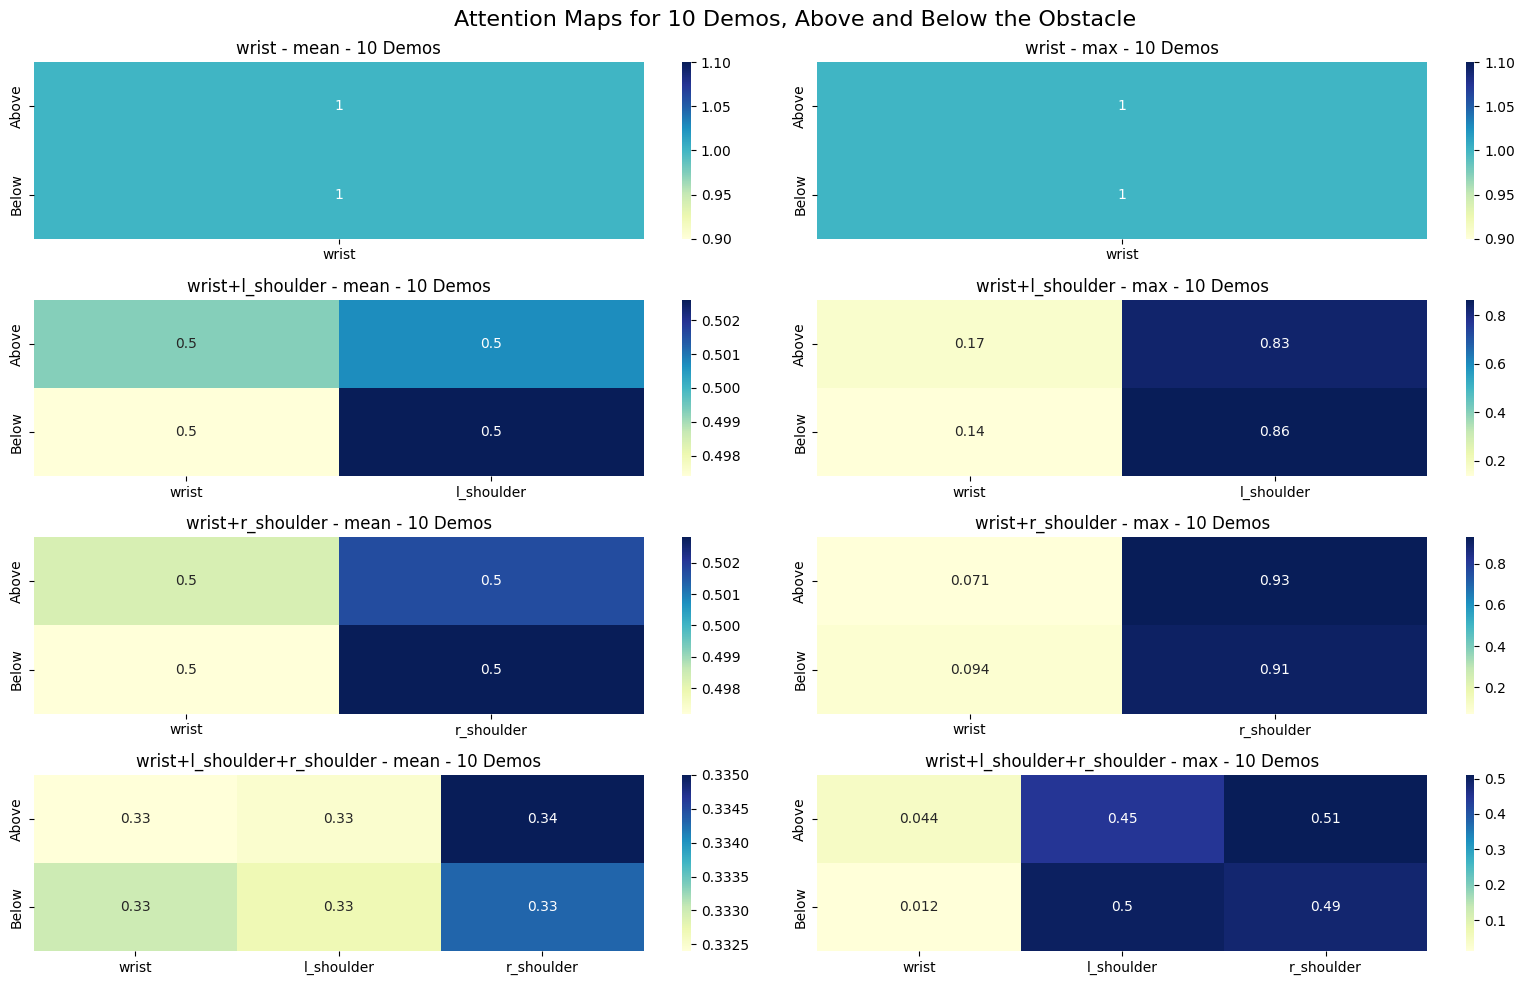

In [100]:
plot_cam_attention_heatmap(df, fix_tensors=True)


# Vision Experiments 


## Static Simple Grasp - Checking which cams work best
data is created using randomisation of training and 20 repeats.


### Single Cams
Checked one cam no combinations here

There are image outputs to what this policy is not nicely interpreting and peforming in. Check: `outputs/run-grasp-with-agent/` for some images of when the robot decides to grasp, successfully or not (check with the data to see success)

In [5]:
df = pd.read_csv("run-csvs/vision-exp/vision_single_static-results.csv")

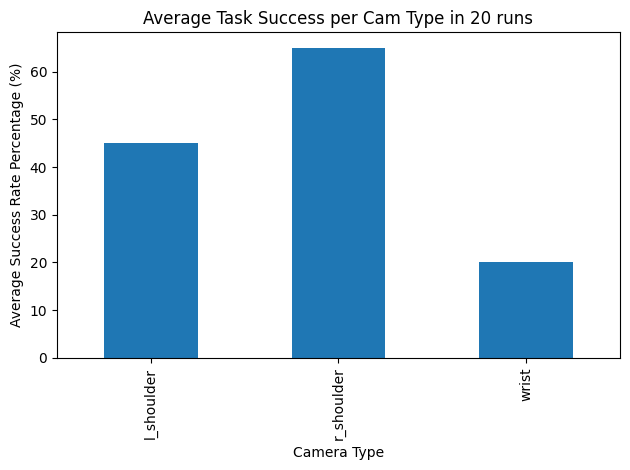

In [6]:
# Group by cam_type and compute average success
avg_success = df.groupby('cam_type')['is_success'].mean() * 100 ## %
# Plot
avg_success.plot(kind='bar', ylabel='Average Success Rate Percentage (%)', title='Average Task Success per Cam Type in 20 runs')
plt.xlabel('Camera Type')
plt.tight_layout()
plt.show()


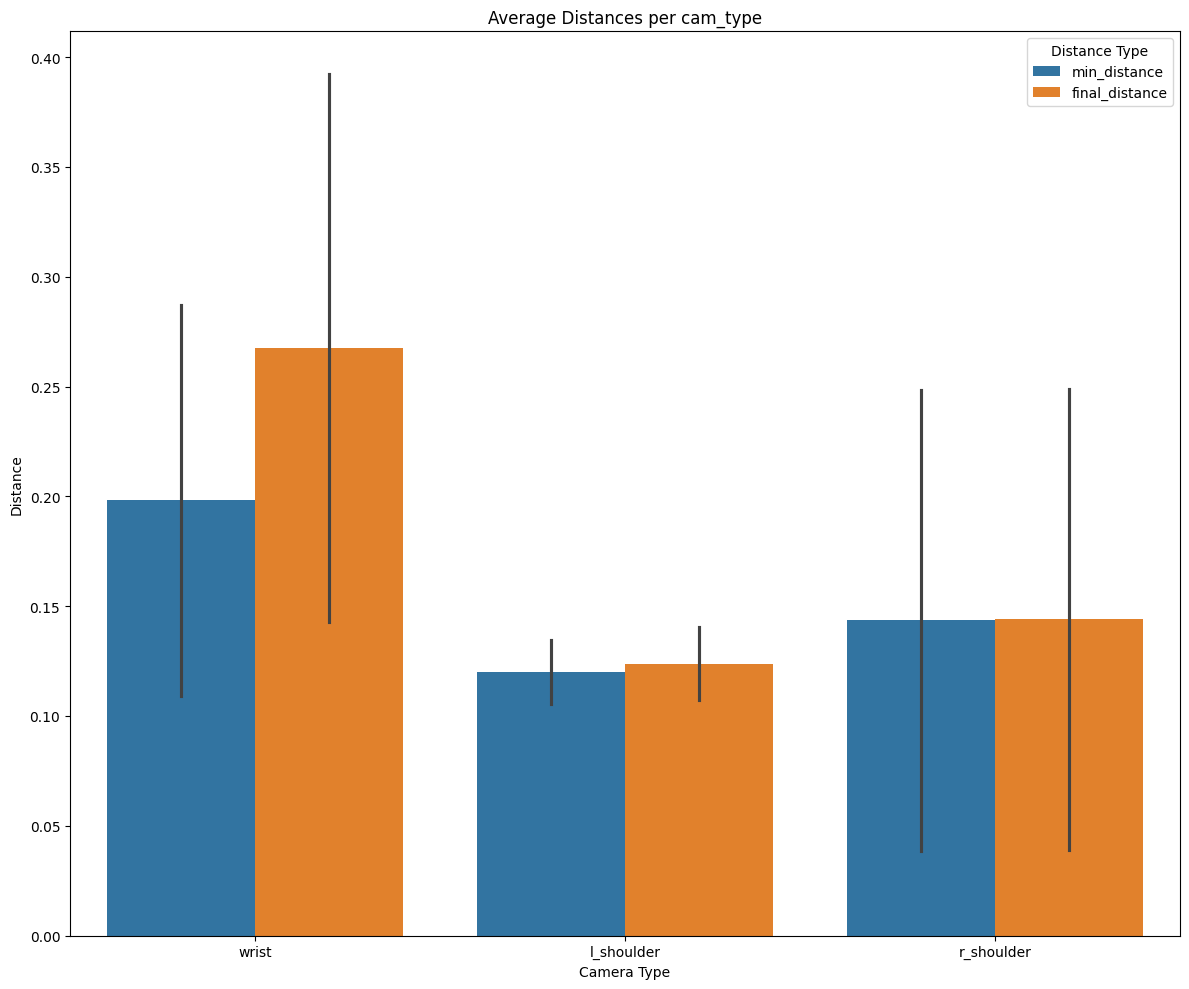

In [12]:
# Melt to long format
melted = df.melt(
    id_vars='cam_type',
    value_vars=['min_distance', 'final_distance'],
    var_name='distance_type',
    value_name='distance'
)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(data=melted, x='cam_type', y='distance', hue='distance_type', estimator='mean', errorbar='sd')
plt.title('Average Distances per cam_type')
plt.ylabel('Distance')
plt.xlabel('Camera Type')
plt.legend(title='Distance Type')
plt.tight_layout()
plt.show()


The `wrist` camera was allowed longer __max_eplen__ this is because the network would not do well with only `'demo_max'`, therefore its final distance is usally further away because it is forced to move for longer and without the ability to complete the task it just explores out-of-distribution areaas of the workspace


#### Wrist Camera - Experimenting with the `max_eplen`

The above plots give the wrist camera longer epidode length compared to the demo (~70 steps/action) while the _wrist_ is given $250$

So now checking with shorter allowance: $150$ and with `demo_max` as the others were ran

In [28]:
df = pd.read_csv("run-csvs/vision-exp/vision_single_static-just_wrist-results.csv")

old_df = pd.read_csv("run-csvs/vision-exp/vision_single_static-results.csv")

wrist_df = pd.concat([df, old_df[old_df["cam_type"] == "wrist"]], ignore_index = True)

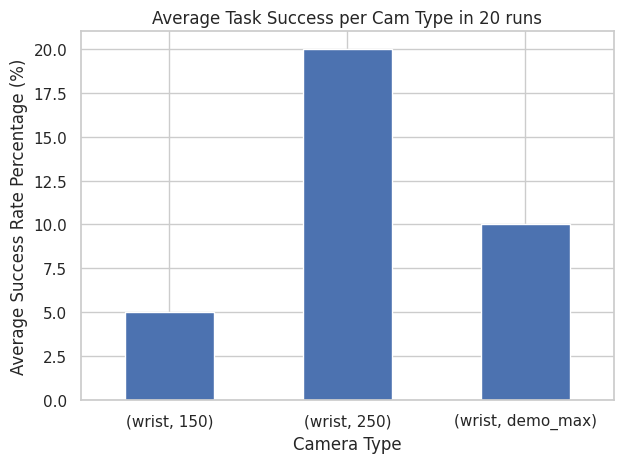

In [29]:
# Group by cam_type and compute average success
avg_success = wrist_df.groupby(['cam_type', "max_eplen"])['is_success'].mean() * 100 ## %


# Plot
avg_success.plot(kind='bar', ylabel='Average Success Rate Percentage (%)', title='Average Task Success per Cam Type in 20 runs')
plt.xlabel('Camera Type')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


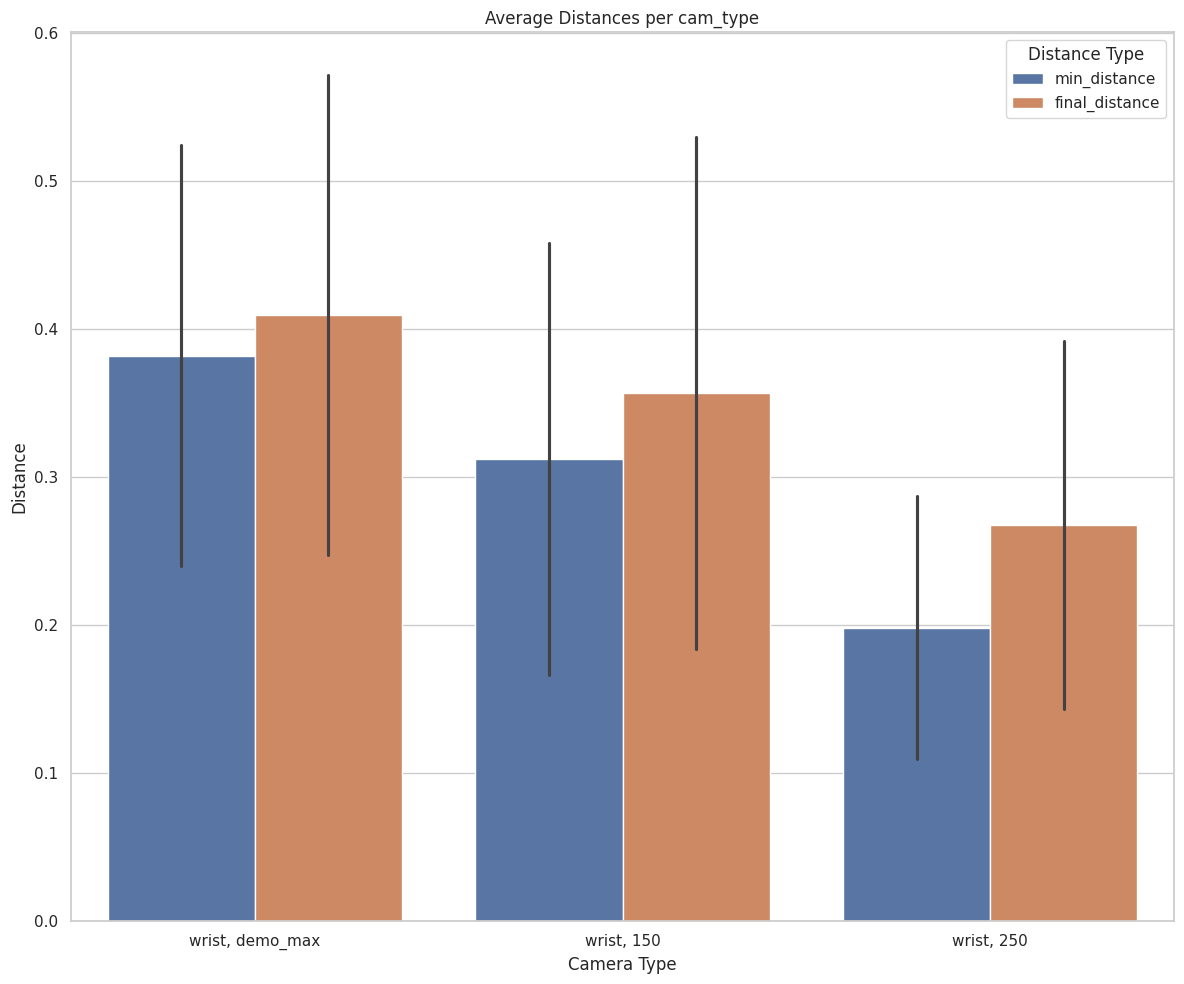

In [34]:
# Melt to long format

wrist_df["cam_eplen"] = wrist_df["cam_type"].astype(str)  + ", " + wrist_df["max_eplen"].astype(str)

melted = wrist_df.melt(
    id_vars="cam_eplen",
    value_vars=['min_distance', 'final_distance'],
    var_name='distance_type',
    value_name='distance'
)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(data=melted, x='cam_eplen', y='distance', hue='distance_type', estimator='mean', errorbar='sd')
plt.title('Average Distances per cam_type')
plt.ylabel('Distance')
plt.xlabel('Camera Type')
plt.legend(title='Distance Type')
plt.tight_layout()
plt.show()


so with this we can conclude that the wrist camera just does not work well alone, It doesn't learn sufficiently, this might be the policies fault as I expected the wrist camera alone to generalise better.

### Camera Combinations

In [37]:
df = pd.read_csv("run-csvs/vision-exp/vision_single_static-comb_cams-results.csv")

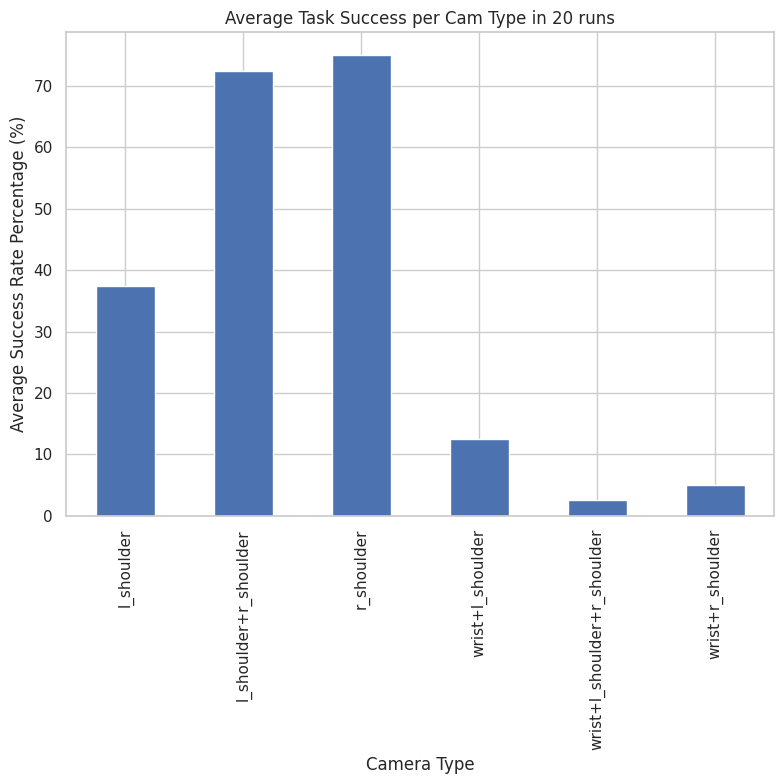

In [44]:
# Group by cam_type and compute average success
avg_success = df.groupby('cam_type')['is_success'].mean() * 100 ## %
# Plot
plt.figure(figsize=(8, 8))
avg_success.plot(kind='bar', ylabel='Average Success Rate Percentage (%)', title='Average Task Success per Cam Type in 20 runs')
plt.xlabel('Camera Type')
plt.xticks()
plt.tight_layout()
plt.show()


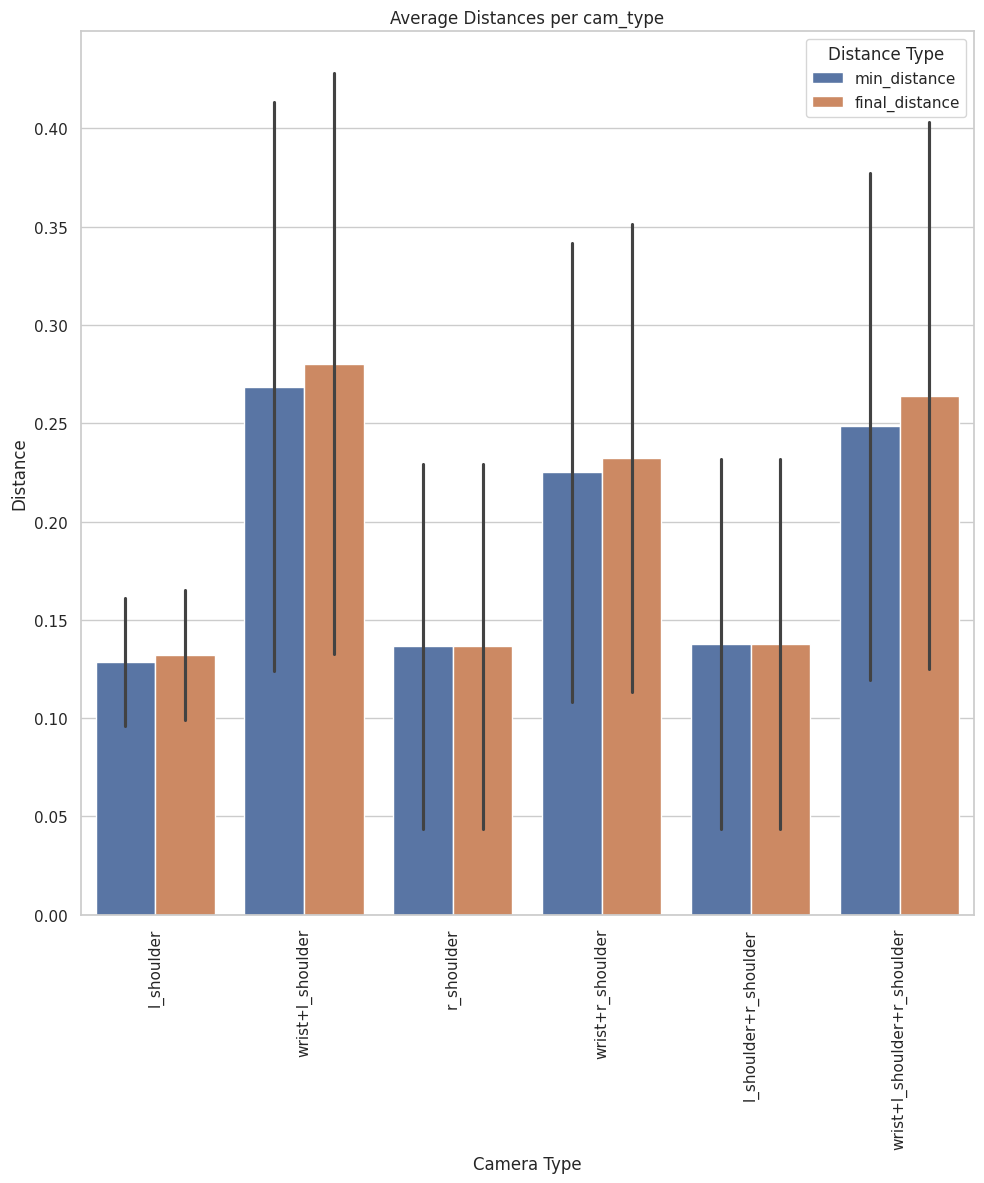

In [50]:
# Melt to long format
melted = df.melt(
    id_vars='cam_type',
    value_vars=['min_distance', 'final_distance'],
    var_name='distance_type',
    value_name='distance'
)

# Plot
plt.figure(figsize=(10, 12))
sns.barplot(data=melted, x='cam_type', y='distance', hue='distance_type', estimator='mean', errorbar='sd')
plt.title('Average Distances per cam_type')
plt.ylabel('Distance')
plt.xticks(rotation=90)
plt.xlabel('Camera Type')
plt.legend(title='Distance Type')
plt.tight_layout()
plt.show()


### All together

This for better visualisation of everything

In [53]:
df = pd.read_csv("run-csvs/vision-exp/vision_single_static-results.csv")
df_combs =  pd.read_csv("run-csvs/vision-exp/vision_single_static-comb_cams-results.csv")

df = pd.concat([df, df_combs], ignore_index=True)

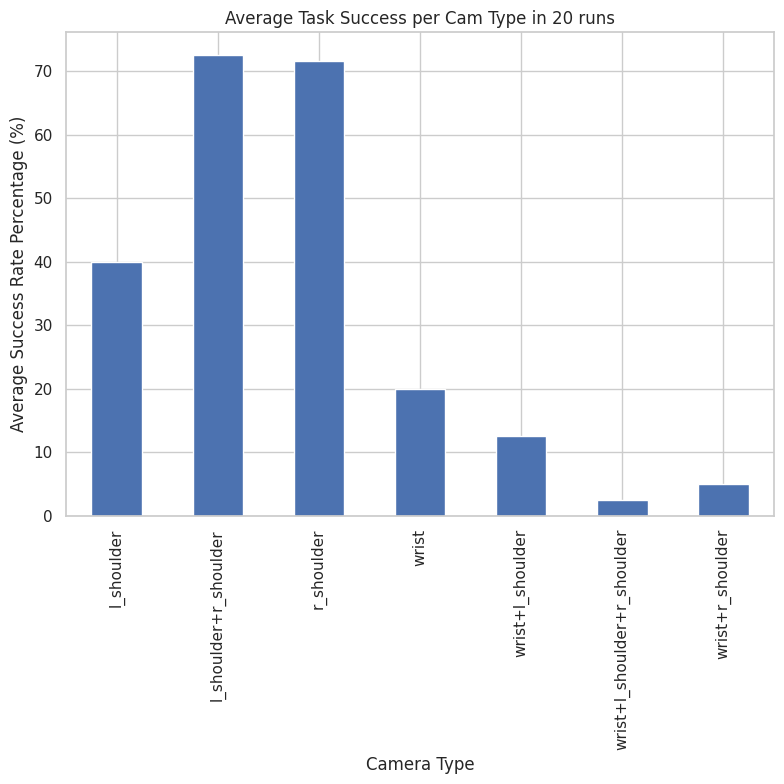

In [54]:
# Group by cam_type and compute average success
avg_success = df.groupby('cam_type')['is_success'].mean() * 100 ## %
# Plot
plt.figure(figsize=(8, 8))
avg_success.plot(kind='bar', ylabel='Average Success Rate Percentage (%)', title='Average Task Success per Cam Type in 20 runs')
plt.xlabel('Camera Type')
plt.xticks()
plt.tight_layout()
plt.show()


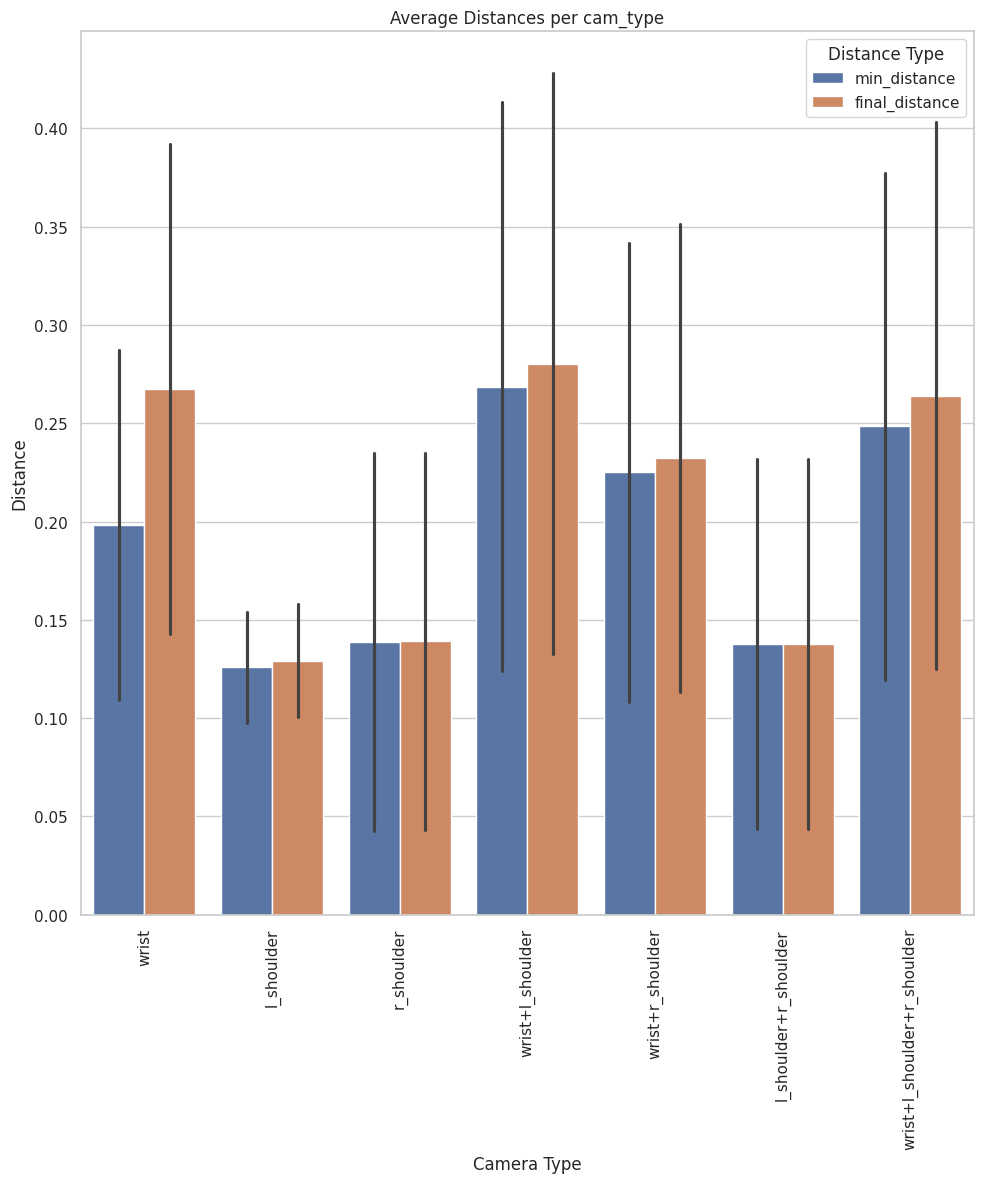

In [55]:
# Melt to long format
melted = df.melt(
    id_vars='cam_type',
    value_vars=['min_distance', 'final_distance'],
    var_name='distance_type',
    value_name='distance'
)

# Plot
plt.figure(figsize=(10, 12))
sns.barplot(data=melted, x='cam_type', y='distance', hue='distance_type', estimator='mean', errorbar='sd')
plt.title('Average Distances per cam_type')
plt.ylabel('Distance')
plt.xticks(rotation=90)
plt.xlabel('Camera Type')
plt.legend(title='Distance Type')
plt.tight_layout()
plt.show()


## Conclusions

Left and right shoulder seem to perform the best together and separately, mainly because I think inferring the depht information somehow helps to do the final grasp. Most of the times using the _left\_shoulder_ the robot gets very close (hence the small min and final distance) but either grabs too early and gets itself colliding witht he cube, and failing the task itself. 

Therefore the main takeaway is the _r\_shoulder_ is optimally placed for this task, and in the general randomised case I beleive the combination of the 2 broad seeing cameras allows the scene to be interpreted with more understanding and detial. 

Weirdly, I expected the wrist camera to work better than it did, because at the end of the day it is only a static demo and the robot should be fairly good at the copying the mvoeent, however the policy seems to not work very well for the wrist camera alone.

I think this is because the robot is seeing the box from very similar angles and hence the observations it uses are also very similar. This might be due to teh $64 \times 64$ size of the cameras. so each subsequent frame looks very similar and the policy cannot infer what to do at the start (wrist is slow, gets stuck near the starting position doing small movements), so it learns to event ually reach down, but the similarity in the observations it gets makes it tough to learn properly.

note for report:
no sense of __temporal dependency__, not sure where it is in the action and the policy is optimised to be the average of a sequence meaning the robot is averaged to slowly move down, but not understanding properly

### Notes on Combination

As to why any combinarion with _wrist_ performs worse than _just wrist_ and other combinations working on par with the rest suggests that the fusion of the observations might not be ideal -> work on a attention + muticnn version

### Notes on Hyperparameters
The params used here were tuned for the earlier reaching task however this is inherently a more sequential task and longer larger minibatch size would mean a greater understanding of the scene form a temporal point of view, therefore I think I need to experiment with longer sequences without shuffling

## Longer Sequence Length - 128, 256, 512 mb_size

Here I want to see the earlier plots for these with differnet hyperparams, to tune for the task
I think everything else is about right lr does not matter too much, epoch is good around 800 - 1000 for BC



In [75]:
df = pd.read_csv("run-csvs/vision-exp/vision_single_static-hpt-results.csv")

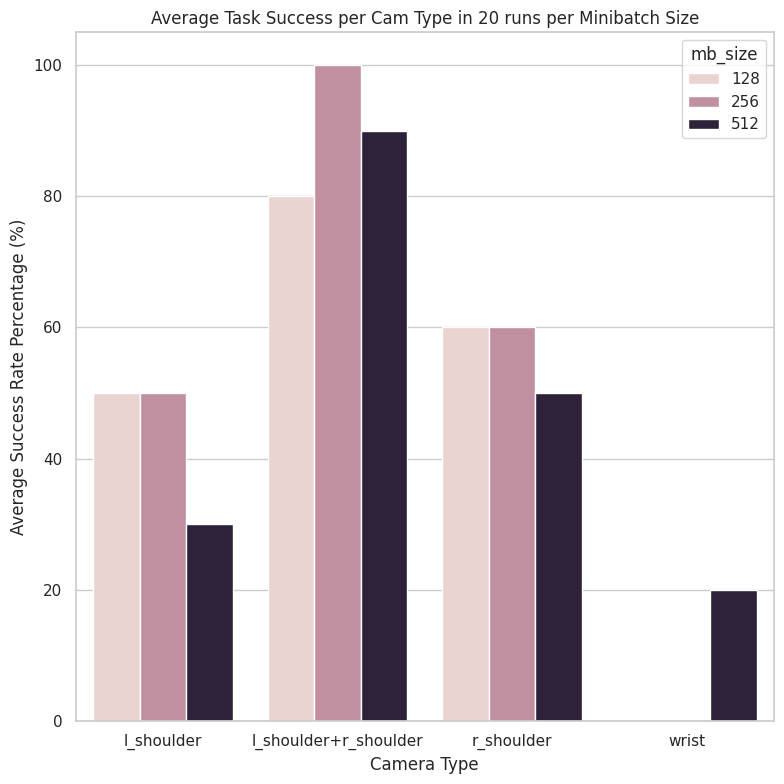

In [82]:
# Group by cam_type and compute average success
avg_success = (df.groupby(['cam_type', "mb_size"])['is_success'].mean() * 100).reset_index() ## %
# Plot
avg_success
plt.figure(figsize=(8, 8))
sns.barplot(data=avg_success, x="cam_type", y="is_success", hue="mb_size")
plt.xlabel('Camera Type')
plt.ylabel("Average Success Rate Percentage (%)")
plt.title("Average Task Success per Cam Type in 20 runs per Minibatch Size")
plt.xticks()
plt.tight_layout()
plt.show()


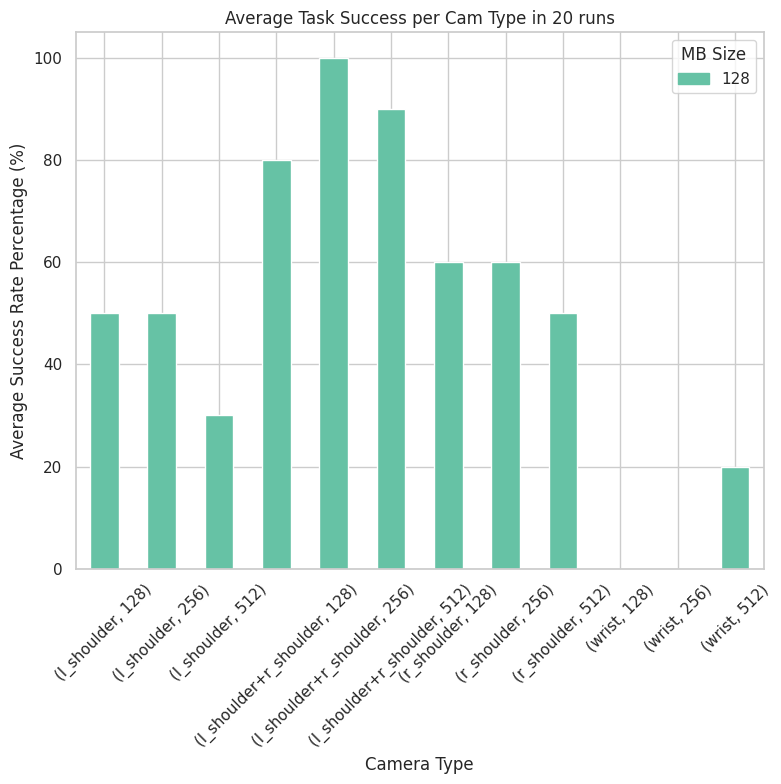

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute average success per cam_type
avg_success = df.groupby(['cam_type', "mb_size"])['is_success'].mean() * 100

# Get unique mb_size per cam_type
mb_sizes = df.groupby('cam_type')['mb_size'].first()

# Create a color palette
unique_mb_sizes = mb_sizes.unique()
palette = sns.color_palette("Set2", len(unique_mb_sizes))
color_map = dict(zip(unique_mb_sizes, palette))
bar_colors = mb_sizes.map(color_map)

# Plot
plt.figure(figsize=(8, 8))
avg_success.plot(
    kind='bar', 
    color=bar_colors,
    ylabel='Average Success Rate Percentage (%)',
    title='Average Task Success per Cam Type in 20 runs'
)
plt.xlabel('Camera Type')
plt.xticks(rotation=45)
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color=color_map[mb]) for mb in unique_mb_sizes
], labels=unique_mb_sizes, title='MB Size')
plt.tight_layout()
plt.show()


<Figure size 800x1200 with 0 Axes>

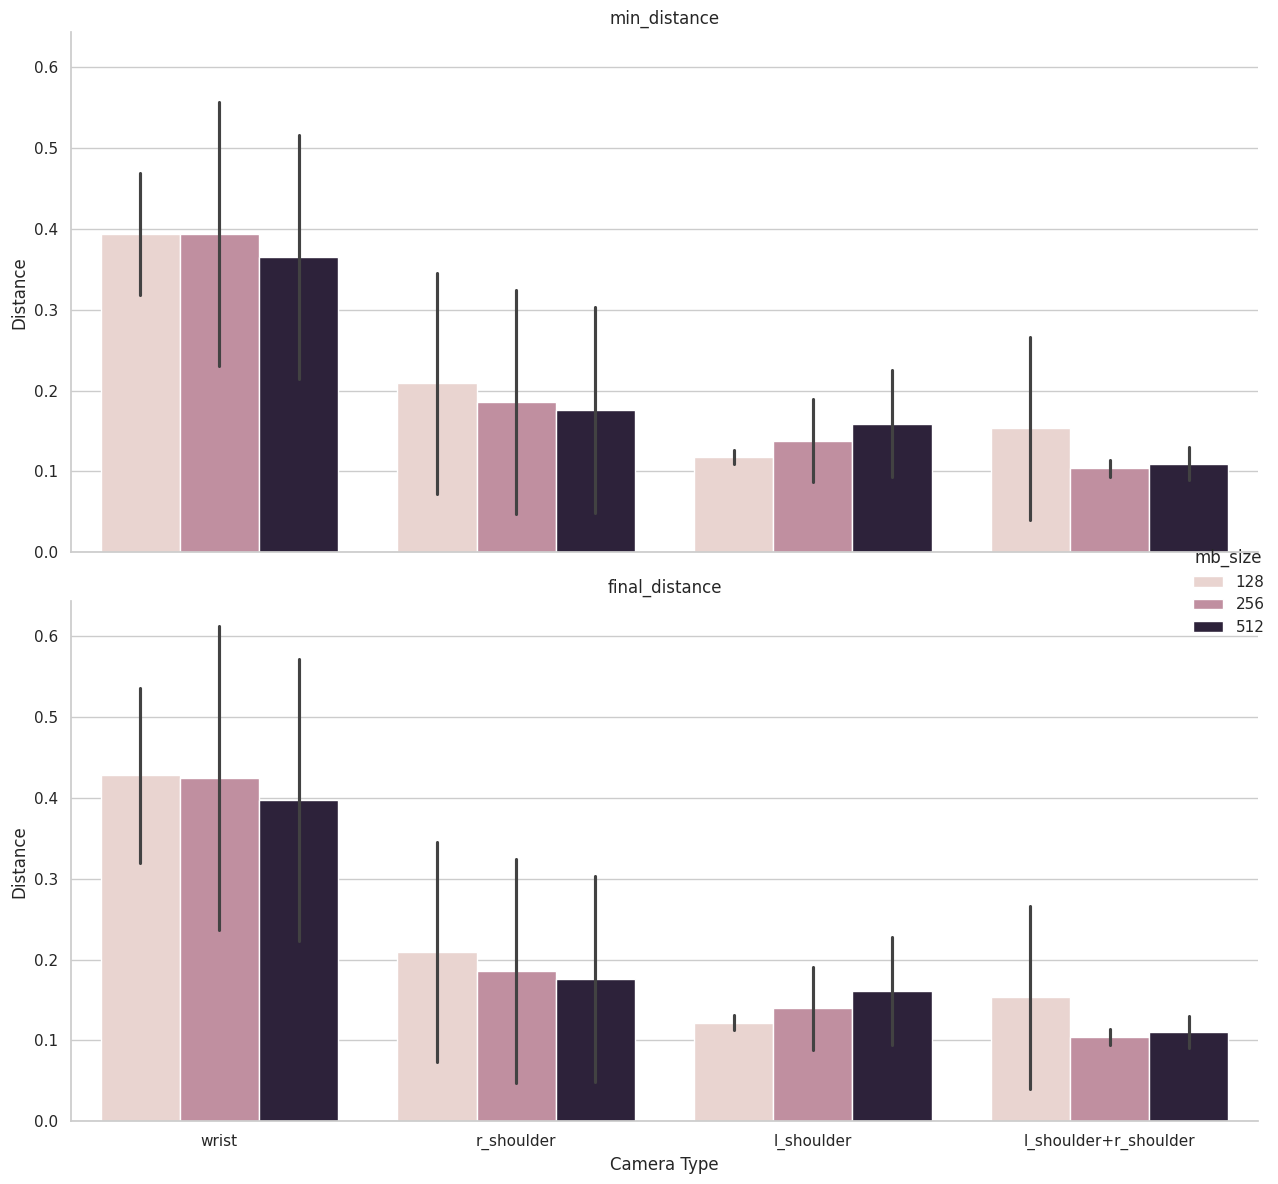

In [69]:
# Melt the distances
plt.figure(figsize=(8, 12))

melted = df.melt(
    id_vars=['cam_type', 'mb_size'],
    value_vars=['min_distance', 'final_distance'],
    var_name='distance_type',
    value_name='distance'
)

# Plot using facet grid
g = sns.catplot(
    data=melted,
    x='cam_type',
    y='distance',
    hue='mb_size',
    row='distance_type',
    kind='bar',
    errorbar='sd',
    height=6,
    aspect=2,
    
)

g.set_titles("{row_name}")
g.set_axis_labels("Camera Type", "Distance")
plt.tight_layout()
plt.show()

## Vision_Random and Param Tuning

some runs and data to be presented on the random moving task, checking for generalisability etc


In [35]:
df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results.csv")
df = df.drop(columns=["task_name", "gripper_image_paths", "max_eplen"])

### Finding the best `mb_size` (or sequence length)

Here I will plot the camera combinations and the average success rate as well as the distance from the object. 

Distance here means less than it did for the reaching tasks, but still a good indication of whether the arm is at least getting close, but failing to execute the final grasp.

Text(0.5, 1.0, 'Final Distance Distribution')

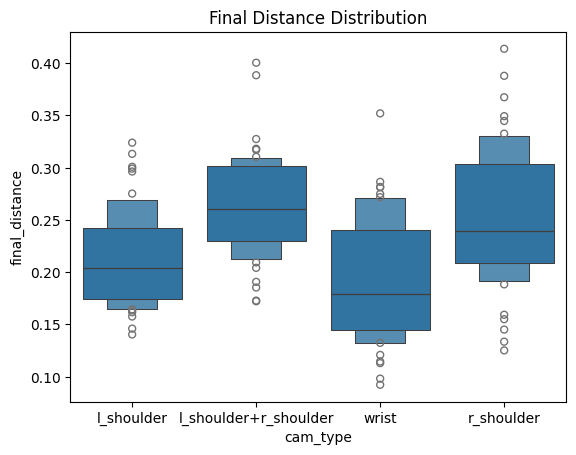

In [36]:
## setting_rep indicates a a policy 

per_train = df.groupby(["setting_rep", "cam_type", "demo_count", "mb_size"])

## This alows us to take averages of one trained policy 
## (trained 5 per setting, and ran 10 trials per policy)
## so the agged is the average of each 10 runs and not each polciy run
per_train_agged = per_train.agg({
  "is_success": "mean",
  "min_distance":  "mean",
  "final_distance": "mean"
}).reset_index()

per_train_agged[
  (per_train_agged["cam_type"] == "wrist") & 
  (per_train_agged["mb_size"] == 512)
]

per_train_agged

sns.boxenplot(data= per_train_agged, x="cam_type", y="final_distance")
plt.title("Final Distance Distribution")

<Figure size 1000x1000 with 0 Axes>

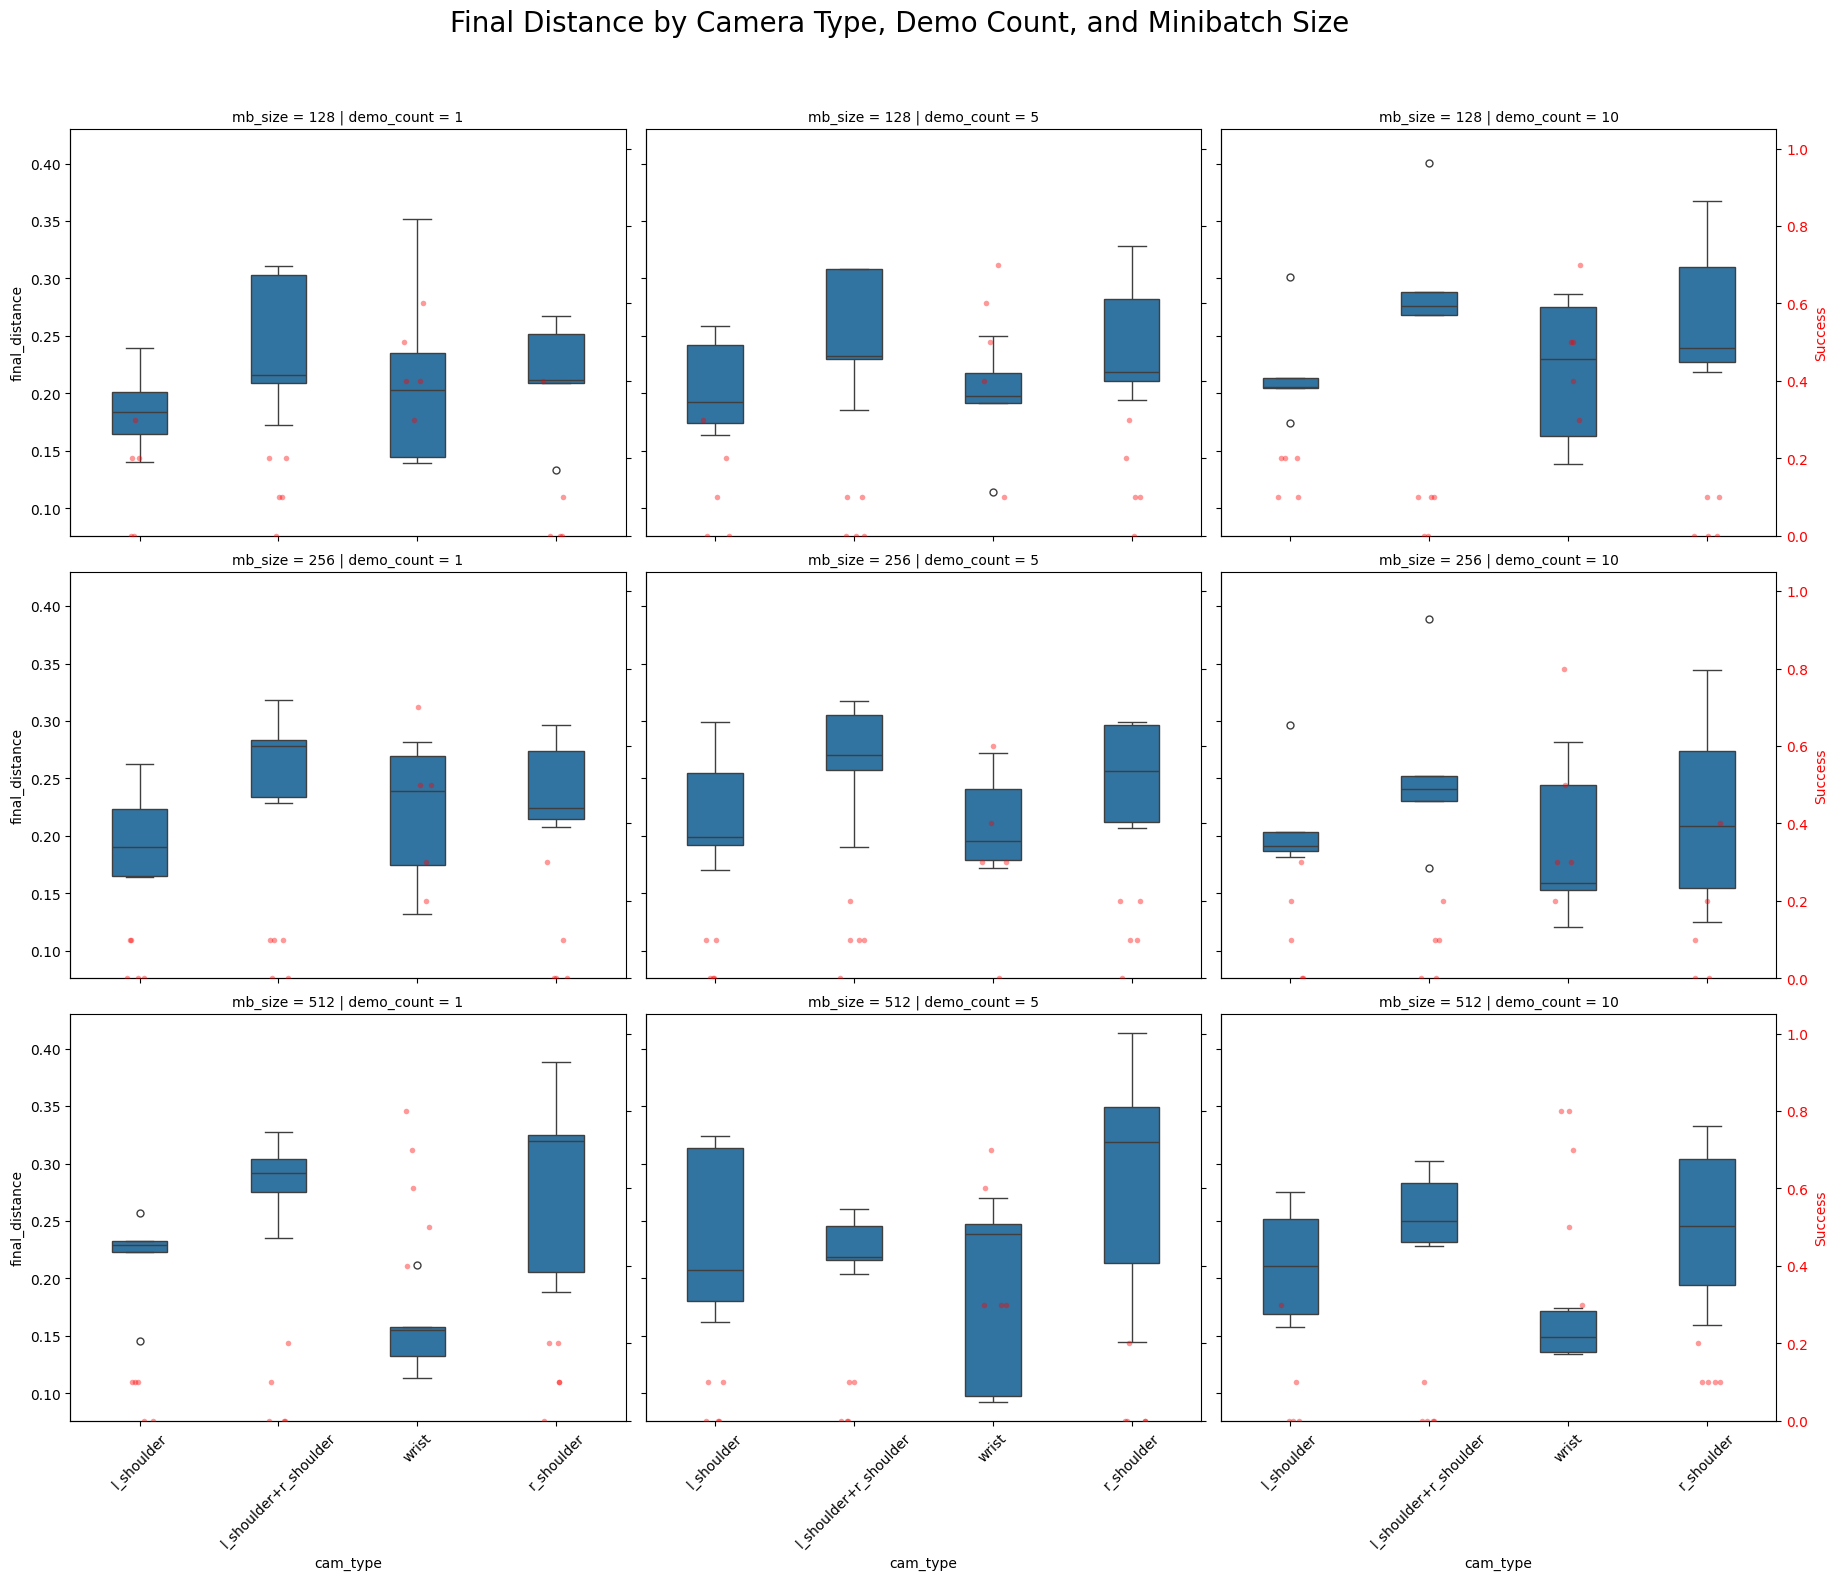

In [37]:
vision_sns_catplot(
  data_df=per_train_agged,
  figsize=(10, 10),
  x_name="cam_type",
  y_name="final_distance",
  col_name="demo_count",
  row_name="mb_size",
  title="Final Distance by Camera Type, Demo Count, and Minibatch Size",
  y_name_side="is_success",
  plot_kwargs = {
    "kind":"box",
    "width" : 0.4,
    "height":5, 
    "aspect":1.2
  },
  plot_side_kwargs={
    "color":"red",
    "alpha":0.4,
    "jitter":True,
    "dodge":True,
    "size":4
  }
)



above graph shows the ditribution of the average final distances per trained policy across 5 repeats, the red dots are the ditribution of the success rate of the combination of settings etc.

so we are looking for the tightest boxplot, that is lower on the graph, that has the largest and less spread apart success values

First glance 'wrist' seems to be good, but which one is the best

In [41]:
per_setting = per_train_agged.groupby([
  "cam_type", "demo_count", "mb_size"
])

per_setting_agged = per_setting.agg({
  "is_success": "mean", 
  "min_distance": "mean", 
  "final_distance": "mean"
}).reset_index()

Text(0.5, 0.98, 'Mean Final Distance by Camera Type, Demo Count, and Minibatch Size')

<Figure size 1000x1000 with 0 Axes>

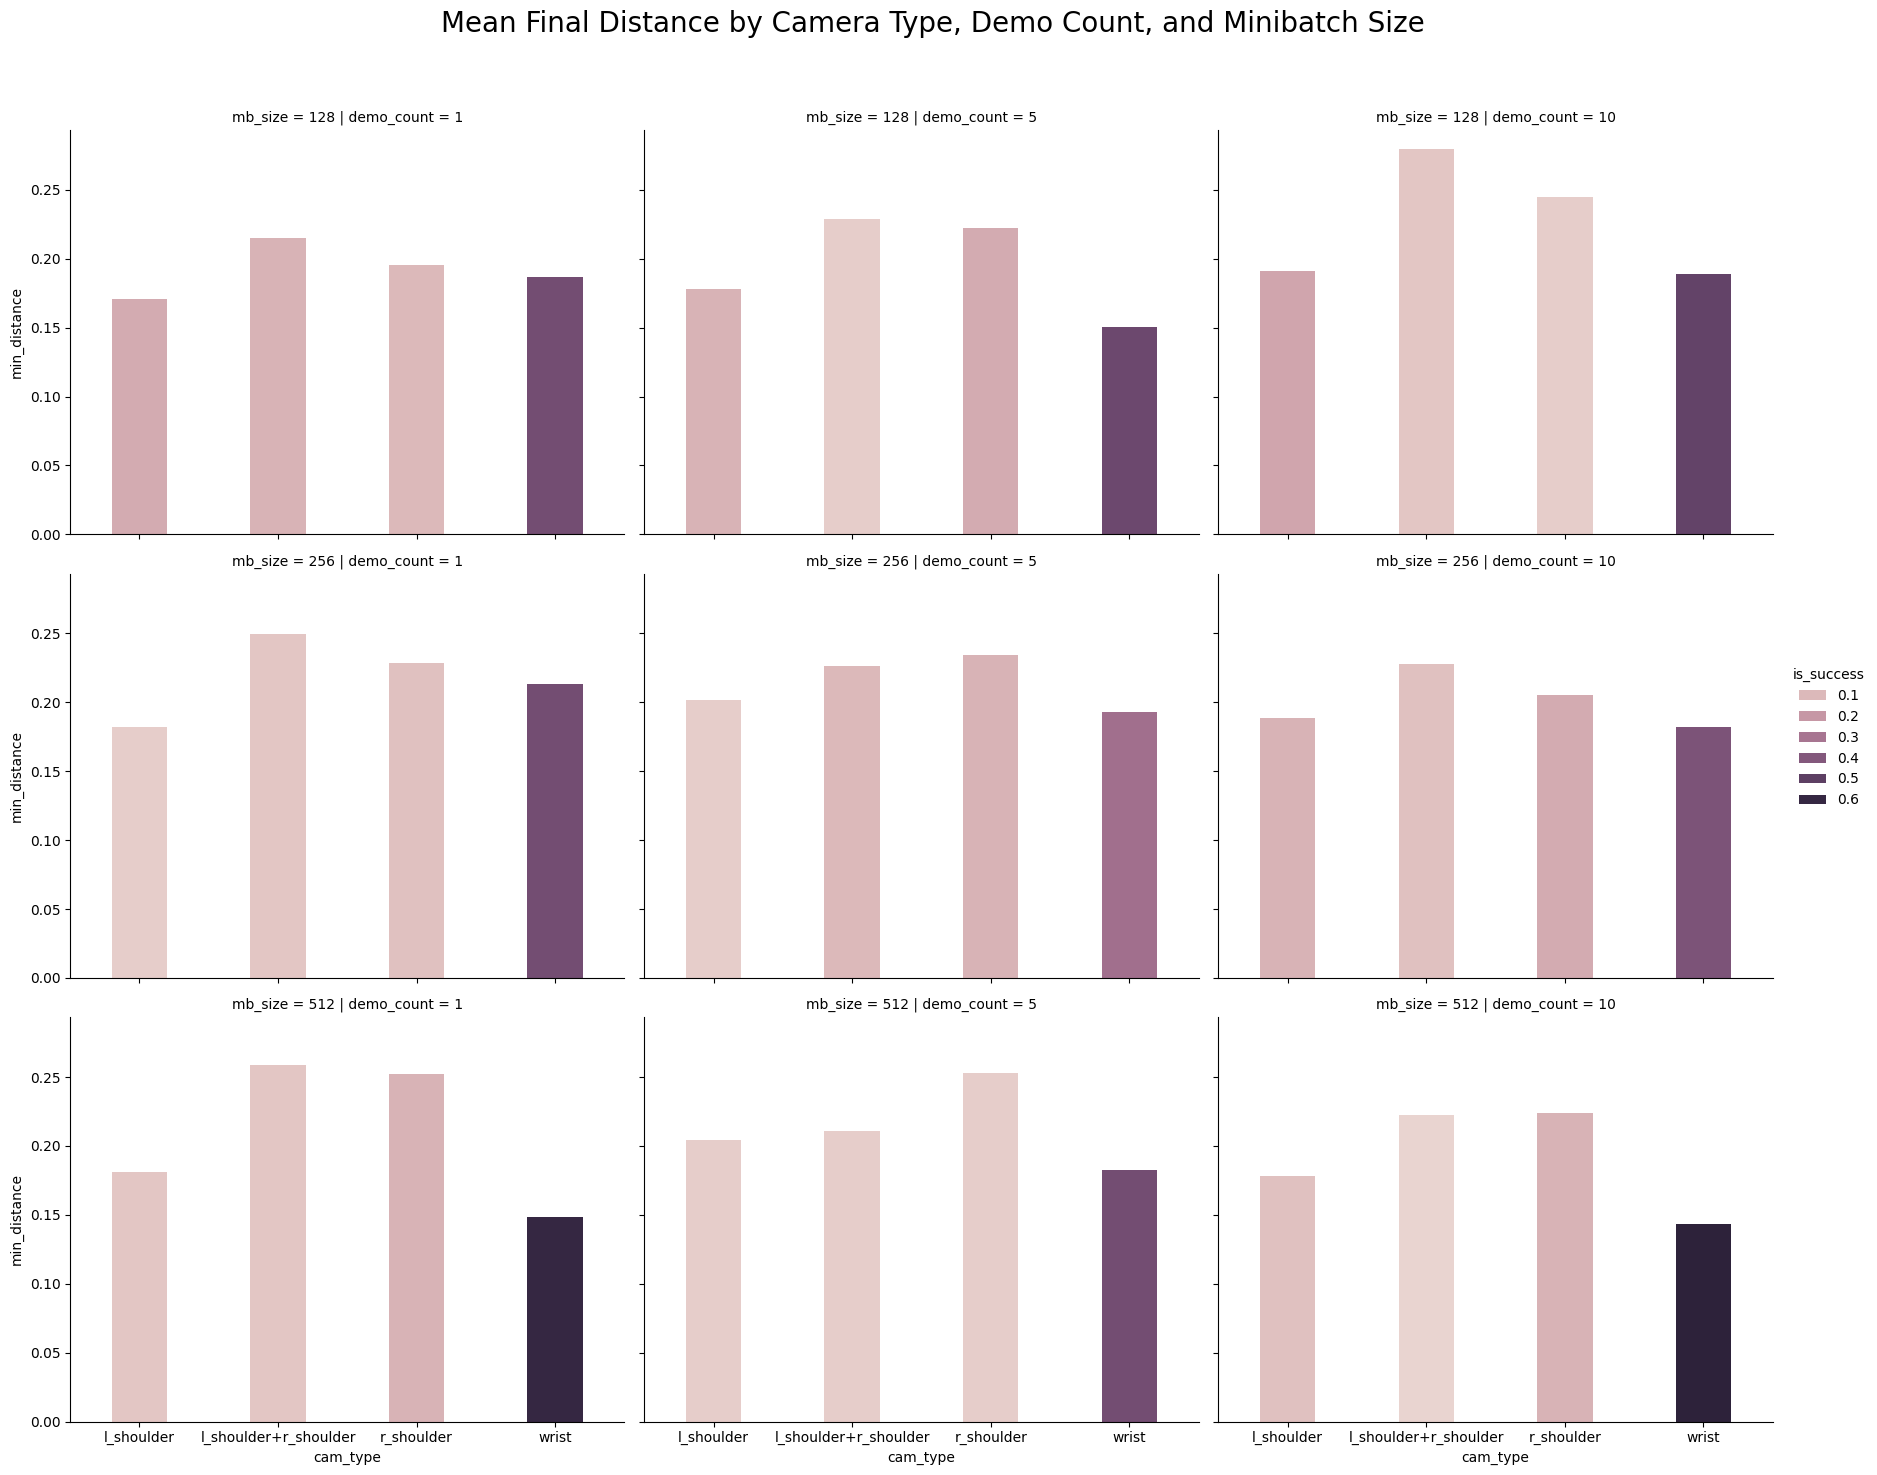

In [40]:


plt.figure(figsize=(10, 10))
g = sns.catplot(
    data=per_setting_agged,
    x="cam_type",
    y="final_distance",
    hue = "is_success",
    col="demo_count",
    row="mb_size",
    kind="bar",
    width = 0.4,
    height=5, 
    aspect=1.2
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Mean Final Distance by Camera Type, Demo Count, and Minibatch Size", size = 20)



plotting the full data, shows us that 'wrist' is better at generalising and mb_size = 512 seems to be the right spot?

I dont see why more mb_size si helping? isn't it just seeing more of the dataset, will try with smaller numbers

demo lengths are around 60 - 100  depending the location of the target, maybe try with max demo length?

512 and 128 seems to work well, 512 splits dataset usually 1:1 for 2 loops per epoch, and 128 for around 7 iterations.

this means that the system benefits from seeing more demos at once

#### Trying with dynamic sizes
Running batch size equal to the max episode length in the demonstrations given $98$ in this case.

And the average which was $78$

In [42]:
df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results--dynamic-len.csv")

In [43]:
## setting_rep indicates a a policy 

per_train = df.groupby(["setting_rep", "cam_type", "demo_count", "mb_size"])

## This alows us to take averages of one trained policy 
## (trained 5 per setting, and ran 10 trials per policy)
## so the agged is the average of each 10 runs and not each polciy run
per_train_agged = per_train.agg({
  "is_success": "mean",
  "min_distance":  "mean",
  "final_distance": "mean"
}).reset_index()

per_train_agged[
  (per_train_agged["cam_type"] == "wrist") & 
  (per_train_agged["mb_size"] == 512)
]


,setting_rep,cam_type,demo_count,mb_size,is_success,min_distance,final_distance


In [45]:
per_setting = per_train_agged.groupby([
  "cam_type", "demo_count", "mb_size"
])

per_setting_agged = per_setting.agg({
  "is_success": "mean", 
  "min_distance": "mean", 
  "final_distance": "mean"
}).reset_index()

<Figure size 1000x1000 with 0 Axes>

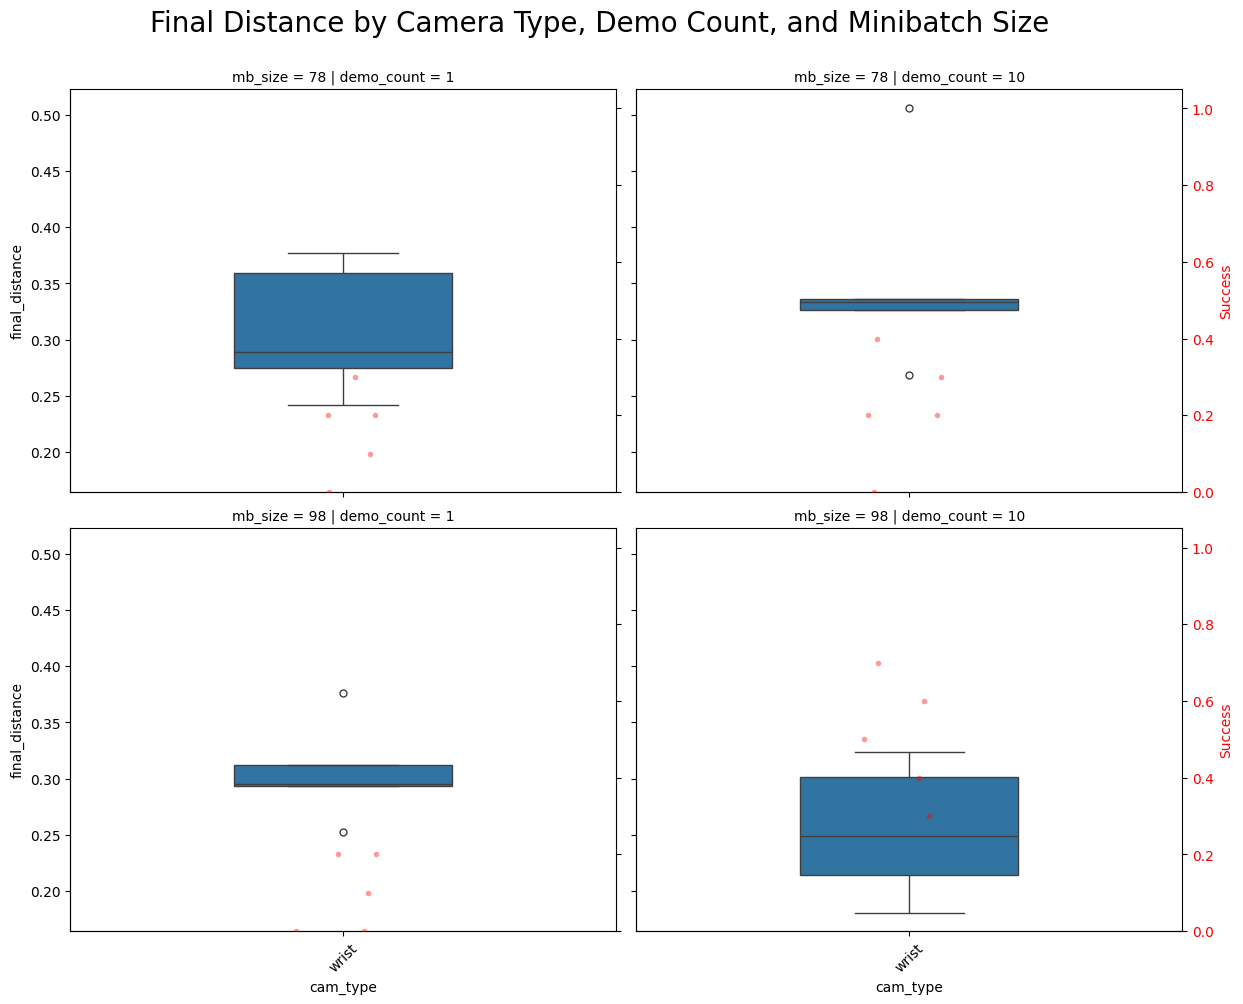

In [24]:
vision_sns_catplot(
  data_df=per_train_agged,
  figsize=(10, 10),
  x_name="cam_type",
  y_name="final_distance",
  col_name="demo_count",
  row_name="mb_size",
  title="Final Distance by Camera Type, Demo Count, and Minibatch Size",
  y_name_side="is_success",
  plot_kwargs = {
    "kind":"box",
    "width" : 0.4,
    "height":5, 
    "aspect":1.2
  },
  plot_side_kwargs={
    "color":"red",
    "alpha":0.4,
    "jitter":True,
    "dodge":True,
    "size":4
  }
)



Text(0.5, 0.98, 'Mean Final Distance by Camera Type, Demo Count, and Minibatch Size')

<Figure size 1000x1000 with 0 Axes>

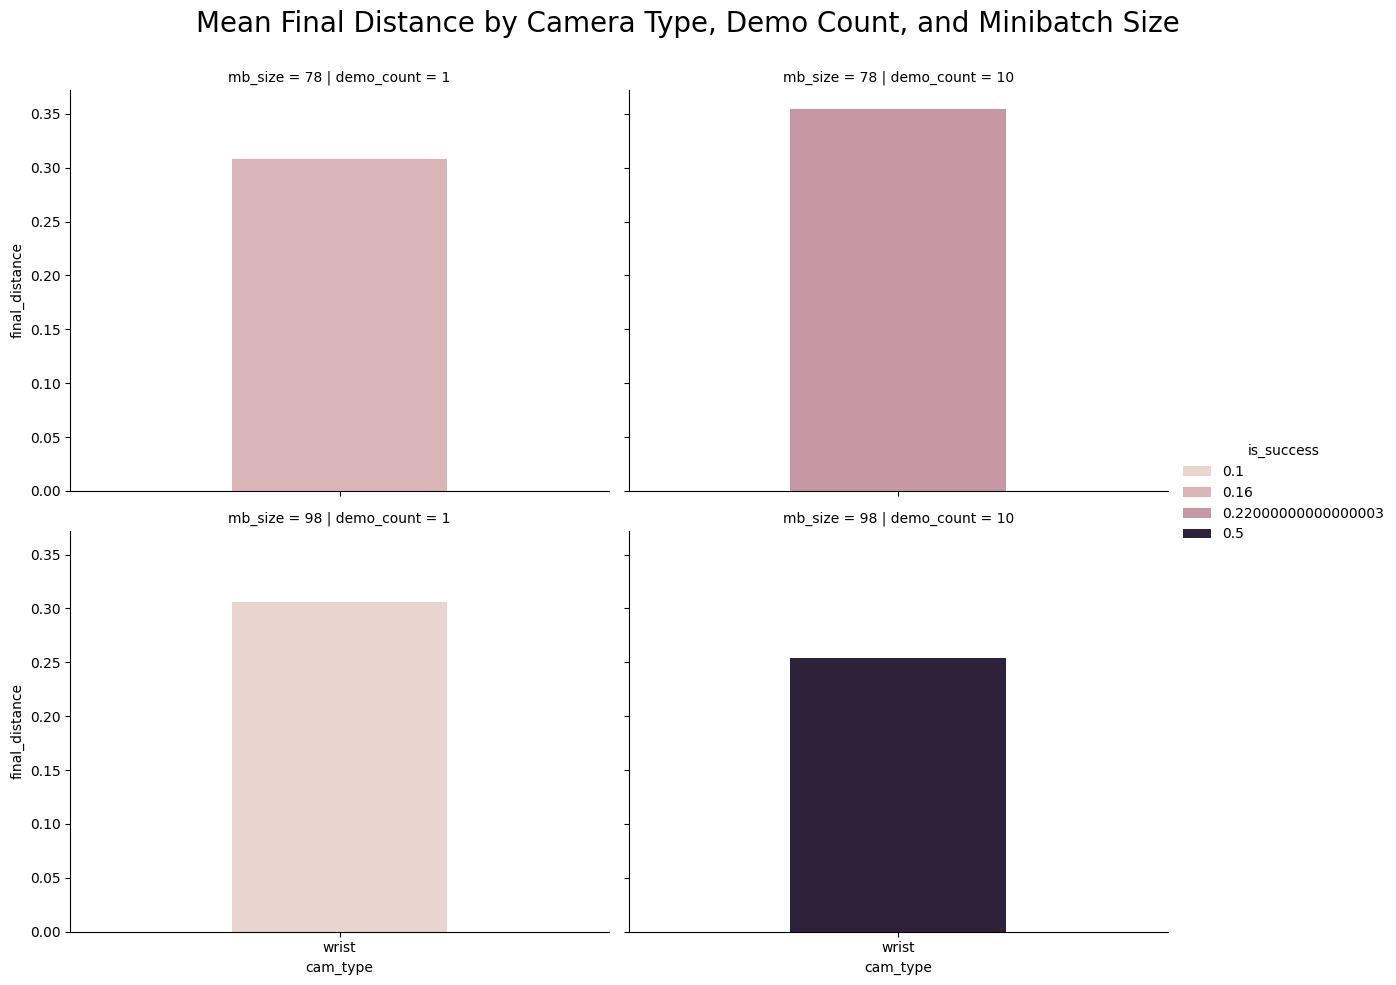

In [46]:
plt.figure(figsize=(10, 10))
g = sns.catplot(
    data=per_setting_agged,
    x="cam_type",
    y="final_distance",
    hue = "is_success",
    col="demo_count",
    row="mb_size",
    kind="bar",
    width = 0.4,
    height=5, 
    aspect=1.2
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Mean Final Distance by Camera Type, Demo Count, and Minibatch Size", size = 20)


<Figure size 1000x1000 with 0 Axes>

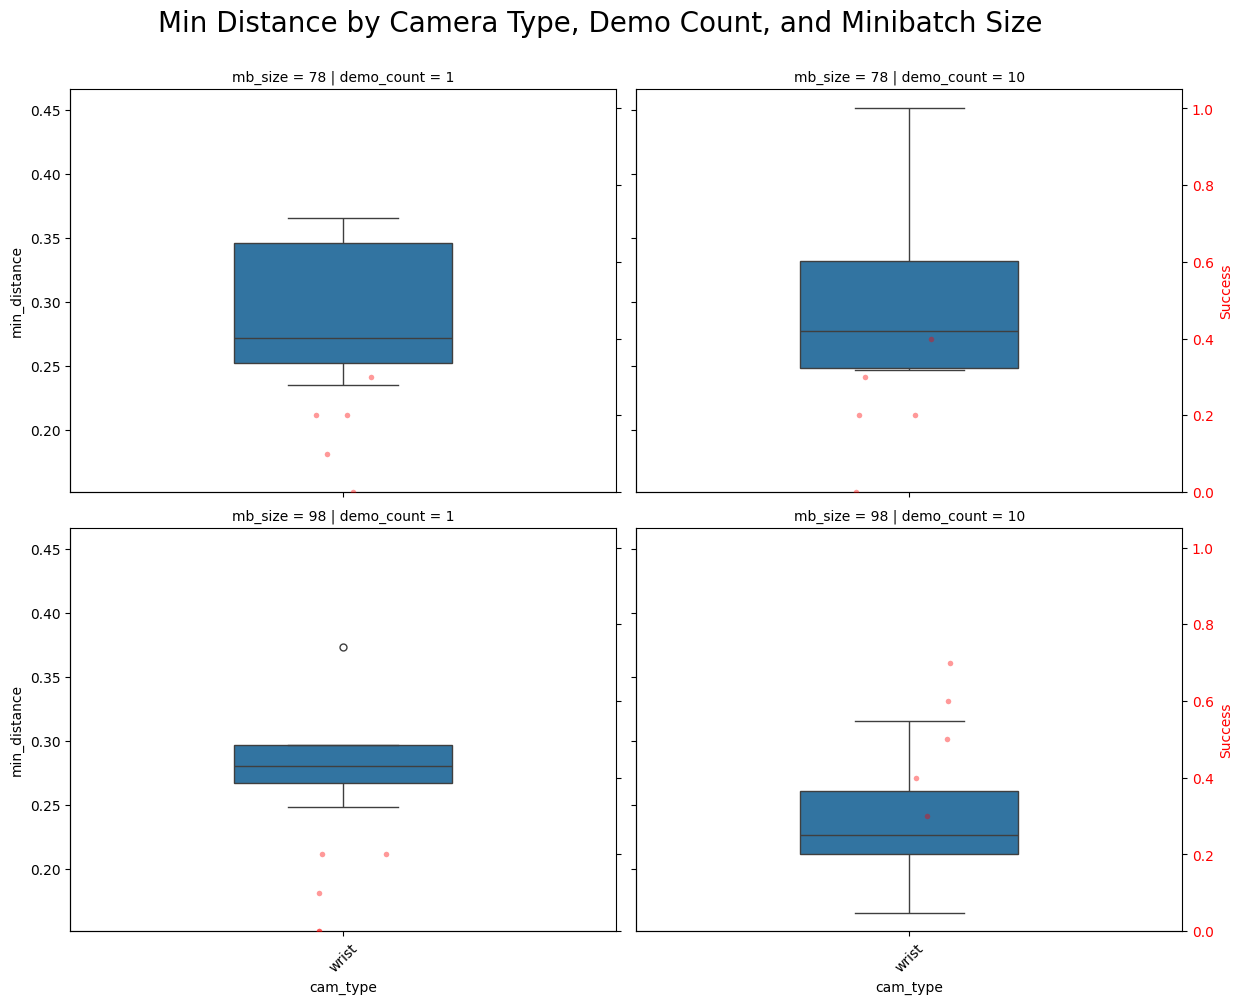

In [26]:
vision_sns_catplot(
  data_df=per_train_agged,
  figsize=(10, 10),
  x_name="cam_type",
  y_name="min_distance",
  col_name="demo_count",
  row_name="mb_size",
  title="Min Distance by Camera Type, Demo Count, and Minibatch Size",
  y_name_side="is_success",
  plot_kwargs = {
    "kind":"box",
    "width" : 0.4,
    "height":5, 
    "aspect":1.2
  },
  plot_side_kwargs={
    "color":"red",
    "alpha":0.4,
    "jitter":True,
    "dodge":True,
    "size":4
  }
)



longer sequence length here also performs well, however the success seems to be very non-deterministic, we can get the policy to be successful from ~70% of the time all the way down to ~30%, which is dependent on the selected sequences of observations within the dataset, another possibility we can try is to run all the observations within the training, so the agent trains on the entire demo in one go. One consideration with this is that the robot might be more sensitive to out of distribution positions because training the entire length of the demos for really long epochs will strongly couple it to what it has seen

Not working well, might just be the demo distribution but it is clear that 100 + seq. len is good for this architecture

### Trying to train with entire demos, rather than randomly sampled sequence of observations 

sequence is as recorded (`shuffle_data = False`) meaning the selected random sequence we are trained on is continuous however longer lengths like 128+ will include multiple obs sequences as it can stretch over 2+ demos

Now I want to try and train this policy with entire demonstrations, and see results.

What the 512 batchsize means is that with the average demo length being around 70-80, the model performs well when it sees almost the entirety of the dataset in one epoch

In [27]:
df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results--demo_dataset.csv")

In [31]:
per_train = df.groupby(["setting_rep",
 "cam_type",
 "demo_count",
 "epochs"
])

## This alows us to take averages of one trained policy 
## (trained 5 per setting, and ran 10 trials per policy)
## so the agged is the average of each 10 runs and not each polciy run
per_train_agged = per_train.agg({
  "is_success": "mean",
  "min_distance":  "mean",
  "final_distance": "mean"
}).reset_index()


<Figure size 1000x1000 with 0 Axes>

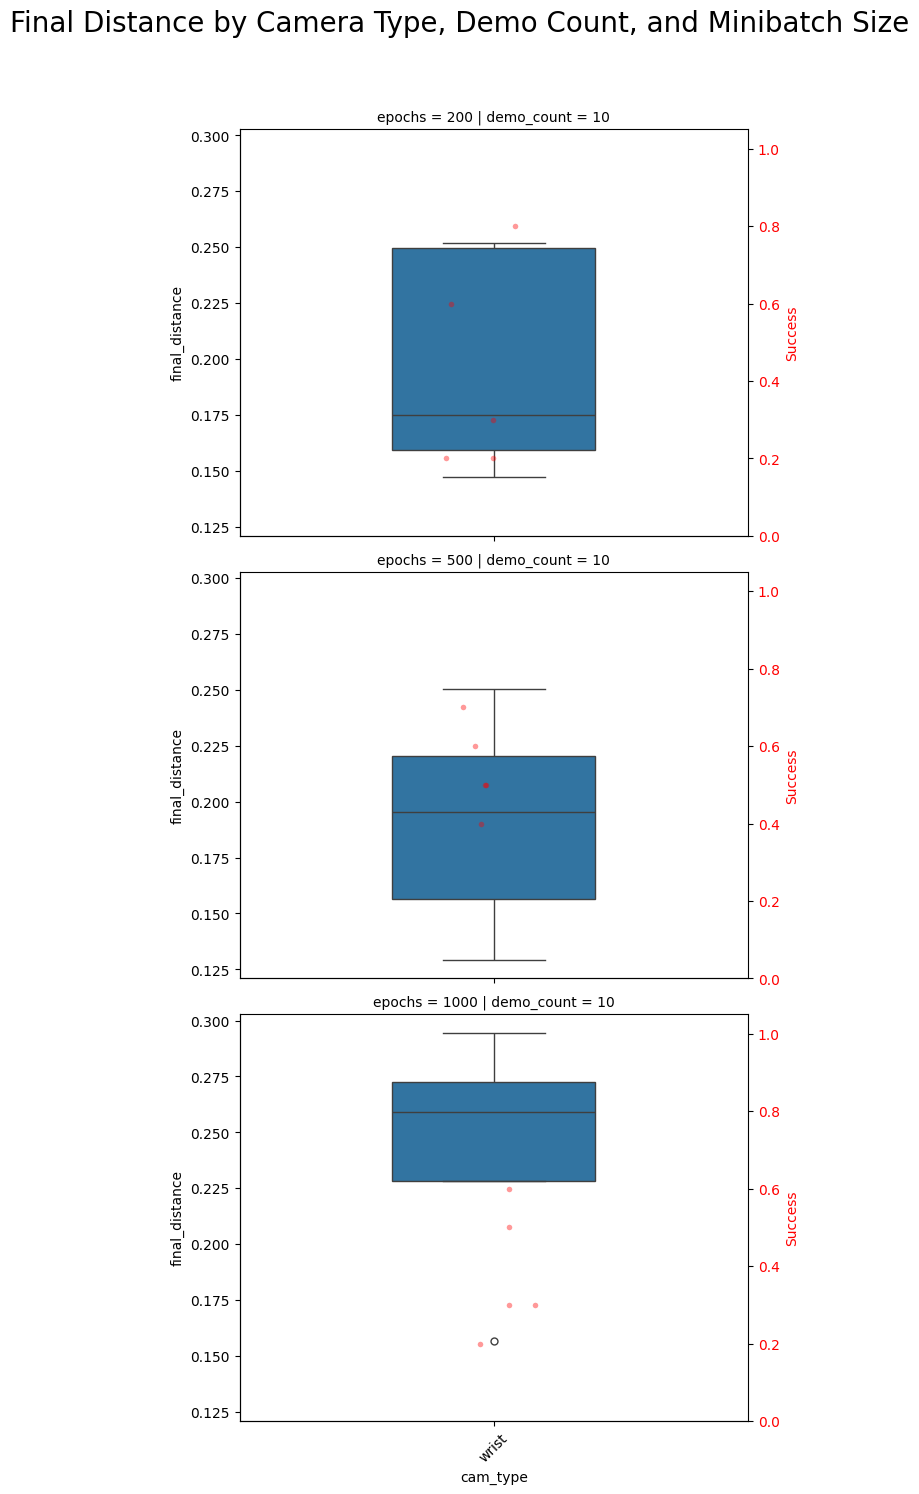

In [32]:
vision_sns_catplot(
  data_df=per_train_agged,
  figsize=(10, 10),
  x_name="cam_type",
  y_name="final_distance",
  col_name="demo_count",
  row_name="epochs",
  title="Final Distance by Camera Type, Demo Count, and Minibatch Size",
  y_name_side="is_success",
  plot_kwargs = {
    "kind":"box",
    "width" : 0.4,
    "height":5, 
    "aspect":1.2
  },
  plot_side_kwargs={
    "color":"red",
    "alpha":0.4,
    "jitter":True,
    "dodge":True,
    "size":4
  }
)



<Figure size 1000x1000 with 0 Axes>

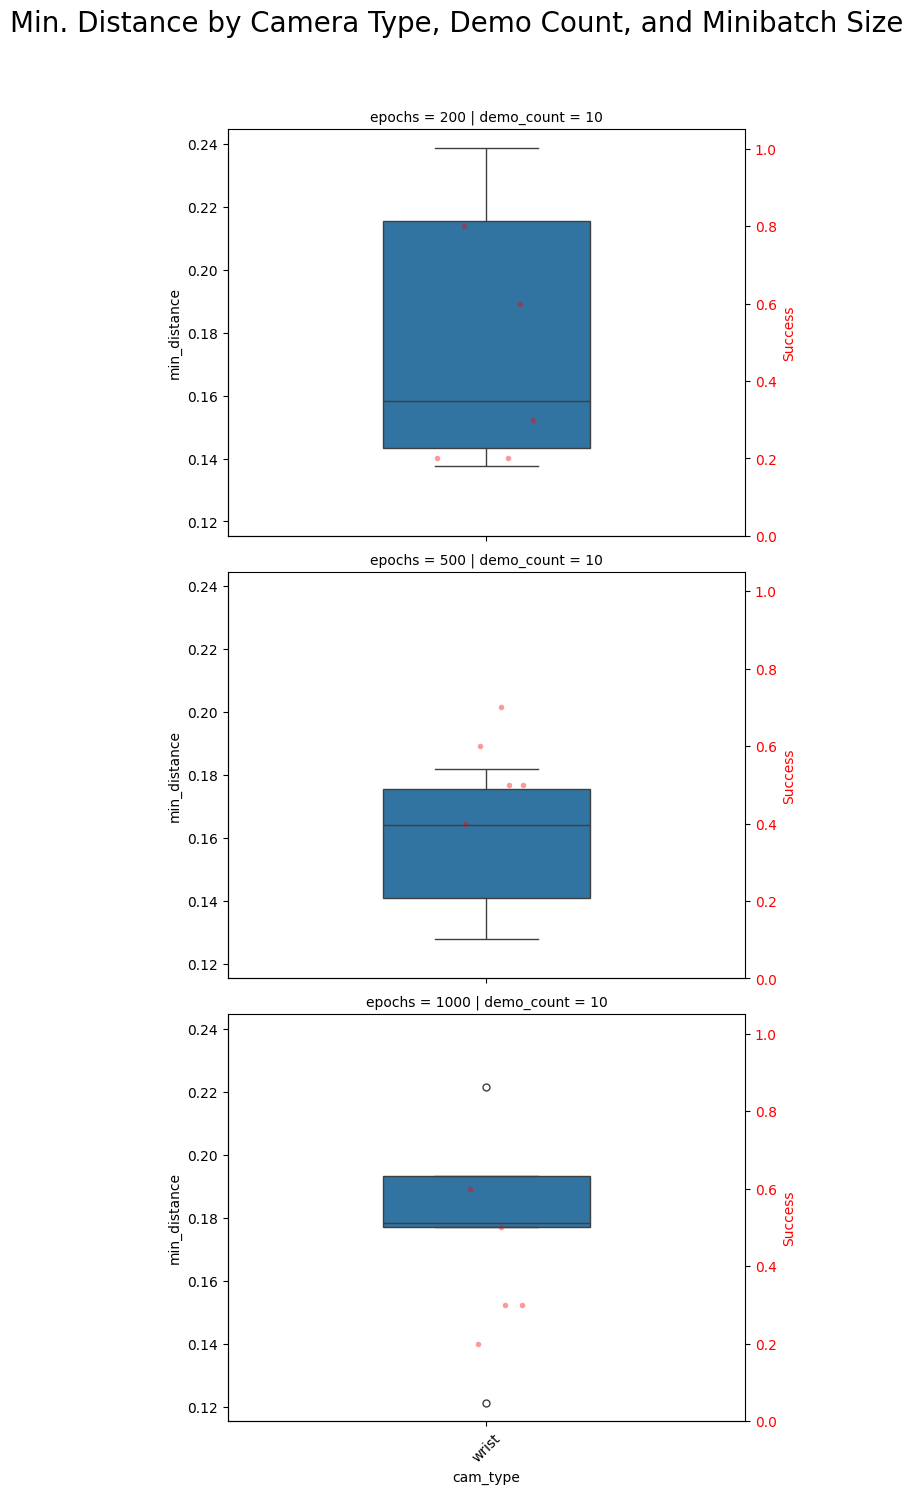

In [33]:
vision_sns_catplot(
  data_df=per_train_agged,
  figsize=(10, 10),
  x_name="cam_type",
  y_name="min_distance",
  col_name="demo_count",
  row_name="epochs",
  title="Min. Distance by Camera Type, Demo Count, and Minibatch Size",
  y_name_side="is_success",
  plot_kwargs = {
    "kind":"box",
    "width" : 0.4,
    "height":5, 
    "aspect":1.2
  },
  plot_side_kwargs={
    "color":"red",
    "alpha":0.4,
    "jitter":True,
    "dodge":True,
    "size":4
  }
)



Results here look promising however, distance distribution of the best one here: 200 epochs in 10 demos (wrist), has a lower success rate compared to the most similar which is mb_size 128 (so ingesting around continuous 1.5 to 2 demos) has a better average success rate, this means the unshuffled demos (flattened observations do better)

apparently flattening the dataset helps maintain the IID sampling of my dataset, without an inherent call to shuffle the data, which seems to increase the robustness and generalisabilty of the network somewhata

I think a good middle ground might be to shuffle the demo order but not the obs frame order within each demo, therefore we can beenfit from slightly different stacking of demos, while 

### Shuffling at the Demo level but flattening the observations

as the title says, want to see whether the introduced slight randomness will hlep this

shuffling needs to be done at the loader level for differntly shuffled order every for loop


In [51]:
df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results--demo_dataset-batch_collated.csv")
df["epoch+mb_size"] = "epochs: " + df["epochs"].astype(str) + " | " + "mb_size: " + df["mb_size"].astype(str)

In [54]:
per_train = df.groupby(["setting_rep",
 "cam_type",
 "demo_count",
#  "epochs",
#  "mb_size"
"epoch+mb_size"

])

## This alows us to take averages of one trained policy 
## (trained 5 per setting, and ran 10 trials per policy)
## so the agged is the average of each 10 runs and not each polciy run
per_train_agged = per_train.agg({
  "is_success": "mean",
  "min_distance":  "mean",
  "final_distance": "mean"
}).reset_index()


<Figure size 1000x1000 with 0 Axes>

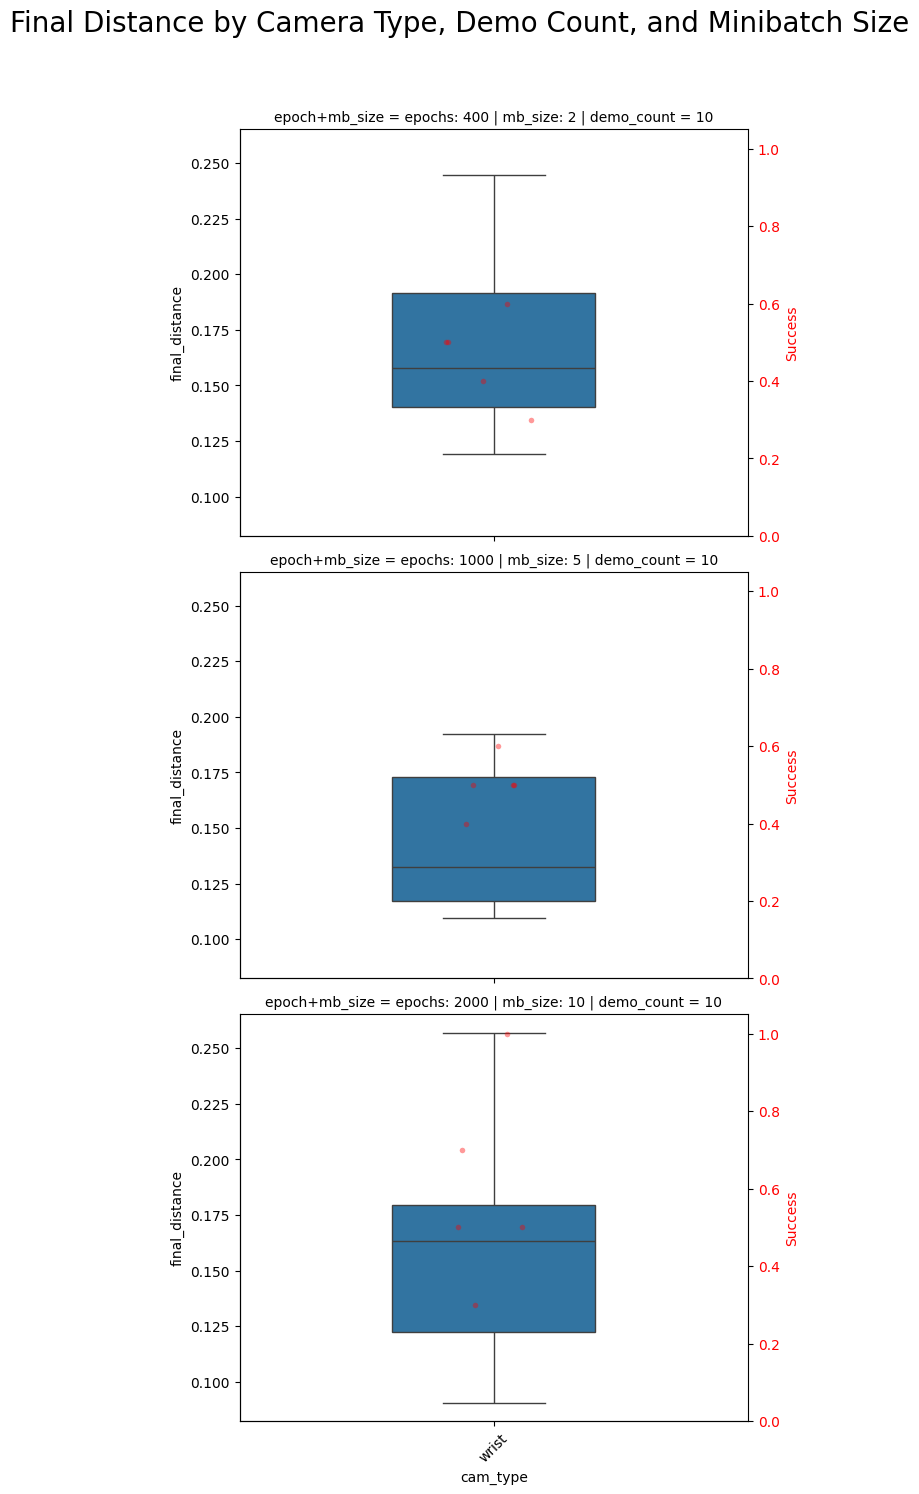

In [55]:
vision_sns_catplot(
  data_df=per_train_agged,
  figsize=(10, 10),
  x_name="cam_type",
  y_name="final_distance",
  col_name="demo_count",
  row_name="epoch+mb_size",
  title="Final Distance by Camera Type, Demo Count, and Minibatch Size",
  y_name_side="is_success",
  plot_kwargs = {
    "kind":"box",
    "width" : 0.4,
    "height":5, 
    "aspect":1.2
  },
  plot_side_kwargs={
    "color":"red",
    "alpha":0.4,
    "jitter":True,
    "dodge":True,
    "size":4
  }
)



seeing all the data randomly shuffled batched together seemed to help the system a lot, thi performed really well, and success around 0.6-0.7 is expected, albeit the randomness worked in favour for this I tihnk, still a good results

So as expected not shuffling the frames allows for some temporal learning while the shuffled demonstrations and random concating of the batch adds to IID, and increases the robustness of the policy. 

The older method is valid as well, this is because the seeing the entire dataset but the sample start and end location being possible in between demos means that the model can learn more?


In [56]:
df = pd.read_csv("run-csvs/vision-exp/hpt-trials/vision_single_random_fixed_size-hpt-results--demo_obs_dataset-entire_batch.csv")
df["epoch+mb_size"] = "epochs: " + df["epochs"].astype(str) + " | " + "mb_size: " + df["mb_size"].astype(str)

In [57]:
per_train = df.groupby(["setting_rep",
 "cam_type",
 "demo_count",
#  "epochs",
#  "mb_size"
"epoch+mb_size"

])

## This alows us to take averages of one trained policy 
## (trained 5 per setting, and ran 10 trials per policy)
## so the agged is the average of each 10 runs and not each polciy run
per_train_agged = per_train.agg({
  "is_success": "mean",
  "min_distance":  "mean",
  "final_distance": "mean"
}).reset_index()


<Figure size 1000x1000 with 0 Axes>

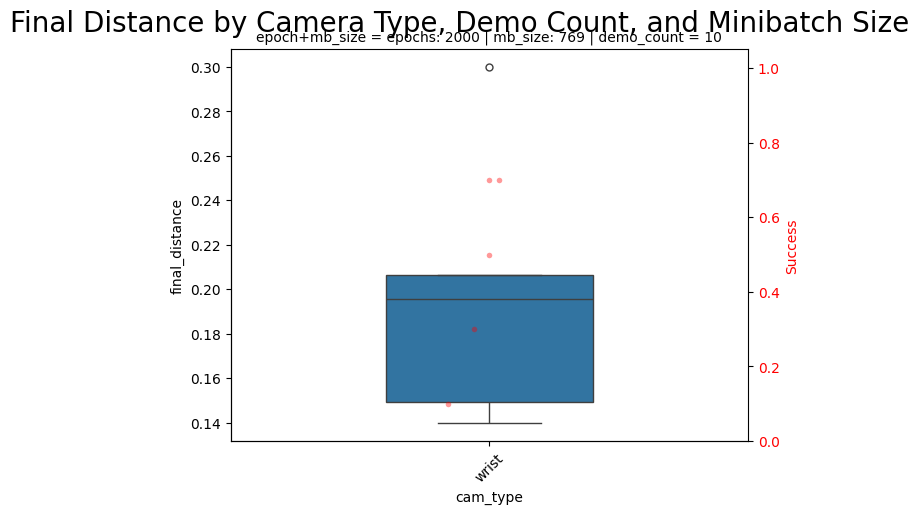

In [58]:
vision_sns_catplot(
  data_df=per_train_agged,
  figsize=(10, 10),
  x_name="cam_type",
  y_name="final_distance",
  col_name="demo_count",
  row_name="epoch+mb_size",
  title="Final Distance by Camera Type, Demo Count, and Minibatch Size",
  y_name_side="is_success",
  plot_kwargs = {
    "kind":"box",
    "width" : 0.4,
    "height":5, 
    "aspect":1.2
  },
  plot_side_kwargs={
    "color":"red",
    "alpha":0.4,
    "jitter":True,
    "dodge":True,
    "size":4
  }
)



However, using the old method doesn't increase success much and the distribution of the distances are slightly more widely distributed. I think this is beacuse every epoch sees entirely the same order of frames, I think this dataset `demo_dataset` works better going forwards


# Depth Interfacing with a Depth camera
I have a few ways of making this work, will start with option 1


## Depth Grasp Policy

### Depth Camera is concatenated onto another channel and convs are shared 

train (control) and the random sets use the same size of object and distance (scale = 1., distance = 0.6)
test set uses (scale = 0.5, distance 0.3) hence half the size double the distance (closer) meaning the camera sees a very similar image


In [71]:
dfs = []
seeds = [
  659, 2511, 2811, 4282, 6287, 6546, 7098, 8800, 9339, 9986
]
for seed in seeds:
  df = pd.read_csv(f"run-csvs/vision-exp/depth-runs/depth_policy-wrist-vs-wrist+wrist_depth-comparison-2000ep-10mbsize-{seed}loaderseed-001lr.csv")
  
  df["agent_type"] = df["agent_name"].apply(lambda ty: "Wrist RGB" if ty == "Agent(policy_type=depth_grasp_policy, cam_type=wrist)" else "Wrist RGB + Depth")
  df["run_seed"] = seed
  dfs.append(df)

all_seeds = pd.concat(dfs, ignore_index=True)


In [76]:
## all success
# Total demos per run/demo_type/agent
total = all_seeds.groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('total')
success = all_seeds[all_seeds['is_success'] == True]\
    .groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('success')

# Merge and compute percentage
success_df = pd.merge(total, success, left_index=True, right_index=True, how='left')
success_df['success'] = success_df['success'].fillna(0)
success_df['success_pct'] = 100 * success_df['success'] / success_df['total']
success_df = success_df.reset_index()


Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per Run)')

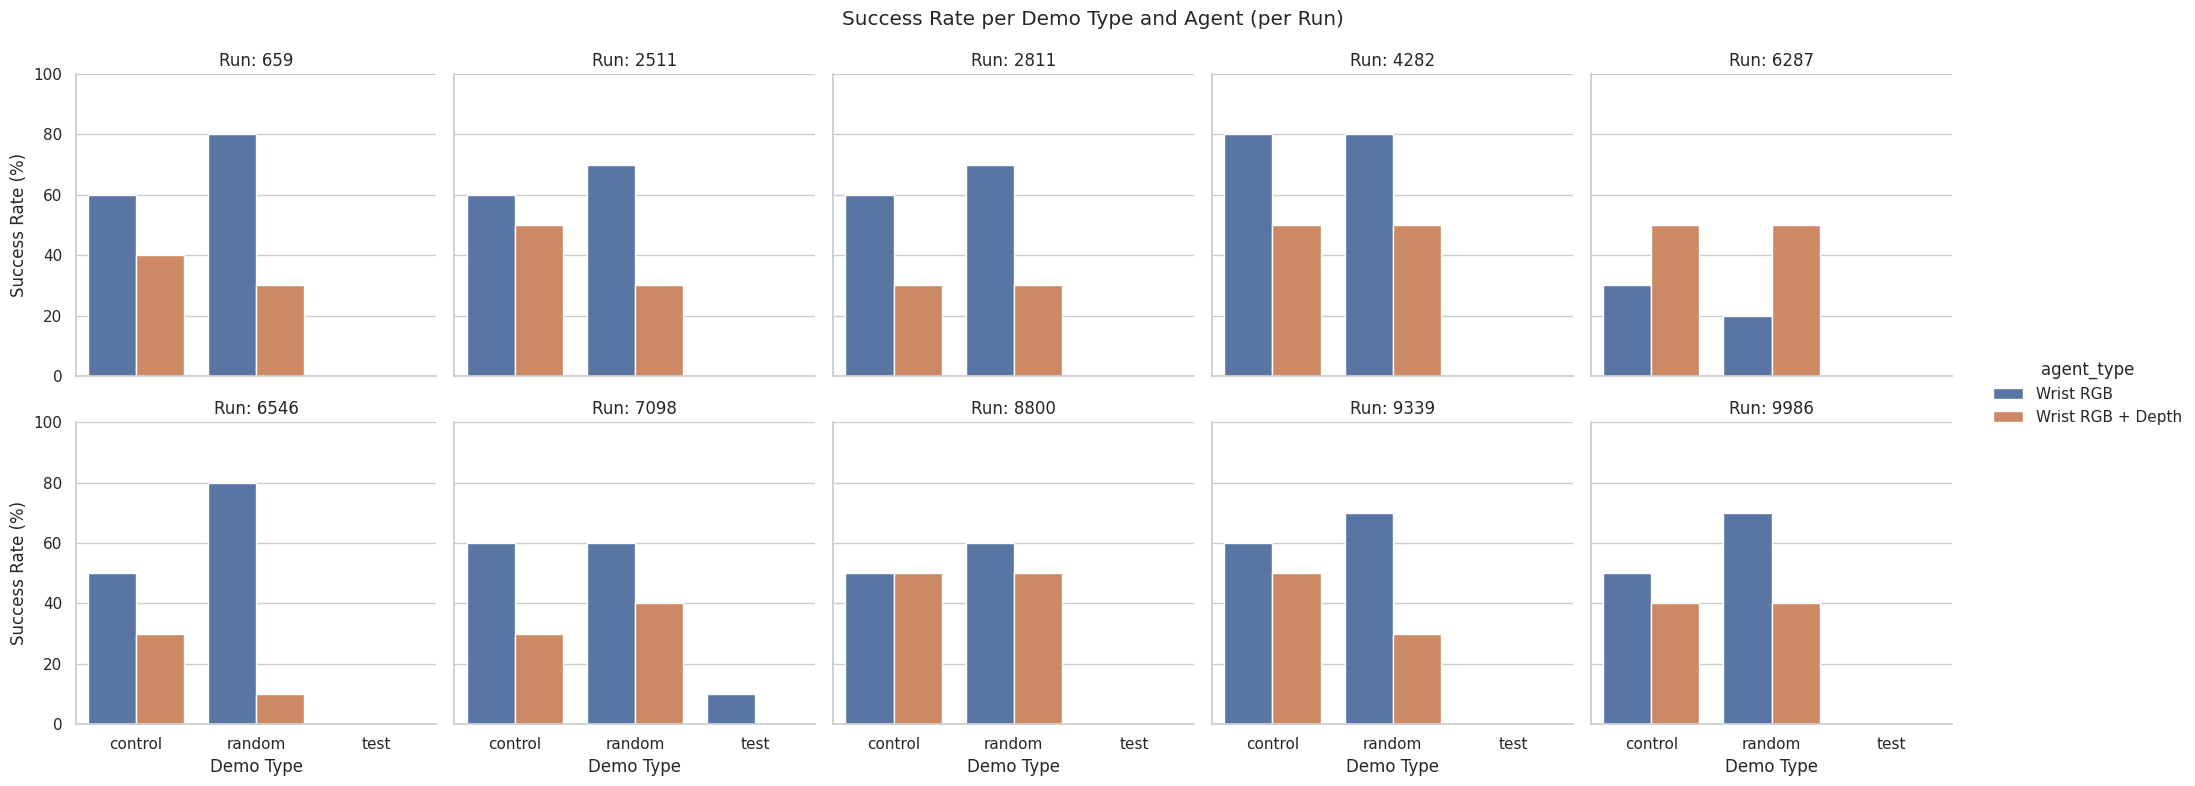

In [ ]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=success_df,
    x='demo_type',
    y='success_pct',
    hue='agent_type',
    col='run_seed',
    kind='bar',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Success Rate (%)")
g.set(ylim=(0, 100))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")

In [ ]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='agent_type',
    col='run_seed',
    kind='box',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Final Distance")
g.tight_layout()
g.fig.suptitle("Final Distance per Demo Type and Agent (per seeded Run)")


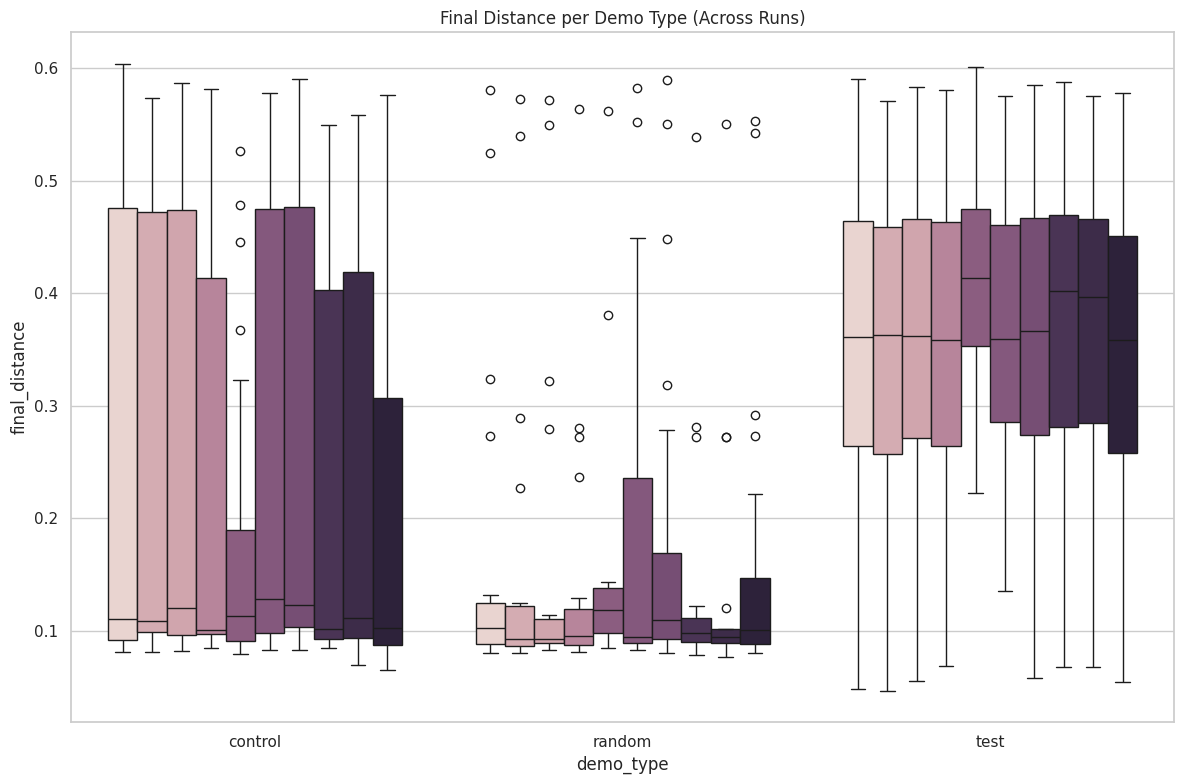

In [84]:
plt.figure(figsize = (12, 8))
sns.boxplot(
    data=all_seeds,
    x='demo_type',
    y='final_distance',
    hue='run_seed',
    legend=False ## just seeds, dont show
)
plt.title('Final Distance per Demo Type (Across Runs)')
plt.tight_layout()
plt.show()

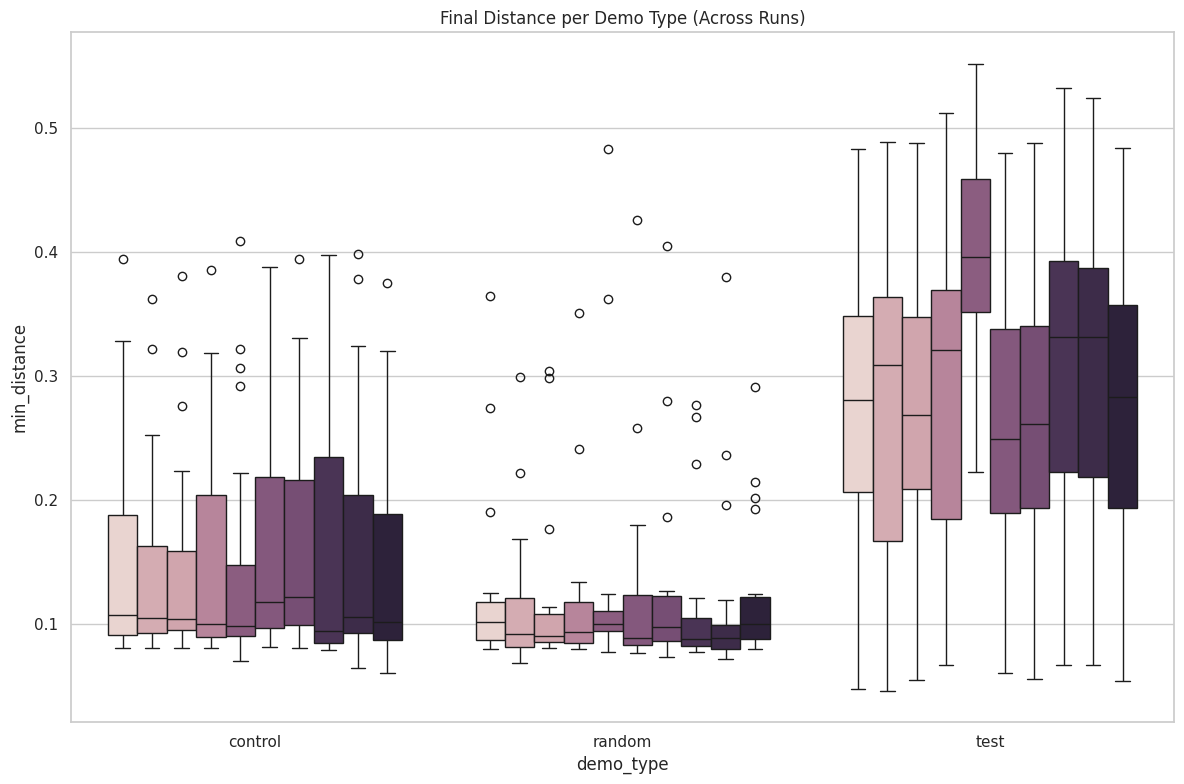

In [85]:
plt.figure(figsize = (12, 8))
sns.boxplot(
    data=all_seeds,
    x='demo_type',
    y='min_distance',
    hue='run_seed',
    legend=False ## just seeds, dont show
)
plt.title('Final Distance per Demo Type (Across Runs)')
plt.tight_layout()
plt.show()

As seen the first approach of just adding a depth camera firstly makes the system lose focus of what it is doing, and secondly the systemm still doesn't fully understand the distance to the obstacle maybe tweak this accordingly? bring back attention?? but definitely needs to be a learning system (learn a linear fuser) and possibbly make the network deper

### Wrist Depth Camera has own conv
This also has its own gating etc, so there are a few points of comparison here


In [14]:
dfs = []
seeds = [
  854, 1707, 4737, 5172, 5249, 
  5791, 5855, 6528, 7392, 8164

]


for seed in seeds:
  df = pd.read_csv(f"run-csvs/vision-exp/depth-runs/5way-comp/depth_policy-5way-comparison-2000ep-10mbsize-{seed}loaderseed-001lr.csv")
  
  
  df["agent_type"] = df["agent_name"].apply(df_agent_select)
  df["run_seed"] = seed
  dfs.append(df)
all_dfs = pd.concat(dfs, ignore_index=True)

all_dfs

,Unnamed: 0,task_name,agent_name,demo_type,task_params,demo_index,is_success,final_distance,min_distance,max_eplen,gripper_image_paths,agent_type,run_seed
0,0,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 1.0, 'wrist_cam_distance': 0.6}",0,True,0.090301,0.090301,97,['outputs/run-grasp-with-agent/_May17_20-25'],Wrist RGB (depth_ch),854
1,1,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 1.0, 'wrist_cam_distance': 0.6}",1,True,0.096405,0.096405,97,['outputs/run-grasp-with-agent/_May17_20-25'],Wrist RGB (depth_ch),854
2,2,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 1.0, 'wrist_cam_distance': 0.6}",2,False,0.106076,0.087047,97,[],Wrist RGB (depth_ch),854
3,3,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 1.0, 'wrist_cam_distance': 0.6}",3,False,0.314292,0.314292,97,[],Wrist RGB (depth_ch),854
4,4,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 1.0, 'wrist_cam_distance': 0.6}",4,False,0.095873,0.095321,97,[],Wrist RGB (depth_ch),854
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,145,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",5,False,0.486710,0.480745,101,[],Wrist RGB + Depth (depth_feats - gated),8164
1496,146,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",6,False,0.272775,0.272443,101,[],Wrist RGB + Depth (depth_feats - gated),8164
1497,147,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",7,False,0.404508,0.404508,101,[],Wrist RGB + Depth (depth_feats - gated),8164
1498,148,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",8,False,0.435669,0.429395,101,[],Wrist RGB + Depth (depth_feats - gated),8164


In [15]:
## all success
# Total demos per run/demo_type/agent
total = all_dfs.groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('total')
success = all_dfs[all_dfs['is_success'] == True]\
    .groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('success')

# Merge and compute percentage
success_df = pd.merge(total, success, left_index=True, right_index=True, how='left')
success_df['success'] = success_df['success'].fillna(0)
success_df['success_pct'] = 100 * success_df['success'] / success_df['total']
success_df = success_df.reset_index()
success_df

,run_seed,agent_type,demo_type,total,success,success_pct
0,854,L+R Shoulder RGB,control,10,6.0,60.0
1,854,L+R Shoulder RGB,random,10,1.0,10.0
2,854,L+R Shoulder RGB,test,10,0.0,0.0
3,854,Wrist RGB (depth_ch),control,10,4.0,40.0
4,854,Wrist RGB (depth_ch),random,10,5.0,50.0
...,...,...,...,...,...,...
145,8164,Wrist RGB + Depth (depth_feats - gated),random,10,7.0,70.0
146,8164,Wrist RGB + Depth (depth_feats - gated),test,10,0.0,0.0
147,8164,Wrist RGB + Depth (depth_feats - no gate),control,10,0.0,0.0
148,8164,Wrist RGB + Depth (depth_feats - no gate),random,10,0.0,0.0


Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per seeded Run)')

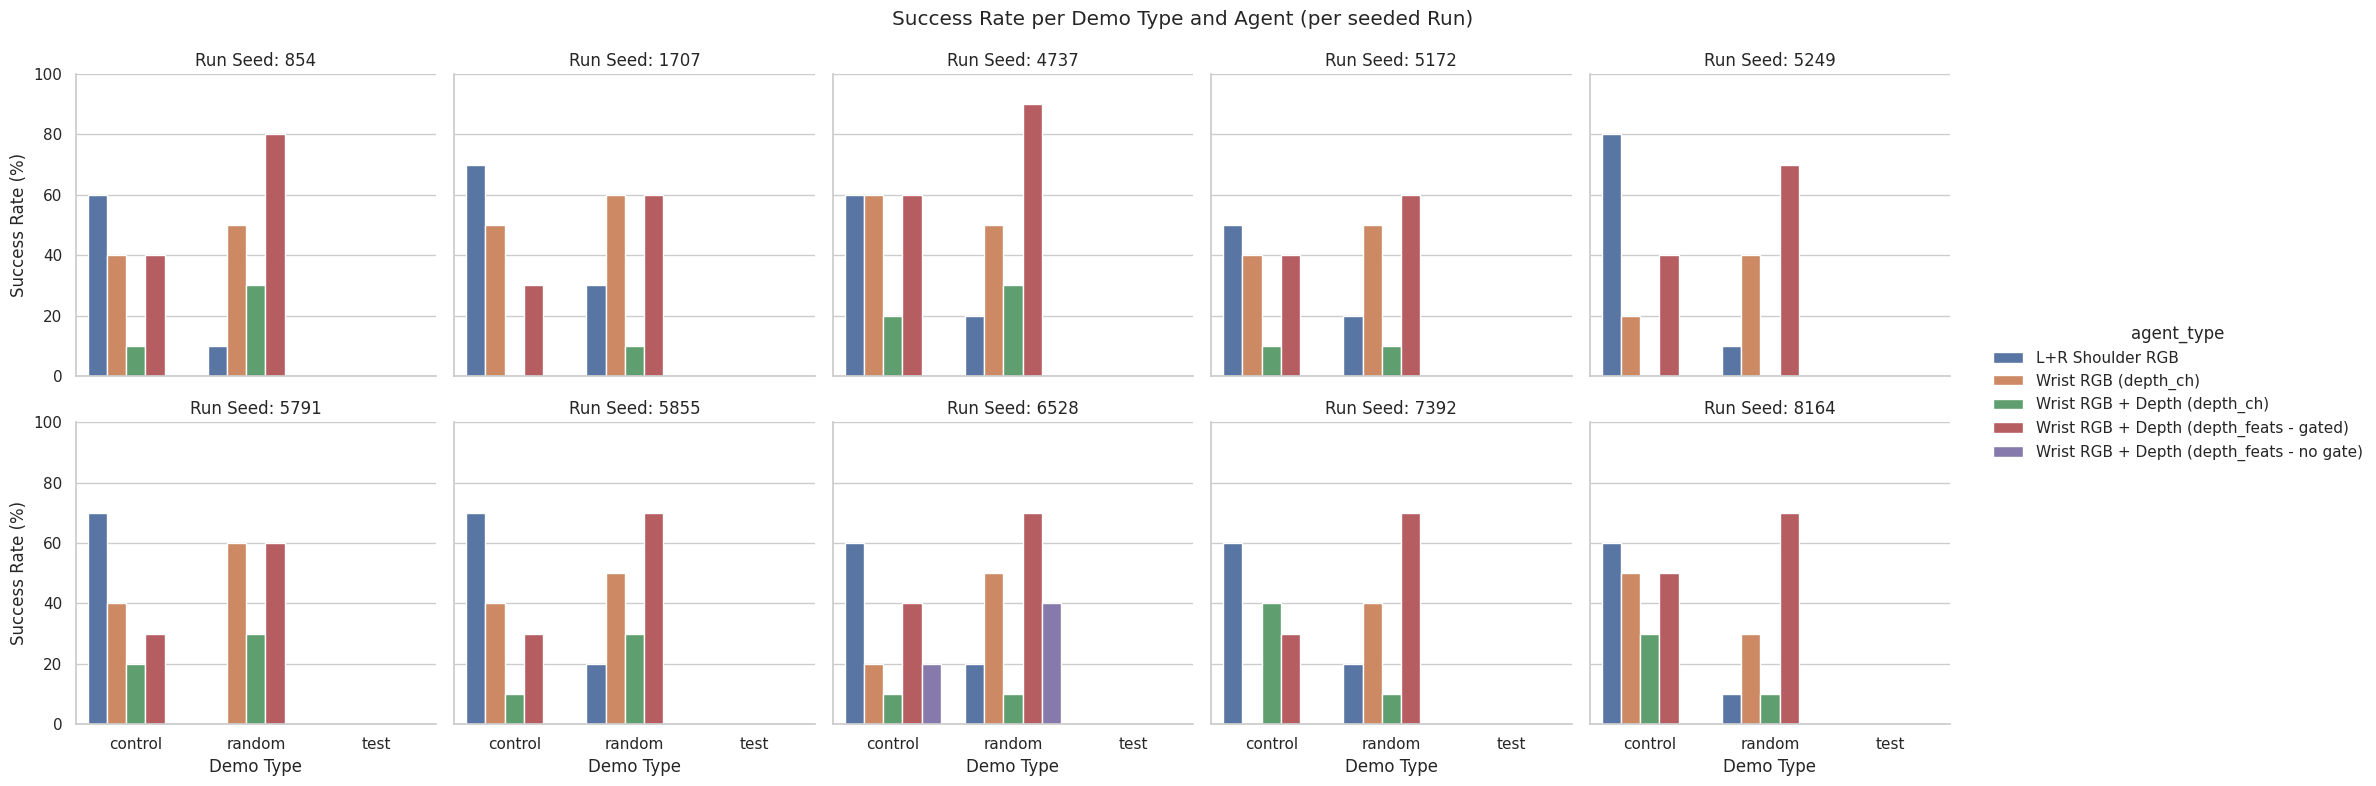

In [16]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=success_df,
    x='demo_type',
    y='success_pct',
    hue='agent_type',
    col='run_seed',
    kind='bar',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Success Rate (%)")
g.set(ylim=(0, 100))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")

Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per Run)')

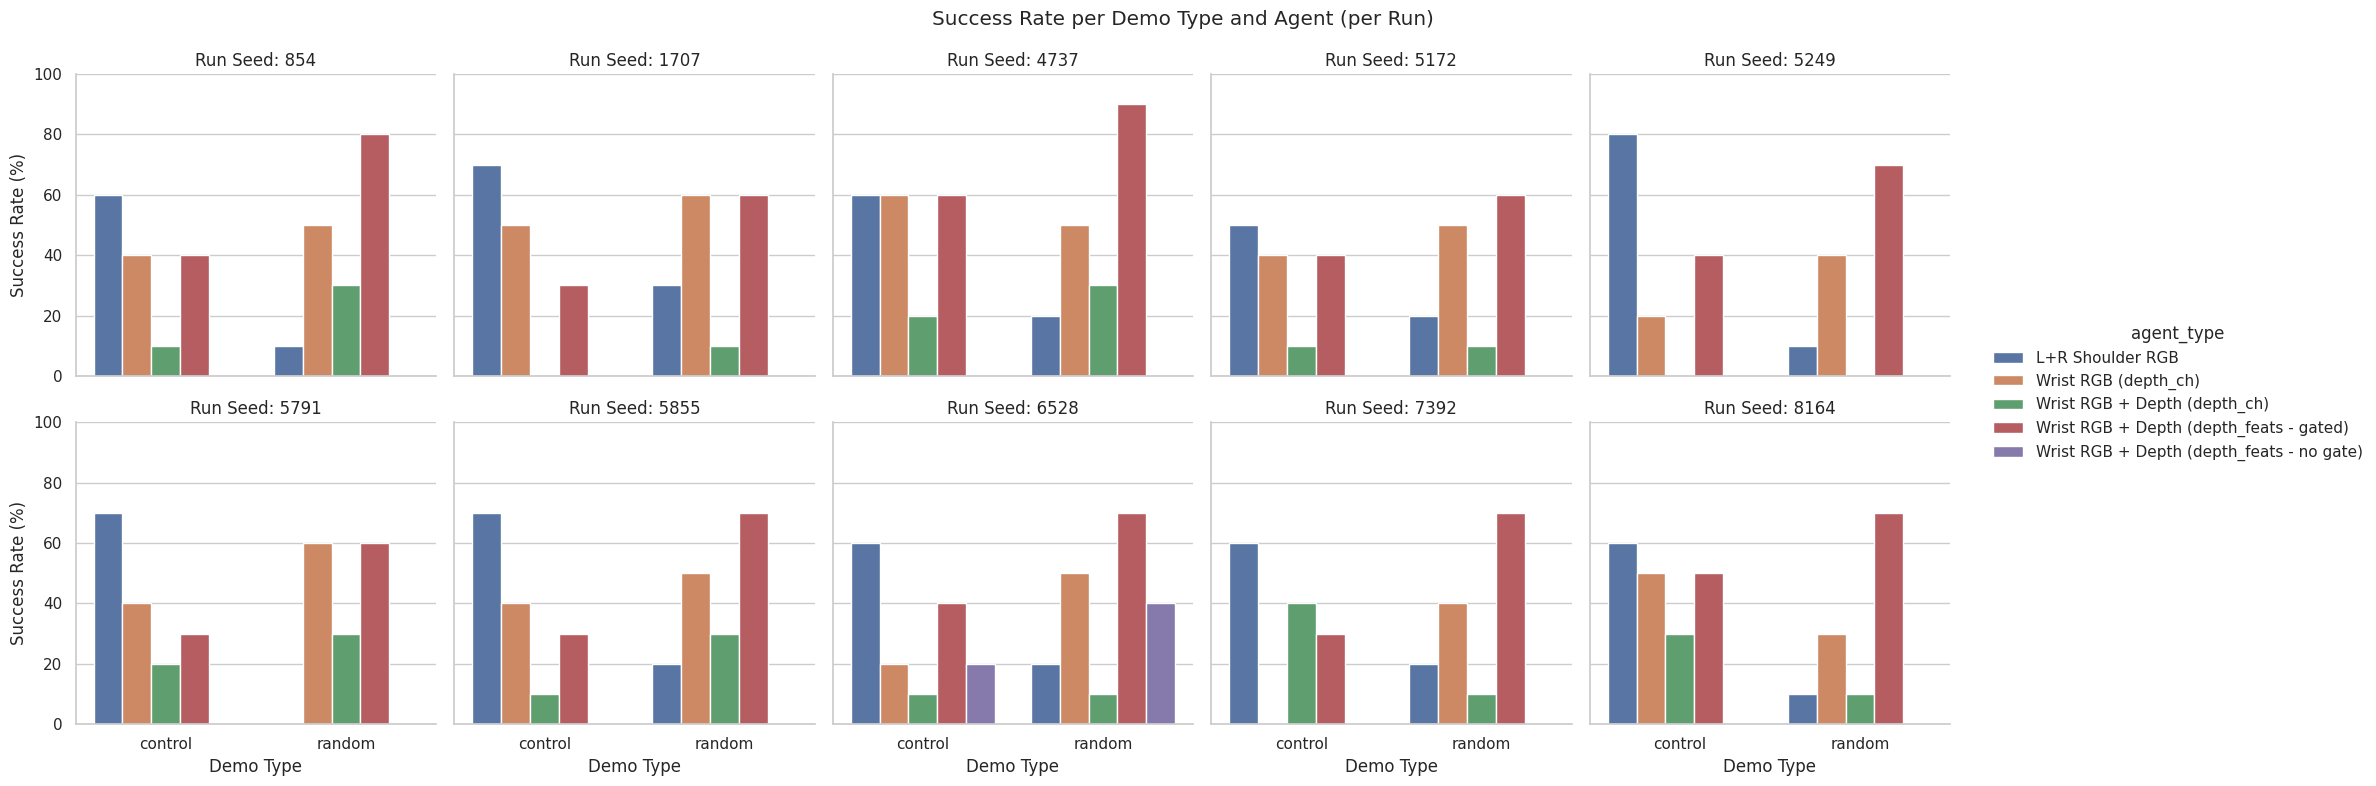

In [ ]:
## same as above but without the test data (because it doensn't do much)

no_test_success_df = success_df[success_df["demo_type"] != "test"]
# Plot
g = sns.catplot(
    data=no_test_success_df,
    x='demo_type',
    y='success_pct',
    hue='agent_type',
    col='run_seed',
    kind='bar',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Success Rate (%)")
g.set(ylim=(0, 100))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")

Text(0.5, 0.98, 'Final Distance per Demo Type and Agent (per seeded Run)')

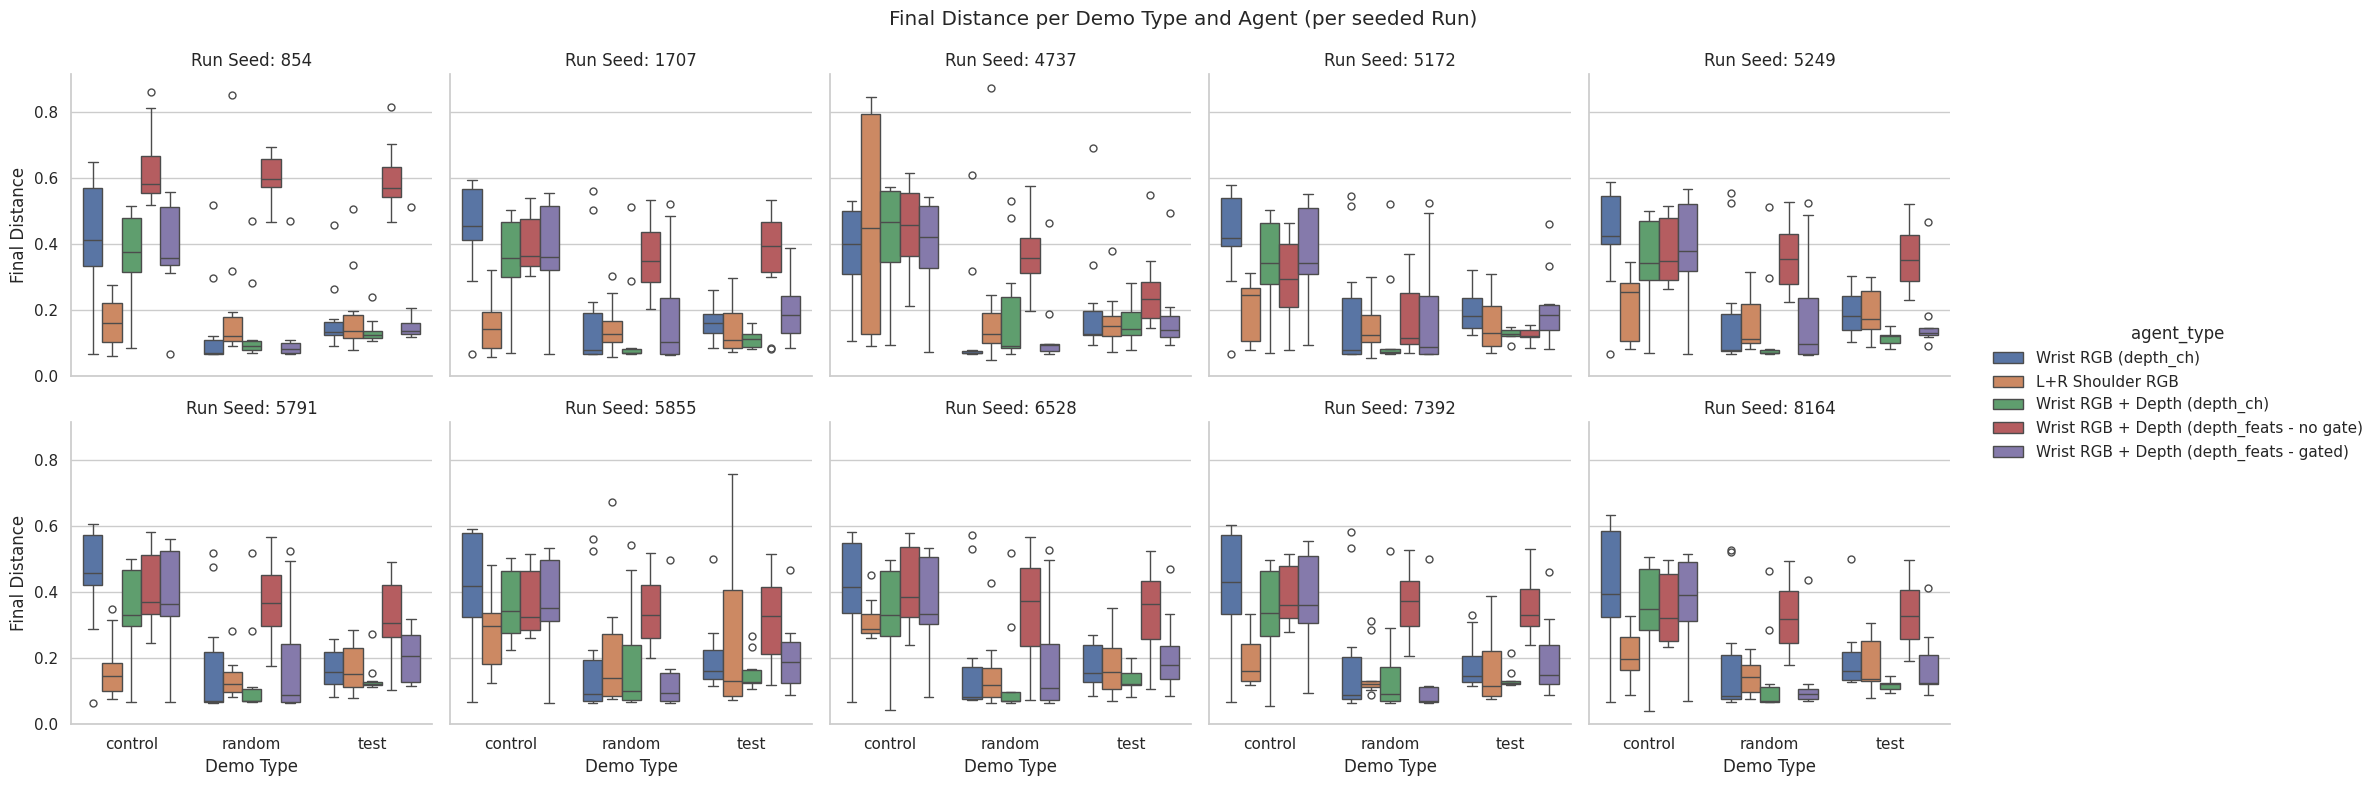

In [32]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='agent_type',
    col='run_seed',
    kind='box',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Final Distance")
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Final Distance per Demo Type and Agent (per seeded Run)")
# plt.savefig("name.svg", format="svg")


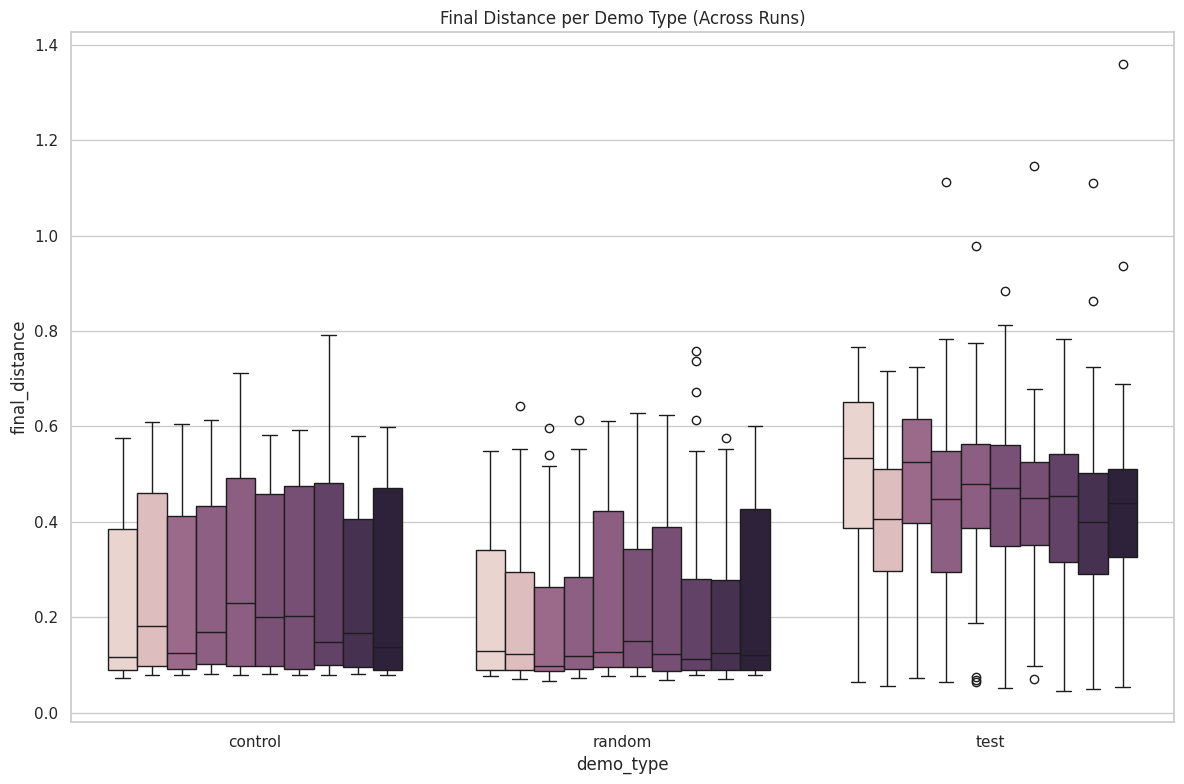

In [26]:
plt.figure(figsize = (12, 8))
sns.boxplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='run_seed',
    legend=False ## just seeds, dont show
)
plt.title('Final Distance per Demo Type (Across Runs)')
plt.tight_layout()
plt.show()

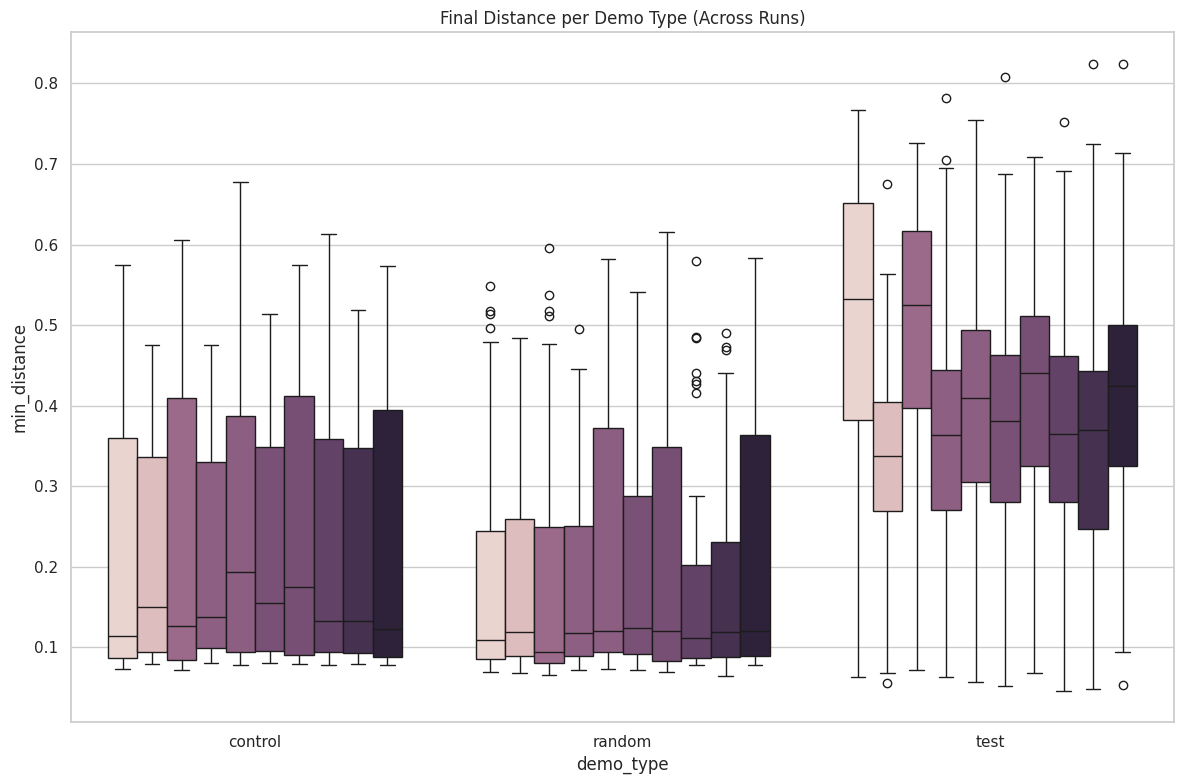

In [ ]:
plt.figure(figsize = (12, 8))
sns.boxplot(
    data=all_dfs,
    x='demo_type',
    y='min_distance',
    hue='run_seed',
    legend=False ## just seeds, dont show
)
plt.title('Min Distance per Demo Type (Across Runs)')
plt.tight_layout()
plt.show()

### Swapped Task Params 
Also running the task_params backwardsto see if there is any changes
train on closer smaller cube then test on the larger further cube

In [17]:
def df_agent_select(agent: str) -> str:
  match agent:
    case "agent-policy:depth_grasp_policy-cams:wrist-policy:depth_grasp_policy-config:depth_ch-opts:{'gated_fuse': None}":
      return "Wrist RGB (depth_ch)"
    case "agent-policy:depth_grasp_policy-cams:wrist+wrist_depth-policy:depth_grasp_policy-config:depth_ch-opts:{'gated_fuse': None}":
      return "Wrist RGB + Depth (depth_ch)"
    case "agent-policy:depth_grasp_policy-cams:wrist+wrist_depth-policy:depth_grasp_policy-config:depth_feats-opts:{'gated_fuse': None}":
      return "Wrist RGB + Depth (depth_feats - no gate)"
    case "agent-policy:depth_grasp_policy-cams:wrist+wrist_depth-policy:depth_grasp_policy-config:depth_feats-opts:{'gated_fuse': True}":
      return "Wrist RGB + Depth (depth_feats - gated)"
    case "agent-policy:depth_grasp_policy-cams:l_shoulder+r_shoulder-policy:depth_grasp_policy-config:depth_ch-opts:{'gated_fuse': None}":
      return "L+R Shoulder RGB"
    case _:
      raise ValueError(f"Add other here: 'Depth Interefacing Helpers")


In [18]:
dfs = []
seeds = [
  854, 1707, 4737, 5172, 5249, 
  5791, 5855, 6528, 7392, 8164

]


for seed in seeds:
  df = pd.read_csv(f"run-csvs/vision-exp/depth-runs/swapped-task-params/depth_policy-5way-comparison-2000ep-10mbsize-{seed}loaderseed-001lr.csv")
  
  
  df["agent_type"] = df["agent_name"].apply(df_agent_select)
  df["run_seed"] = seed
  dfs.append(df)
all_dfs = pd.concat(dfs, ignore_index=True)

all_dfs

,Unnamed: 0,task_name,agent_name,demo_type,task_params,demo_index,is_success,final_distance,min_distance,max_eplen,gripper_image_paths,agent_type,run_seed
0,0,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",0,False,0.067093,0.066911,97,[],Wrist RGB (depth_ch),854
1,1,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",1,False,0.356494,0.282113,97,[],Wrist RGB (depth_ch),854
2,2,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",2,False,0.592079,0.500707,97,[],Wrist RGB (depth_ch),854
3,3,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",3,False,0.438444,0.312078,97,[],Wrist RGB (depth_ch),854
4,4,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist-pol...,control,"{'scale': 0.5, 'wrist_cam_distance': 0.3}",4,False,0.385237,0.385237,97,[],Wrist RGB (depth_ch),854
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,145,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 1, 'wrist_cam_distance': 0.6}",5,False,0.411561,0.398358,101,[],Wrist RGB + Depth (depth_feats - gated),8164
1496,146,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 1, 'wrist_cam_distance': 0.6}",6,False,0.122438,0.121496,101,[],Wrist RGB + Depth (depth_feats - gated),8164
1497,147,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 1, 'wrist_cam_distance': 0.6}",7,True,0.110661,0.103025,101,['outputs/run-grasp-with-agent/_May18_13-08'],Wrist RGB + Depth (depth_feats - gated),8164
1498,148,Vision_Random,agent-policy:depth_grasp_policy-cams:wrist+wri...,test,"{'scale': 1, 'wrist_cam_distance': 0.6}",8,False,0.202413,0.197498,101,[],Wrist RGB + Depth (depth_feats - gated),8164


In [19]:
## all success
# Total demos per run/demo_type/agent
total = all_dfs.groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('total')
success = all_dfs[all_dfs['is_success'] == True]\
    .groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('success')

# Merge and compute percentage
success_df = pd.merge(total, success, left_index=True, right_index=True, how='left')
success_df['success'] = success_df['success'].fillna(0)
success_df['success_pct'] = 100 * success_df['success'] / success_df['total']
success_df = success_df.reset_index()
success_df

,run_seed,agent_type,demo_type,total,success,success_pct
0,854,L+R Shoulder RGB,control,10,1.0,10.0
1,854,L+R Shoulder RGB,random,10,2.0,20.0
2,854,L+R Shoulder RGB,test,10,2.0,20.0
3,854,Wrist RGB (depth_ch),control,10,0.0,0.0
4,854,Wrist RGB (depth_ch),random,10,3.0,30.0
...,...,...,...,...,...,...
145,8164,Wrist RGB + Depth (depth_feats - gated),random,10,4.0,40.0
146,8164,Wrist RGB + Depth (depth_feats - gated),test,10,1.0,10.0
147,8164,Wrist RGB + Depth (depth_feats - no gate),control,10,0.0,0.0
148,8164,Wrist RGB + Depth (depth_feats - no gate),random,10,0.0,0.0


Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per seeded Run)')

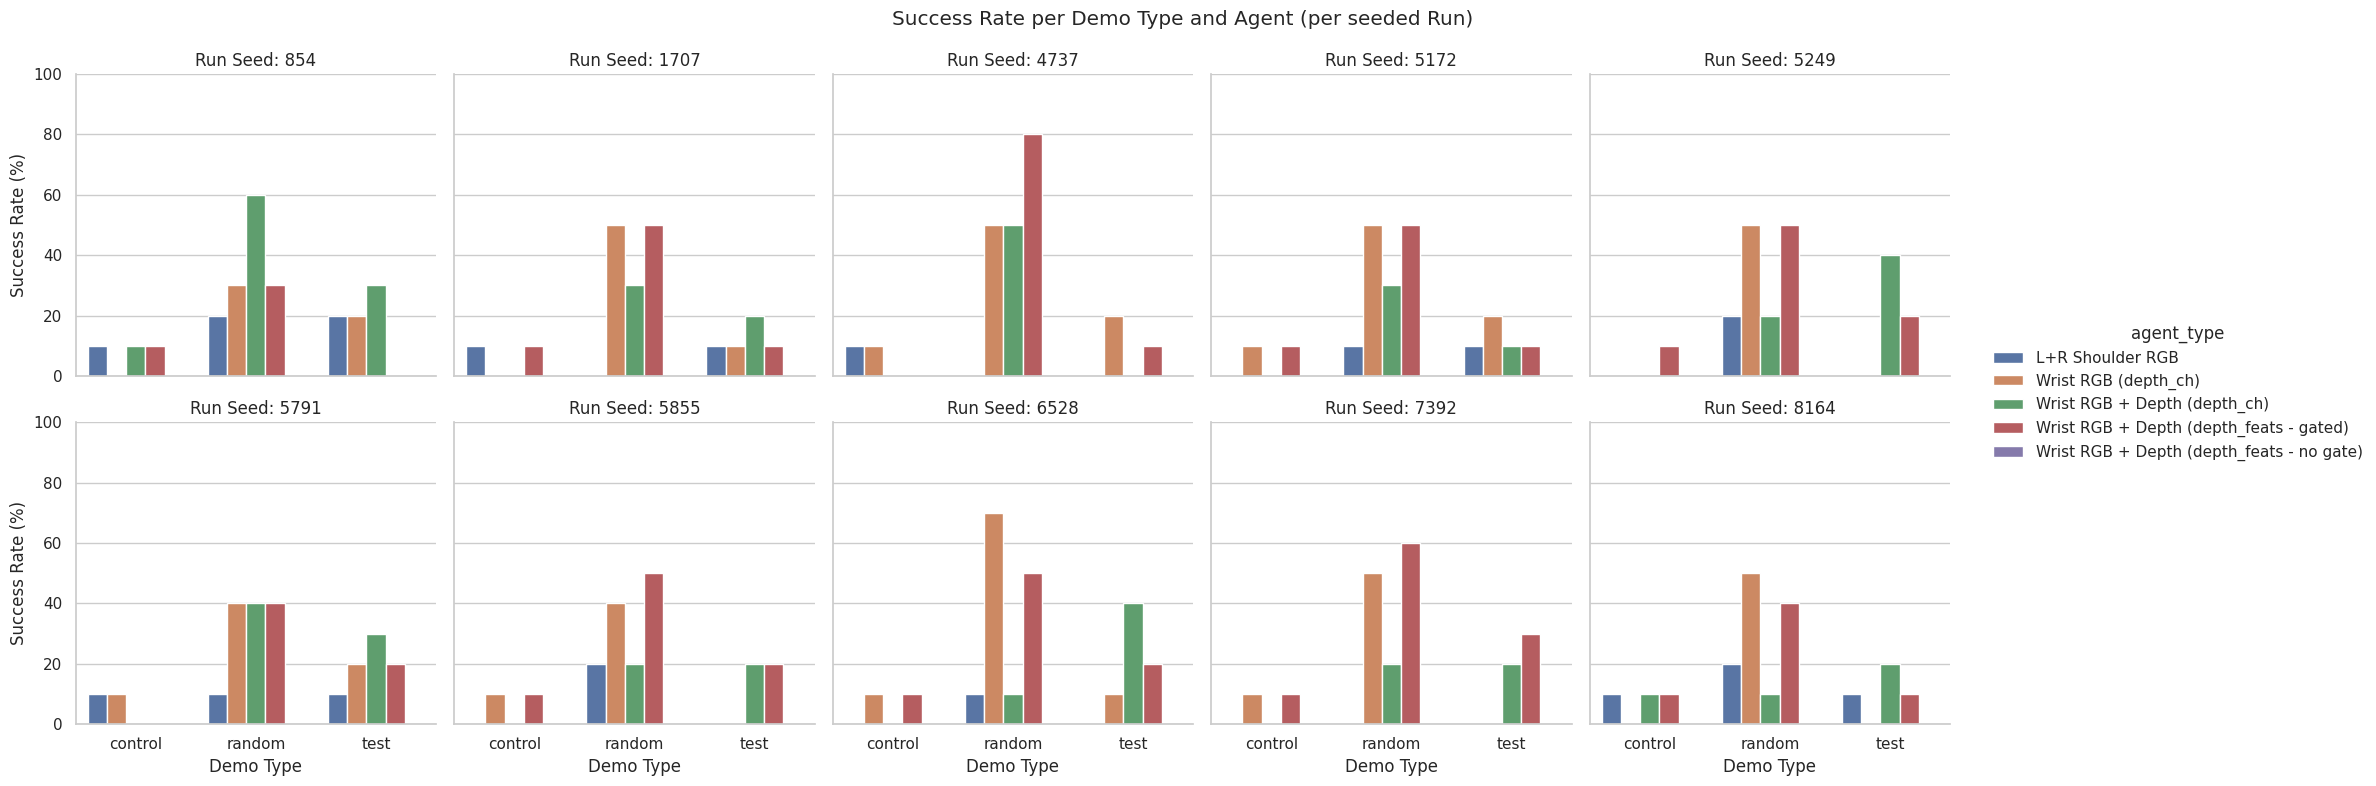

In [20]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=success_df,
    x='demo_type',
    y='success_pct',
    hue='agent_type',
    col='run_seed',
    kind='bar',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Success Rate (%)")
g.set(ylim=(0, 100))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")


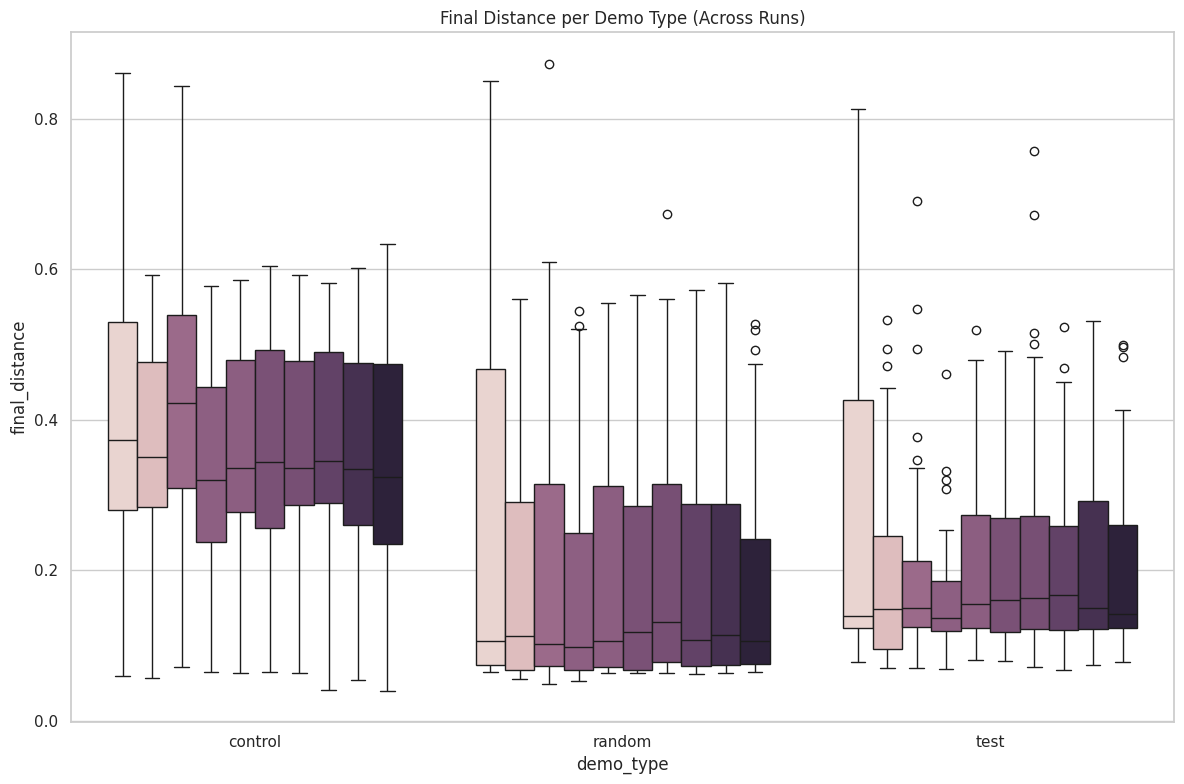

In [22]:
plt.figure(figsize = (12, 8))
sns.boxplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='run_seed',
    legend=False ## just seeds, dont show
)
plt.title('Final Distance per Demo Type (Across Runs)')
plt.tight_layout()
plt.show()

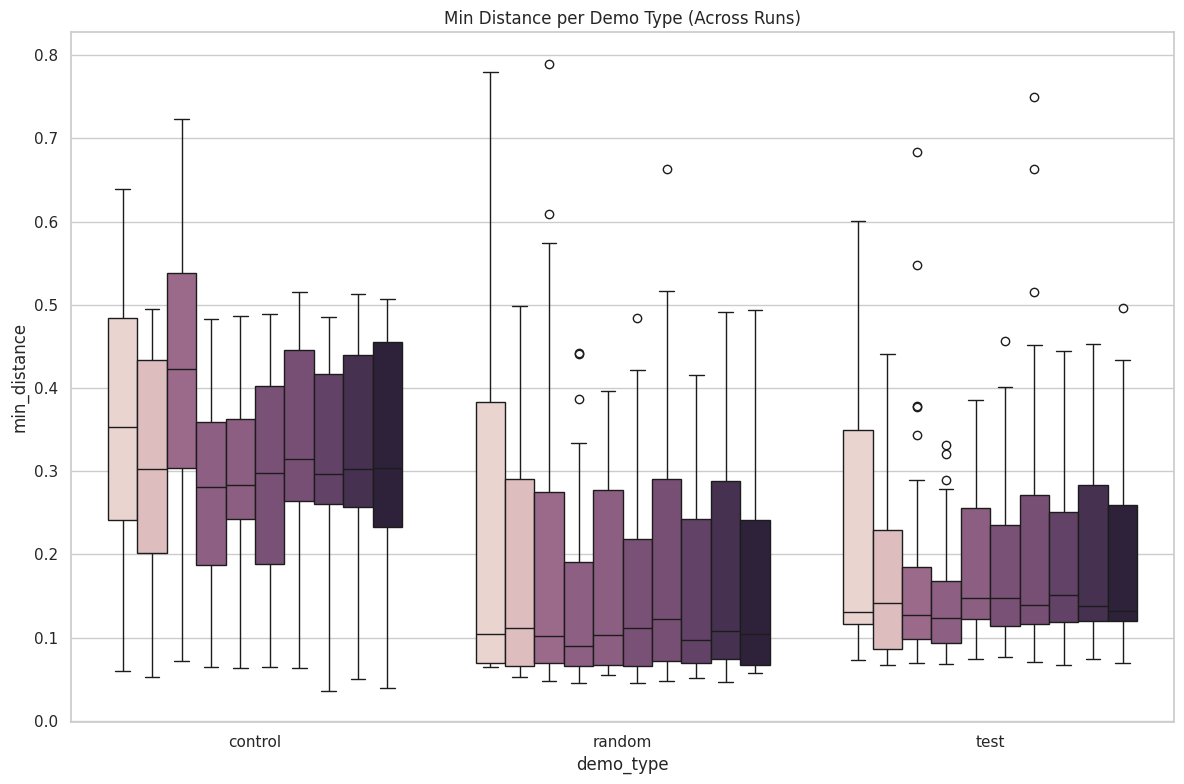

In [24]:
plt.figure(figsize = (12, 8))
sns.boxplot(
    data=all_dfs,
    x='demo_type',
    y='min_distance',
    hue='run_seed',
    legend=False ## just seeds, dont show
)
plt.title('Min Distance per Demo Type (Across Runs)')
plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Final Distance per Demo Type and Agent (per seeded Run)')

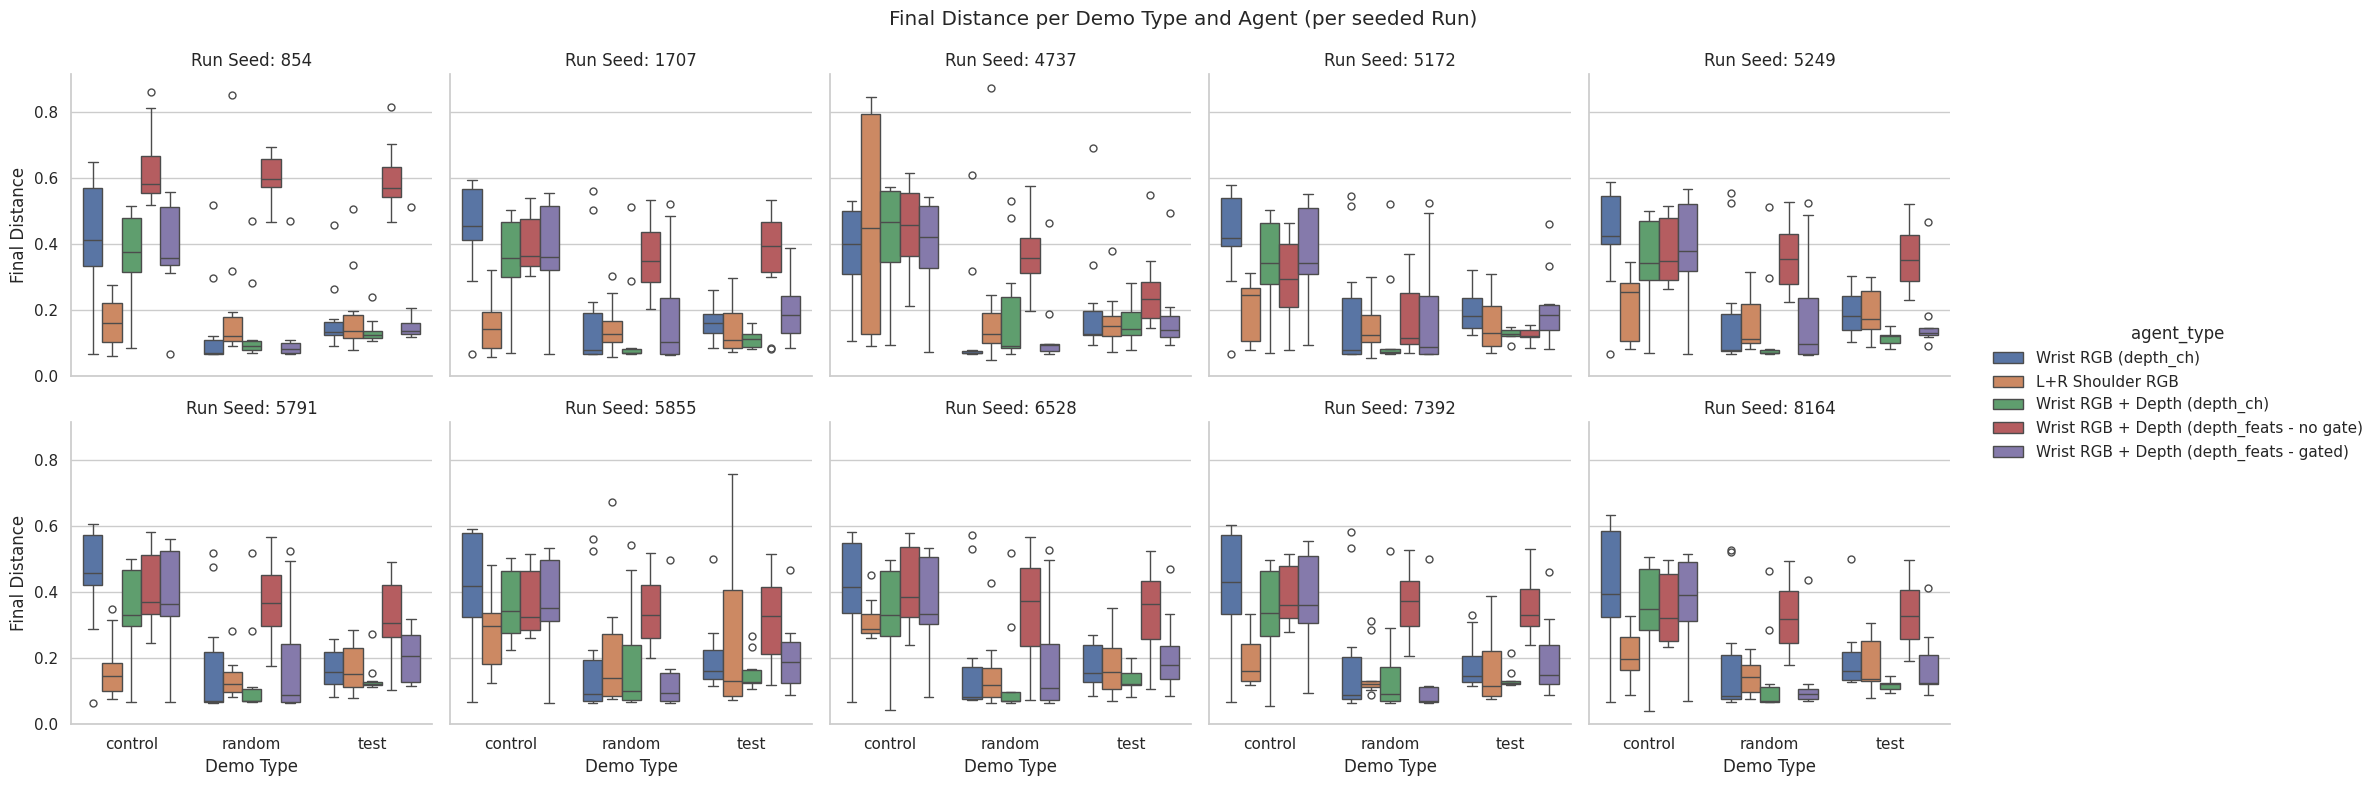

In [36]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='agent_type',
    col='run_seed',
    kind='box',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Final Distance")
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Final Distance per Demo Type and Agent (per seeded Run)")


Slightly better with the task_params swapped, this is probably because learning with the smaller cube trasnlates better to the larger cube just for the grasping, but conversely the task is learnt worse with the smaller cube might be due to the camera not extracting the features ideally. -> maybe check with a conv layer with different kernel sizes?

The test set here performs well even thought the grasping mechanic might not be learnt extremely well, the distribution across tests graph shows us that the robot manages to learn to reach quite convincingly (getting around 0.1m of target means we are at grasping distance) and what falls apart here is the grasp.
as before `depth_ch` and `depth_feats-gated` performs the best

### Both tests with the most promising differnt conv layers
running the gated and camera models (not feats (does not work well)) and try all conv combinations

In [23]:
dfs = []

Learning outcomes here is that, gated feats works better than no gate:
- I don't believe the gating system is deep enough to learn the important, time to incorporate more complicated mechanisms such as LSTMs and Transformers to help fuse this data together
- the non-gated system just does not learn well (this is because it is not very deep and possibly not enough data is given to this system)


Next two approaches (use a LSTM and transformer to get the depth features to be learnt better alongside the RGB features)

## Resnet Featurue encodings
Similar ideas instead of the conv features I am trying resnet encodings specifically 'resnet18', 'resnet34', 'resnet50'.

!!! resnet uses 400 epochs instead of 2000, because it overfits too much if it sees all 10 demos for that many iterations, this is a deeped network (I think)

there is not target size change here just testing the policies (test and train are the same sizes of task)

```js
cam_type =  CamType.LEFT_SHOUULDER | CamType.RIGHT_SHOULDER
```

In [11]:
def df_agent_select(agent: str) -> str:
  match agent:
    case "agent-policy:resnet_grasp_policy-cams:wrist+wrist_depth-policy:resnet_grasp_policy-config:depth_feats-opts:{'gated_fuse': True, 'resnet_name': 'resnet18', 'kernel_size': 3}":
      return "ResNet18"
    case "agent-policy:resnet_grasp_policy-cams:wrist+wrist_depth-policy:resnet_grasp_policy-config:depth_feats-opts:{'gated_fuse': True, 'resnet_name': 'resnet34', 'kernel_size': 3}":
      return "ResNet34"
    case "agent-policy:resnet_grasp_policy-cams:wrist+wrist_depth-policy:resnet_grasp_policy-config:depth_feats-opts:{'gated_fuse': True, 'resnet_name': 'resnet50', 'kernel_size': 3}":
      return "ResNet50"
    case "agent-policy:depth_grasp_policy-cams:wrist+wrist_depth-policy:depth_grasp_policy-config:depth_feats-opts:{'gated_fuse': True}":
      return "Depth (depth_feats - gated)"
    case _:
      raise ValueError(f"Add other here: 'Depth Interefacing Helpers")


In [22]:
dfs = []
## first try
# seeds = [
#   4142, 6966, 7027
# ]
## second try ## NOTE: suspecting foul play with jupyter doing one more
# seeds = [854, 4737, 8164]
## 3rd time:
seeds = [897, 3907, 9149]

for seed in seeds:
  # df = pd.read_csv(f"run-csvs/vision-exp/depth-runs/4way-depth-resnetVSdepth/2way-resnetcomp-cam:wrist+wrist_depth-2000ep-10mbsize-{seed}loaderseed-001lr.csv")
  # df = pd.read_csv(f"run-csvs/vision-exp/depth-runs/4way-depth-resnetVSdepth2/4way-resnetcomp-cam:wrist+wrist_depth-400or2000ep-10mbsize-{seed}loaderseed-001lr.csv")
  df = pd.read_csv(f"run-csvs/vision-exp/depth-runs/4way-depth-resnetVSdepth3pyfile/4way-resnetcomp-cam:wrist+wrist_depth-400or2000ep-10mbsize-{seed}loaderseed-001lr.csv")
  df["agent_type"] = df["agent_name"].apply(df_agent_select)
  df["run_seed"] = seed
  dfs.append(df)
all_dfs = pd.concat(dfs, ignore_index=True)

# all_dfs[
#   all_dfs["agent_type"].isin(["ResNet18", "ResNet34", "ResNet50"]) & all_dfs["is_success"] == True
#   ]

In [23]:
## all success
# Total demos per run/demo_type/agent
total = all_dfs.groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('total')
success = all_dfs[all_dfs['is_success'] == True]\
    .groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('success')

# Merge and compute percentage
success_df = pd.merge(total, success, left_index=True, right_index=True, how='left')
success_df['success'] = success_df['success'].fillna(0)
success_df['success_pct'] = 100 * success_df['success'] / success_df['total']
success_df = success_df.reset_index()


Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per seeded Run)')

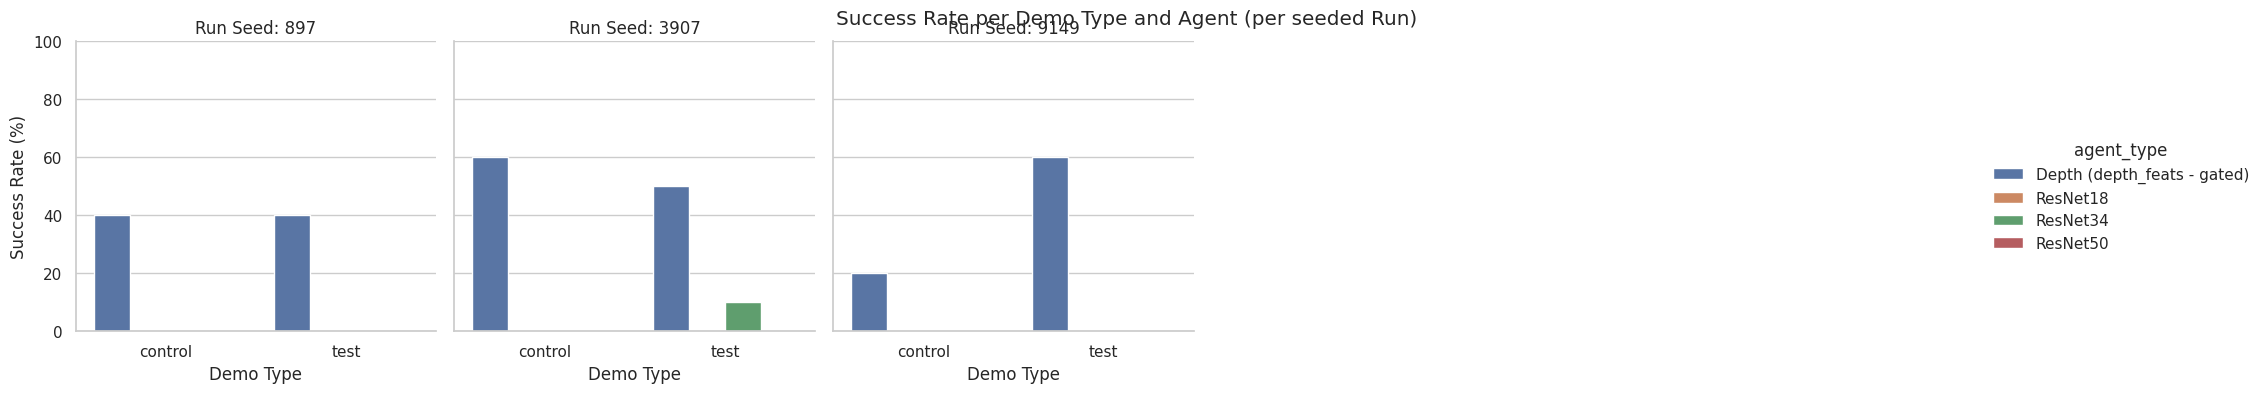

In [24]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=success_df,
    x='demo_type',
    y='success_pct',
    hue='agent_type',
    col='run_seed',
    kind='bar',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Success Rate (%)")
g.set(ylim=(0, 100))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")


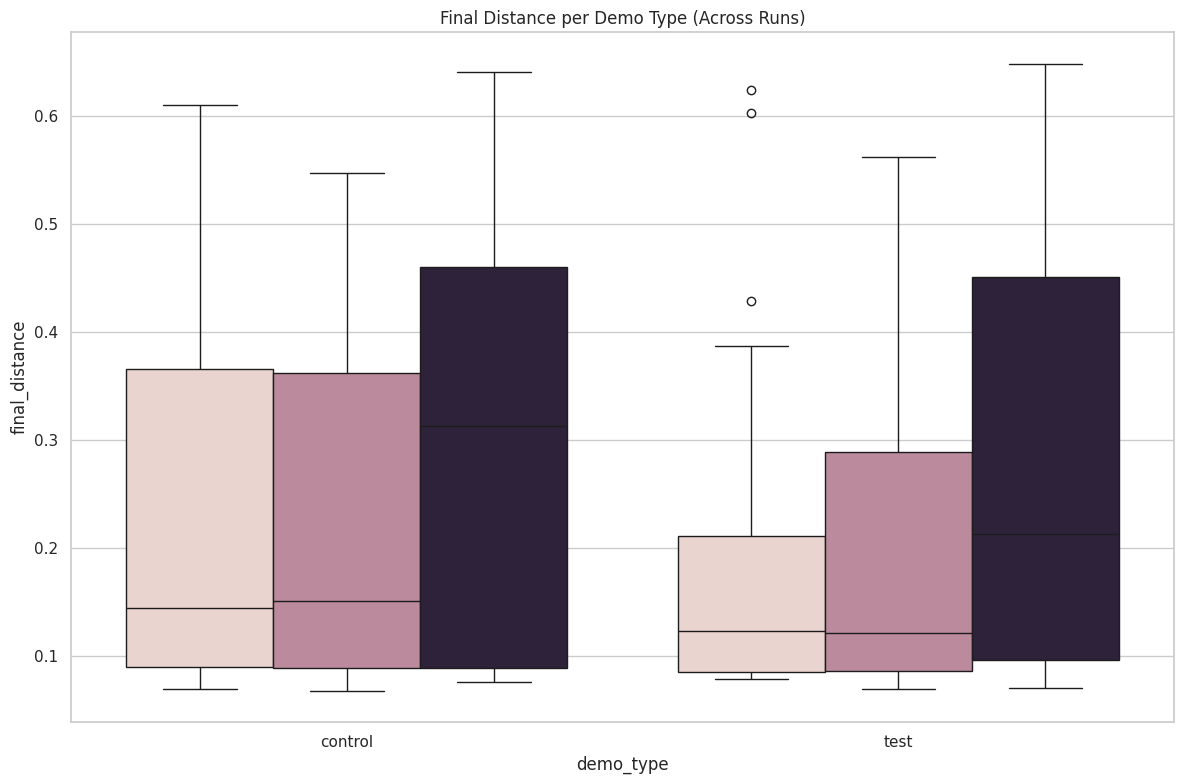

In [25]:
plt.figure(figsize = (12, 8))
sns.boxplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='run_seed',
    legend=False ## just seeds, dont show
)
plt.title('Final Distance per Demo Type (Across Runs)')
plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Final Distance per Demo Type and Agent (per seeded Run)')

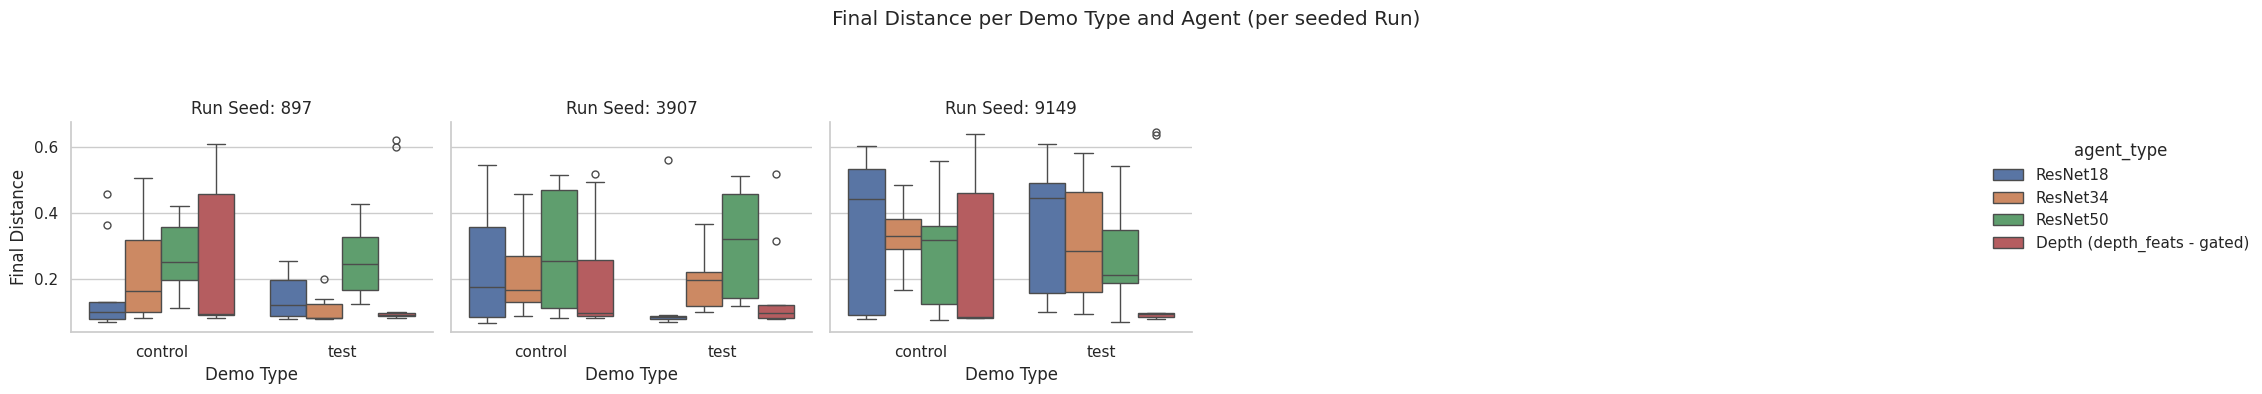

In [28]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='agent_type',
    col='run_seed',
    kind='box',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Final Distance")
g.tight_layout()
plt.subplots_adjust(top=0.7)
g.fig.suptitle("Final Distance per Demo Type and Agent (per seeded Run)")


Data is all over the place with ResNet, will move onto LSTMS and my own conv to see if any inforamtion about the task can be learnt rather than better fetaure extraction

I feel liek resnet acts better when I am tetsing it manually on `reach_with_demos` not sure what the problem is here, but it does not wanna grasp anything. Mihgt look at it later



### L+S Shoulder ResNet vs Conv

trying resnet with other cameras

```js
cam_type =  CamType.LEFT_SHOULDERO | CamType.RIGHT_SHOULDER
```

In [31]:
def df_agent_select(agent: str) -> str:
  match agent:
    
    case "agent-policy:resnet_grasp_policy-cams:l_shoulder+r_shoulder-policy:resnet_grasp_policy-config:depth_ch-opts:{'gated_fuse': True, 'resnet_name': 'resnet18', 'kernel_size': 3}":
      return "ResNet18"
    case "agent-policy:resnet_grasp_policy-cams:l_shoulder+r_shoulder-policy:resnet_grasp_policy-config:depth_ch-opts:{'gated_fuse': True, 'resnet_name': 'resnet34', 'kernel_size': 3}":
      return "ResNet34"
    case "agent-policy:resnet_grasp_policy-cams:l_shoulder+r_shoulder-policy:resnet_grasp_policy-config:depth_ch-opts:{'gated_fuse': True, 'resnet_name': 'resnet50', 'kernel_size': 3}":
      return "ResNet50"
    case "agent-policy:depth_grasp_policy-cams:l_shoulder+r_shoulder-policy:depth_grasp_policy-config:depth_ch-opts:{'gated_fuse': True}":
      return "Depth (depth_feats - gated)"
    case _:
      raise ValueError(f"Add other here: 'Depth Interefacing Helpers")


In [35]:
dfs = []
seeds = [
  6799, 7079, 7987
]
for seed in seeds:
  df = pd.read_csv(f"run-csvs/vision-exp/depth-runs/4way-lrShoulder-resnetVSdepth/4way-resnetcomp-cam:l_shoulder+r_shoulder-400or2000ep-10mbsize-{seed}loaderseed-001lr.csv")
  df["agent_type"] = df["agent_name"].apply(df_agent_select)
  df["run_seed"] = seed
  dfs.append(df)
all_dfs = pd.concat(dfs, ignore_index=True)

# all_dfs[
#   all_dfs["agent_type"].isin(["ResNet18", "ResNet34", "ResNet50"]) & all_dfs["is_success"] == True
#   ]

In [36]:
## all success
# Total demos per run/demo_type/agent
total = all_seeds.groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('total')
success = all_seeds[all_seeds['is_success'] == True]\
    .groupby(['run_seed', 'agent_type', 'demo_type']).size().rename('success')

# Merge and compute percentage
success_df = pd.merge(total, success, left_index=True, right_index=True, how='left')
success_df['success'] = success_df['success'].fillna(0)
success_df['success_pct'] = 100 * success_df['success'] / success_df['total']
success_df = success_df.reset_index()


Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per seeded Run)')

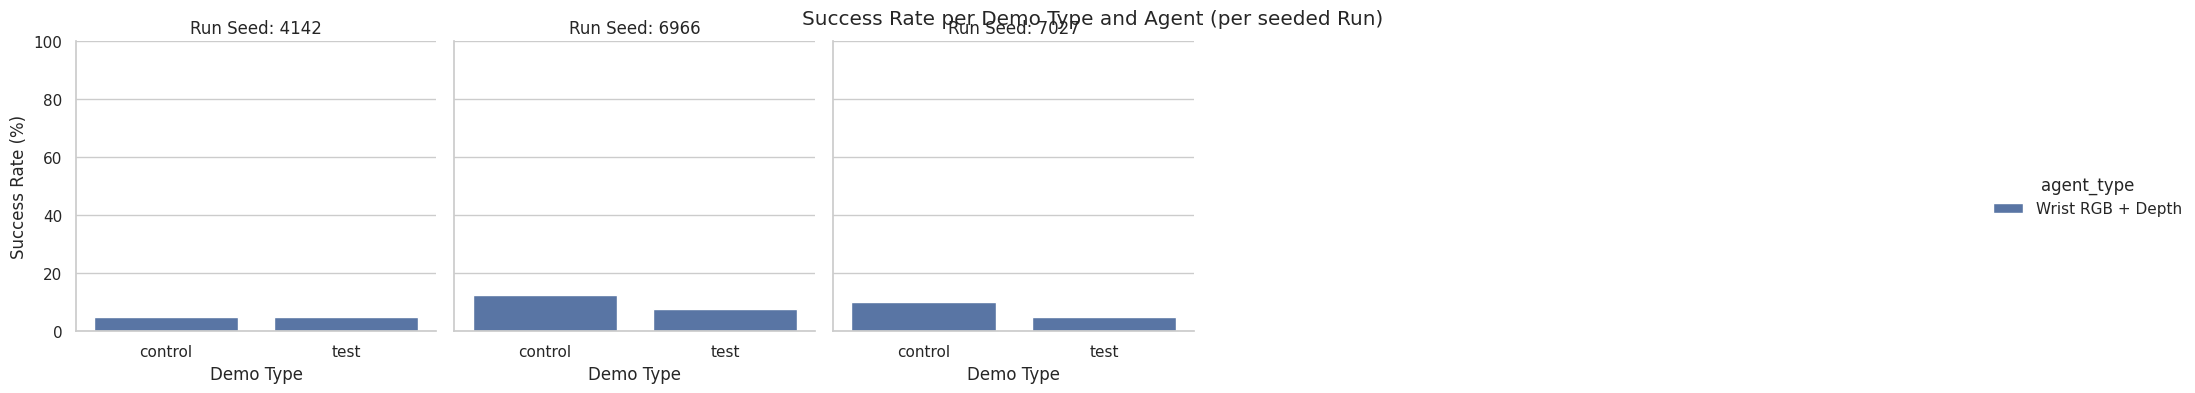

In [37]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=success_df,
    x='demo_type',
    y='success_pct',
    hue='agent_type',
    col='run_seed',
    kind='bar',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Success Rate (%)")
g.set(ylim=(0, 100))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")


Text(0.5, 0.98, 'Final Distance per Demo Type and Agent (per seeded Run)')

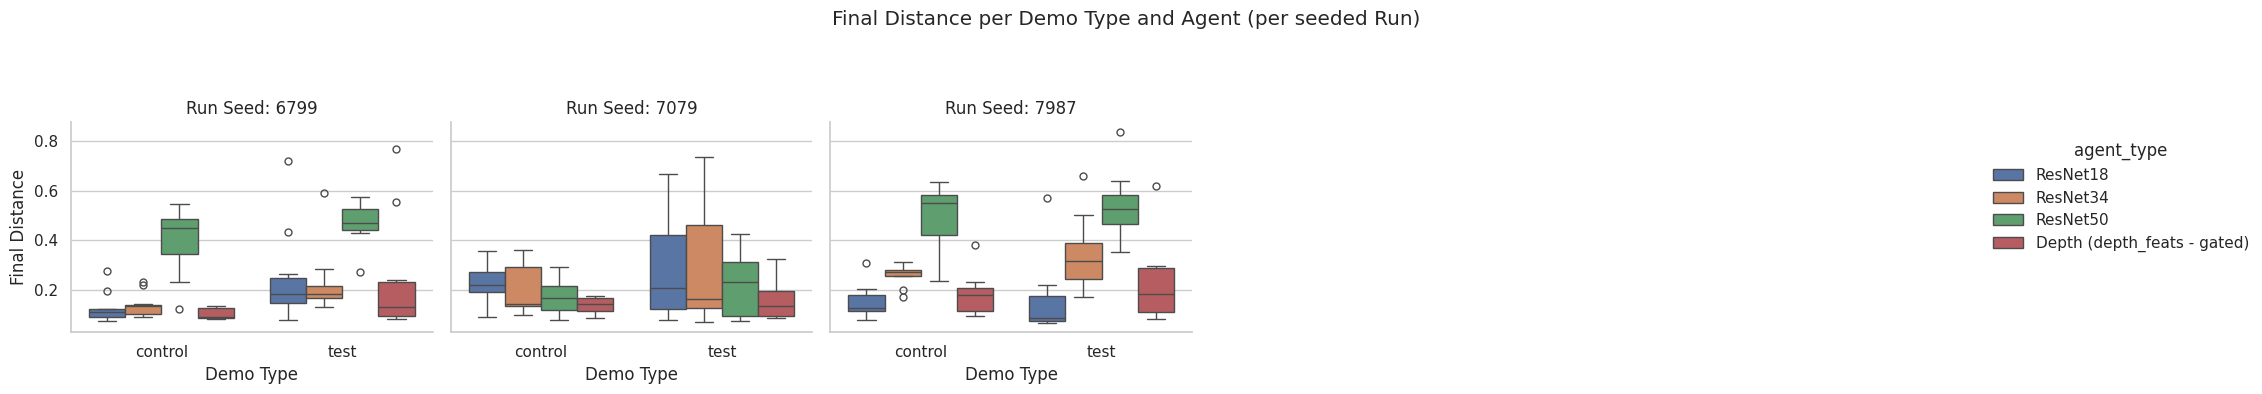

In [39]:
sns.set(style="whitegrid")

# Plot
g = sns.catplot(
    data=all_dfs,
    x='demo_type',
    y='final_distance',
    hue='agent_type',
    col='run_seed',
    kind='box',
    col_wrap=5,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Run Seed: {col_name}")
g.set_axis_labels("Demo Type", "Final Distance")
g.tight_layout()
plt.subplots_adjust(top=0.7)
g.fig.suptitle("Final Distance per Demo Type and Agent (per seeded Run)")


## Conv + LSTM features

## Transformer Feature Blending